# Single Sorting Strategy Analysis

## Overview
This Jupyter Notebook conducts a comprehensive analysis of single sorting strategies in quantitative finance, evaluating fundamental signals for long-short equity portfolios. It computes risk-adjusted returns (alphas) using advanced factor models, accounting for transaction costs and robustness checks.

## Key Features
- **Centralized Configuration**: All parameters managed via a single `CONFIG` dictionary.
- **Auto-Detection of Signals**: Scans portfolio directory for available signals and metadata.
- **Flexible Signal Selection**: Manual selection with strategy inversion options.
- **Transaction Cost Integration**: Time-varying costs applied during rebalancing (June).
- **Multi-Model Factor Analysis**: Compares alphas across FF6, FF7 (FF6 + QMJ), Q5, and M4 models.
- **Robustness Testing**: Sub-period analysis, model correlations, and diagnostic checks.
- **Outputs**: Statistical summaries, LaTeX tables, and CSV exports.

## Methodology
1. Load pre-computed portfolio returns and factor data.
2. Map signals to economic directions and compute long-short returns.
3. Estimate transaction costs and apply conditionally.
4. Perform OLS regressions with Newey-West standard errors (12 lags).
5. Evaluate significance, Sharpe ratios, and turnover metrics.
6. Compare performance across models and periods.

## Dependencies
- Libraries: pandas, numpy, matplotlib, seaborn, statsmodels, pathlib.
- Data: Portfolio Parquet files, FF factors (CSV), Q5 (CSV), AQR QMJ (Excel), M4 (CSV).
- Environment: macOS with VS Code and integrated terminal.

## Usage
1. Update `CONFIG` for signal selection and parameters.
2. Run cells to load data, compute costs, and perform regressions.
3. Review tables and figures for insights.
4. Export results for publication.

This notebook provides an end-to-end framework for evaluating quantitative signals in equity markets, bridging research and implementation.

In [1]:
# 📦 IMPORTS

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib import rcParams


import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports OK")

✅ Imports OK


### General config

In [12]:
CONFIG = {
    # ═══════════════════════════════════════════════════════════════════════════
    # PATHS
    # ═══════════════════════════════════════════════════════════════════════════
    'data_version': '',                           
    'portfolio_dir': 'data/portfolios',
    
    # ─── Factor Models ───
    'ff_factors_file': 'data/factors/ff/FF5.csv',           # Fama-French 6 factors
    'q5_factors_file': 'data/factors/q5/q5m.csv',           # Q5 (Hou-Xue-Zhang)
    'aqr_qmj_file': 'data/factors/aqr-qmj/qmj_m.xlsx',      # AQR Quality Minus Junk
    'm4_factors_file': 'data/factors/m4/M4.csv',            # Mispricing Factors
    
    # ═══════════════════════════════════════════════════════════════════════════
    # SIGNAL SELECTION
    # ═══════════════════════════════════════════════════════════════════════════
    'signal_name': 'gross_profitability',              # ← CHOISIR ICI (pas None)
    
    # ═══════════════════════════════════════════════════════════════════════════
    # STRATEGY
    # ═══════════════════════════════════════════════════════════════════════════
    'invert_strategy': False,                    
    
    # ═══════════════════════════════════════════════════════════════════════════
    # ANALYSIS
    # ═══════════════════════════════════════════════════════════════════════════
    'use_momentum': True,                        
}

print(f"✅ Configuration chargée")
print(f"   • Signal sélectionné : {CONFIG['signal_name']}")
print(f"   • FF6 Factors        : {CONFIG['ff_factors_file']}")
print(f"   • Q5 Factors         : {CONFIG['q5_factors_file']}")
print(f"   • AQR QMJ           : {CONFIG['aqr_qmj_file']}")
print(f"   • M4 Mispricing     : {CONFIG['m4_factors_file']}")

✅ Configuration chargée
   • Signal sélectionné : gross_profitability
   • FF6 Factors        : data/factors/ff/FF5.csv
   • Q5 Factors         : data/factors/q5/q5m.csv
   • AQR QMJ           : data/factors/aqr-qmj/qmj_m.xlsx
   • M4 Mispricing     : data/factors/m4/M4.csv


### Transaction cost function

In [17]:
def get_transaction_cost_bps(year):
    """
    Estimation conservatrice des coûts (One-Way) en bps.
    Alignée sur Frazzini et al. (2012) et le texte du papier.
    """
    if year < 1990:
        return 200.0  # 1963-1989: High friction
    elif year <= 2000:
        return 100.0  # 1990-2000: Transition
    elif year <= 2010:
        return 35.0   # 2001-2010: Decimalization
    else:
        return 15.0   # Post-2010: Electronic / Algo

In [8]:
SIGNAL_DIRECTION_MAP = {
    # ═══════════════════════════════════════════════════════════════
    # A. PROFITABILITY (5 signaux)
    # ═══════════════════════════════════════════════════════════════
    # Gross Profitability: (SALE - COGS) / AT. HIGH = Rentable.
    'gross_profitability': 'P10-P1',
    
    # Operating Profitability: (REVT - COGS - XSGA) / AT. HIGH = Profitable.
    'operating_profitability': 'P10-P1',
    
    # Return on Assets: NI / AT. HIGH = Rentable.
    'return_on_assets': 'P10-P1',
    
    # Change in Asset Turnover: Δ(SALE / AT). HIGH = Amélioration efficacité.
    'change_asset_turnover': 'P10-P1',
    
    # Change in Profit Margin: Δ(NI / SALE). HIGH = Amélioration marge.
    'change_profit_margin': 'P10-P1',
    
    # ═══════════════════════════════════════════════════════════════
    # B. INVESTMENT (7 signaux)
    # ═══════════════════════════════════════════════════════════════
    # NOA Change: Δ NOA / AT_avg. HIGH = Sur-investissement (BAD).
    'noa_change': 'P1-P10',
    
    # Asset Growth: Δ AT / AT_lag. HIGH = Sur-investissement (BAD).
    'asset_growth': 'P1-P10',
    
    # Investment CapEx: Δ AT / AT_lag. HIGH = Sur-investissement (BAD).
    'investment_capex': 'P1-P10',
    
    # CapEx + Inventory Growth: (Δ PPEGT + Δ INVT) / AT. HIGH = Sur-investissement (BAD).
    'capex_inventory_growth': 'P1-P10',
    
    # Inventory Change: Δ INVT / AT_avg. HIGH = Accumulation stocks (BAD).
    'inventory_change': 'P1-P10',
    
    # Net Share Issues: Δ CSHO / CSHO_lag. HIGH = Dilution (BAD).
    'net_share_issues': 'P1-P10',
    
    # CapEx Growth: Δ CAPX / AT. HIGH = Sur-investissement (BAD).
    'capex_growth': 'P1-P10',
    
    # Sales Growth: Δ SALE / SALE_lag. HIGH = Over-expansion risk (REVERSAL).
    'sales_growth': 'P1-P10',
    
    # ═══════════════════════════════════════════════════════════════
    # C. ACCRUALS & QUALITY (4 signaux)
    # ═══════════════════════════════════════════════════════════════
    # Working Capital Accruals: Δ(ACT - CHE - LCT + DLC) / AT_avg. HIGH = Low quality earnings (BAD).
    'working_capital_accruals': 'P1-P10',
    
    # Sales - Receivables Gap: Δ SALE - Δ RECT. HIGH = Real demand (GOOD).
    'sales_receivables_gap': 'P10-P1',
    
    # Receivables Turnover: SALE / RECT. HIGH = Efficient collection (GOOD).
    'receivables_turnover': 'P10-P1',
    
    # Operating Leverage: (Δ SALE - Δ INVT) / AT. HIGH = Real sales growth (GOOD).
    'operating_leverage': 'P10-P1',
    
    # ═══════════════════════════════════════════════════════════════
    # D. LIQUIDITY & SOLVENCY (4 signaux)
    # ═══════════════════════════════════════════════════════════════
    # Cash Cushion: CHE / AT. HIGH = Liquidity buffer (GOOD).
    'cash_cushion': 'P10-P1',
    
    # Book Leverage: (DLTT + DLC) / SEQ. HIGH = Risky (BAD).
    'book_leverage': 'P1-P10',
    
    # Change in Current Ratio: Δ(ACT / LCT). HIGH = Improving liquidity (GOOD).
    'change_current_ratio': 'P10-P1',
    
    # Change in Quick Ratio: Δ((ACT - INVT) / LCT). HIGH = Improving liquidity (GOOD).
    'change_quick_ratio': 'P10-P1',
    
    # ═══════════════════════════════════════════════════════════════
    # E. OPERATING EFFICIENCY (4 signaux)
    # ═══════════════════════════════════════════════════════════════
    # Cash Productivity: (SALE + Δ RECT) / CHE. HIGH = Efficient cash use (GOOD).
    'cash_productivity': 'P10-P1',
    
    # Depreciation to PPE: DP / PPENT. HIGH = Asset aging (BAD).
    'depreciation_to_ppe': 'P1-P10',
    
    # Change in Depreciation: Δ DP / AT. HIGH = Increasing depreciation (BAD).
    'change_depreciation': 'P1-P10',
    
    # Tax Income Ratio: TXT / PI. HIGH = Tax efficiency (GOOD).
    'tax_income_ratio': 'P10-P1',
}

# ✅ VÉRIFICATION : 25 SIGNAUX
print(f"✅ Nombre de signaux : {len(SIGNAL_DIRECTION_MAP)}")
print(f"\n📊 Répartition par catégorie :")
print(f"   • Profitability        : 5")
print(f"   • Investment           : 8")
print(f"   • Accruals & Quality   : 4")
print(f"   • Liquidity & Solvency : 4")
print(f"   • Operating Efficiency : 4")
print(f"\n{'='*60}")
print(f"✅ Total               : {len(SIGNAL_DIRECTION_MAP)} signaux")


# SIGNAL_DIRECTION_MAP = {
#     # ─────────────────────────────────────────────────────────
#     # 1. LEVERAGE & SOLVENCY (2 signaux)
#     # ─────────────────────────────────────────────────────────
#     # Math: LT Debt / Total Debt. High = Moins de risque de refinancement.
#     'debt_maturity': 'P10-P1',

#     # Math: Sales / Total Debt. High = Capacité à rembourser via les ventes.
#     'leverage_efficiency': 'P10-P1',

#     # ─────────────────────────────────────────────────────────
#     # 2. PROFITABILITY (3 signaux)
#     # ─────────────────────────────────────────────────────────
#     # Math: Persistence (Mean/Std). High = Stable.
#     'op_margin_persist': 'P10-P1',

#     # Math: Net Income / Pretax Income. High = Efficacité fiscale / Retention.
#     'earnings_quality': 'P10-P1',

#     # Math: EBITDA / Sales. High = Rentable.
#     'ebitda_margin': 'P10-P1',

#     # ─────────────────────────────────────────────────────────
#     # 3. ASSET EFFICIENCY (5 signaux)
#     # ─────────────────────────────────────────────────────────
#     # Math: Intangibles / Assets. High = Potentiel.
#     'intangible_power': 'P10-P1',

#     # Math: Gross Profit / Inventory. High = Rotation rapide (Efficacité).
#     'inv_margin': 'P10-P1',

#     # Math: Sales / Receivables. High = On est payé vite.
#     'receivables_turnover': 'P10-P1',

#     # Math: Sales / PPE. High = Efficacité des usines.
#     'ppe_productivity': 'P10-P1',

#     # Math: Turnover * Profitability. High = Good.
#     'asset_turnover_quality': 'P10-P1',

#     # ─────────────────────────────────────────────────────────
#     # 4. LIQUIDITY (1 signal)
#     # ─────────────────────────────────────────────────────────
#     # Math: Cash / Current Liab. High = Sécurité.
#     'cash_cushion': 'P10-P1',

#     # ─────────────────────────────────────────────────────────
#     # 5. CAPITAL INTENSITY (2 signaux)
#     # ─────────────────────────────────────────────────────────
#     # Math: Low Capex * High Margin. High = Good business model.
#     'low_capex_high_margin': 'P10-P1',

#     # Math: Sales / Depreciation. High = Efficacité.
#     'depreciation_efficiency': 'P10-P1',

#     # ─────────────────────────────────────────────────────────
#     # 6. QUALITY (3 signaux)
#     # ─────────────────────────────────────────────────────────
#     # Math: Persistence GP. High = Good.
#     'gp_persist': 'P10-P1',

#     # Math: (PPE + Inv) / Assets. 
#     # High = Tangible (Old Economy). Low = Intangible (New Economy).
#     # On short les "Asset Heavy", donc Low is GOOD.
#     'asset_tangibility': 'P1-P10',

#     # Math: Mean/Std ROA. High = Stable.
#     'earnings_smoothness': 'P10-P1',

#     # ─────────────────────────────────────────────────────────
#     # 7. ACCRUALS (1 signal)
#     # ─────────────────────────────────────────────────────────
#     # Math: Change in NOA. High = Bloated Balance Sheet (Sloan/Hirshleifer).
#     # High is BAD, donc Low is GOOD.
#     'noa_change': 'P1-P10',

#     # ─────────────────────────────────────────────────────────
#     # 8. GROWTH & DYNAMICS (4 signaux)
#     # ─────────────────────────────────────────────────────────
#     # Math: Acceleration Earnings. High = Momentum.
#     'earnings_accel': 'P10-P1',

#     # Math: Acceleration Sales. High = Momentum.
#     'sales_accel': 'P10-P1',

#     # Math: Sales Growth - Receivables Growth.
#     # Si positif (High), les ventes rentrent en cash. C'est SAIN.
#     'recv_vs_sales': 'P10-P1',

#     # Math: Current Growth / Avg Growth. 
#     # High = Spike énorme (Risk of exhaustion). Low = Stable/Decreasing.
#     # Ici on parie sur le Mean Reversion, donc High is Risky.
#     'growth_exhaustion': 'P1-P10',

#     # ─────────────────────────────────────────────────────────
#     # 9. OPERATING LEVERAGE (1 signal)
#     # ─────────────────────────────────────────────────────────
#     # Math: Gross Profit Growth - SG&A Growth.
#     # High = Margin expansion (operating leverage). High is GOOD.
#     'sga_gp_leverage': 'P10-P1',

#     # ─────────────────────────────────────────────────────────
#     # 10. RETURNS QUALITY (3 signaux)
#     # ─────────────────────────────────────────────────────────
#     # Math: ROIC × (1 - Payout Ratio).
#     # High = Reinvesting profits at high rates creates value.
#     'investment_quality': 'P10-P1',

#     # Math: ROIC_t - ROIC_{t-1}.
#     # High = Improvement in capital efficiency predicts returns.
#     'roic_momentum': 'P10-P1',

#     # Math: -σ_{5y}(OP Margin).
#     # High = Low volatility (stable margins outperform).
#     'margin_stability_new': 'P10-P1',
# }

# # ✅ VÉRIFICATION : 25 SIGNAUX
# print(f"✅ Nombre de signaux : {len(SIGNAL_DIRECTION_MAP)}")
# print(f"\n📊 Répartition par catégorie :")
# print(f"   • Leverage & Solvency  : 2")
# print(f"   • Profitability        : 3")
# print(f"   • Asset Efficiency     : 5")
# print(f"   • Liquidity            : 1")
# print(f"   • Capital Intensity    : 2")
# print(f"   • Quality              : 3")
# print(f"   • Accruals             : 1")
# print(f"   • Growth & Dynamics    : 4")
# print(f"   • Operating Leverage   : 1")
# print(f"   • Returns Quality      : 3")
# print(f"\n{'='*60}")
# print(f"✅ Total               : {len(SIGNAL_DIRECTION_MAP)} signaux")

✅ Nombre de signaux : 25

📊 Répartition par catégorie :
   • Profitability        : 5
   • Investment           : 8
   • Accruals & Quality   : 4
   • Liquidity & Solvency : 4
   • Operating Efficiency : 4

✅ Total               : 25 signaux


In [9]:

# Mapping manuel : snake_case → Nom académique propre
# SIGNAL_NAME_MAP = {
#     # Leverage & Solvency
#     'debt_maturity': 'Debt Maturity',
#     'leverage_efficiency': 'Leverage Efficiency',
    
#     # Profitability
#     'op_margin_persist': 'OP Margin Persist',
#     'earnings_quality': 'Earnings Quality',
#     'ebitda_margin': 'EBITDA Margin',
    
#     # Asset Efficiency
#     'intangible_power': 'Intangible Power',
#     'inv_margin': 'Inventory Margin',
#     'receivables_turnover': 'Receivables Turnover',
#     'ppe_productivity': 'PPE Productivity',
#     'asset_turnover_quality': 'Asset Turnover Quality',
    
#     # Liquidity
#     'cash_cushion': 'Cash Cushion',
    
#     # Capital Intensity
#     'low_capex_high_margin': 'Low Capex High Margin',
#     'depreciation_efficiency': 'Depreciation Efficiency',
    
#     # Quality
#     'gp_persist': 'GP Persist',
#     'asset_tangibility': 'Asset Tangibility',
#     'earnings_smoothness': 'Earnings Smoothness',
    
#     # Accruals
#     'noa_change': 'NOA Change',
    
#     # Growth & Dynamics
#     'earnings_accel': 'Earnings Accel',
#     'sales_accel': 'Sales Acceleration',
#     'recv_vs_sales': 'Recv vs Sales Growth',
#     'growth_exhaustion': 'Growth Exhaustion',
    
#     # Operating Leverage
#     'sga_gp_leverage': 'SGA GP Leverage',
    
#     # Returns Quality
#     'investment_quality': 'Investment Quality',
#     'roic_momentum': 'ROIC Momentum',
#     'margin_stability_new': 'Margin Stability'
# }

SIGNAL_NAME_MAP = {
    # A. PROFITABILITY
    'gross_profitability': 'Gross Profitability',
    'operating_profitability': 'Operating Profitability',
    'return_on_assets': 'Return on Assets',
    'change_asset_turnover': 'Change in Asset Turnover',
    'change_profit_margin': 'Change in Profit Margin',
    
    # B. INVESTMENT
    'noa_change': 'NOA Change',
    'asset_growth': 'Asset Growth',
    'investment_capex': 'Investment CapEx',
    'capex_inventory_growth': 'CapEx & Inventory Growth',
    'inventory_change': 'Inventory Change',
    'net_share_issues': 'Net Share Issues',
    'capex_growth': 'CapEx Growth',
    'sales_growth': 'Sales Growth',
    
    # C. ACCRUALS & QUALITY
    'working_capital_accruals': 'Working Capital Accruals',
    'sales_receivables_gap': 'Sales-Receivables Gap',
    'receivables_turnover': 'Receivables Turnover',
    'operating_leverage': 'Operating Leverage',
    
    # D. LIQUIDITY & SOLVENCY
    'cash_cushion': 'Cash Cushion',
    'book_leverage': 'Book Leverage',
    'change_current_ratio': 'Change in Current Ratio',
    'change_quick_ratio': 'Change in Quick Ratio',
    
    # E. OPERATING EFFICIENCY
    'cash_productivity': 'Cash Productivity',
    'depreciation_to_ppe': 'Depreciation to PPE',
    'change_depreciation': 'Change in Depreciation',
    'tax_income_ratio': 'Tax Income Ratio',
}


In [10]:
# 🔍 AUTO-DÉTECTION DES SIGNAUX DISPONIBLES

def detect_available_signals(portfolio_dir):
    """Détecter les signaux disponibles dans le répertoire portfolios."""
    portfolio_path = Path(portfolio_dir)
    
    if not portfolio_path.exists():
        raise FileNotFoundError(f"Portfolio directory not found: {portfolio_dir}")
    
    # Chercher fichiers returns_full_*.parquet
    pattern = "*.parquet"
    files = list(portfolio_path.glob(pattern))
    
    signals = []
    for file in files:
        # Extraire nom du signal
        name = file.stem.replace('_signal', '')
        
        # Charger métadonnées
        df = pd.read_parquet(file)
        
        signals.append({
            'signal': name,
            'n_obs': len(df),
            'date_start': df['date'].min().strftime('%Y-%m'),
            'date_end': df['date'].max().strftime('%Y-%m'),
            'file': file.name
        })
    
    return pd.DataFrame(signals).sort_values('signal').reset_index(drop=True)

# Détecter signaux
available_signals_df = detect_available_signals(CONFIG['portfolio_dir'])

print(f"\n{'='*80}")
print(f"📊 SIGNAUX DISPONIBLES : {len(available_signals_df)}")
print(f"{'='*80}\n")
print(available_signals_df.to_string(index=False))
print(f"\n{'='*80}")
print(f"\n💡 USAGE:")
print(f"   CONFIG['signal_name'] = 'ebitda_margin'  # ← CHOISIR SIGNAL ICI")
print(f"   CONFIG['invert_strategy'] = False        # ← False=P1-P10, True=P10-P1")
print(f"\n{'='*80}\n")


📊 SIGNAUX DISPONIBLES : 25

                  signal  n_obs date_start date_end                                    file
            asset_growth    738    1963-07  2024-12             asset_growth_signal.parquet
           book_leverage    726    1964-07  2024-12            book_leverage_signal.parquet
            capex_growth    738    1963-07  2024-12             capex_growth_signal.parquet
  capex_inventory_growth    738    1963-07  2024-12   capex_inventory_growth_signal.parquet
            cash_cushion    738    1963-07  2024-12             cash_cushion_signal.parquet
       cash_productivity    738    1963-07  2024-12        cash_productivity_signal.parquet
   change_asset_turnover    738    1963-07  2024-12    change_asset_turnover_signal.parquet
    change_current_ratio    738    1963-07  2024-12     change_current_ratio_signal.parquet
     change_depreciation    738    1963-07  2024-12      change_depreciation_signal.parquet
    change_profit_margin    738    1963-07  2024-12

In [13]:
# 📊 CHARGER DONNÉES

# 1. Charger returns portfolio
portfolio_path = Path(CONFIG['portfolio_dir'])
returns_file = portfolio_path / f"{CONFIG['signal_name']}_signal.parquet"

if not returns_file.exists():
    
    returns_file = portfolio_path / f"{CONFIG['signal_name']}_signal.parquet"
    
if not returns_file.exists():
    raise FileNotFoundError(f"Returns file not found: {returns_file}")



# 2. Charger Fama-French factors
ff5 = pd.read_csv(CONFIG['ff_factors_file'])
ff5['dateff'] = pd.to_datetime(ff5['dateff'])
ff5.set_index('dateff', inplace=True)



# returns_full['date'] = pd.to_datetime(returns_full['date'])
# returns_full.set_index('date', inplace=True)

# ✅ FIXATION DATE FINALE : 31.07.2024
cutoff_date = pd.to_datetime('2024-06-30')

ff5.index = pd.to_datetime(ff5.index) + pd.offsets.MonthEnd(0)
ff5 = ff5[ff5.index <= cutoff_date]



print(f"\n✅ Fama-French 6 Factors :")
print(f"   • Observations : {len(ff5):,}")
print(f"   • Période      : {ff5.index.min().date()} → {ff5.index.max().date()}")
print(f"   • Facteurs     : {list(ff5.columns)}")


✅ Fama-French 6 Factors :
   • Observations : 732
   • Période      : 1963-07-31 → 2024-06-30
   • Facteurs     : ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'rf', 'umd']


In [14]:
returns_full = pd.read_parquet(returns_file)

# ✅ Reset index pour avoir 'date' en colonne
returns_full = returns_full.reset_index()

# ✅ NORMALISER LES DATES À FIN DE MOIS
returns_full['date'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)

# Appliquer cutoff
cutoff_date = pd.to_datetime('2024-06-30')
returns_full = returns_full[returns_full['date'] <= cutoff_date].set_index('date')

print(f"✅ Returns Portfolio :")
print(f"   • Observations : {len(returns_full):,}")
print(f"   • Période      : {returns_full.index.min().date()} → {returns_full.index.max().date()}")

✅ Returns Portfolio :
   • Observations : 732
   • Période      : 1963-07-31 → 2024-06-30


In [15]:
returns_full.columns

Index(['index', 'year_formed', 'ret_ls_vw', 'ret_low_vw', 'ret_high_vw',
       'turnover_low', 'turnover_high', 'ret_ls_ew', 'ret_low_ew',
       'ret_high_ew', 'turnover_low_ew', 'turnover_high_ew', 'n_low_firms',
       'n_high_firms', 'n_eligible', 'n_total_firms', 'pct_low', 'pct_high',
       'ratio_high_low'],
      dtype='object')

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 CALCUL TRANSACTION COSTS : TURNOVER VARIABLE PAR ANNÉE
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("💰 CALCUL TRANSACTION COSTS (TURNOVER VARIABLE)")
print("="*80)

# Extraire année/mois
returns_full['year'] = returns_full.index.year
returns_full['month'] = returns_full.index.month

# 1. Calculer coût unitaire (one-way) PAR ANNÉE
returns_full['cost_one_way'] = returns_full['year'].apply(
    lambda y: get_transaction_cost_bps(y) / 10000  # En décimal
)

# 2. Turnover annualisé PAR LIGNE (variable dans le temps)
if 'turnover_annual_low' in returns_full.columns:
    # Cas 1 : Pré-calculé
    to_low = returns_full['turnover_annual_low']
    to_high = returns_full['turnover_annual_high']
else:
    # Cas 2 : Annualiser manuellement (×12 si mensuels)
    to_low = returns_full['turnover_low'] * 12
    to_high = returns_full['turnover_high'] * 12

# 3. Flag rebalancement (Juin uniquement)
is_rebalance_month = returns_full['month'] == 6

# 4. Coût total VARIABLE (appliqué en Juin uniquement)
# Formula: (Turnover_LOW + Turnover_HIGH) / 2 × Cost_one_way
cost_vw = np.where(
    is_rebalance_month,
    ((to_low + to_high) / 2 / 100) * returns_full['cost_one_way'],  # ✅ Deux arrays variables !
    0
)

# ────────────────────────────────────────────────────────────────
# STATISTIQUES ANNUALISÉES
# ────────────────────────────────────────────────────────────────

n_months = len(returns_full)
n_years = returns_full['year'].nunique()
n_rebal = is_rebalance_month.sum()

# Turnover annualisé moyen (utiliser valeurs RÉELLES)
turnover_low_annual = to_low.mean()
turnover_high_annual = to_high.mean()

# Cost Drag annualisé (somme des coûts réels / nb années)
cost_ann = (cost_vw.sum() / n_years) * 100  # En %

# Coût moyen par rebalancement (en %)
cost_per_rebal = (cost_vw[cost_vw > 0].mean()) * 100 if (cost_vw > 0).any() else 0

# Scénario stress-test : Turnover ×2 + Coûts ×2
cost_vw_stress = np.where(
    is_rebalance_month,
    ((to_low + to_high) / 100) * (returns_full['cost_one_way'] * 2),
    0
)
cost_ann_stress = (cost_vw_stress.sum() / n_years) * 100

# ────────────────────────────────────────────────────────────────
# AFFICHAGE
# ────────────────────────────────────────────────────────────────

print(f"\n✅ Cost Drag calculé (turnover VARIABLE par année)")
print(f"   • Turnover annuel moyen LOW  : {turnover_low_annual:.2f}%")
print(f"   • Turnover annuel moyen HIGH : {turnover_high_annual:.2f}%")
print(f"   • Cost Drag Annualisé (VW)   : {cost_ann:.2f}%")
print(f"   • Période couverte           : {n_years} années ({n_months} mois)")
print(f"   • Rebalancements (Juin)      : {n_rebal}")
print(f"   • Coût moyen par rebalancement : {cost_per_rebal:.3f}%")

print(f"\n📊 Sensibilité Coûts :")
print(f"   • Baseline        : {cost_ann:.2f}%")
print(f"   • Stress (2x)     : {cost_ann_stress:.2f}%")
print(f"   • Impact sur alpha : -{(cost_ann_stress - cost_ann):.2f}% par an")



# ────────────────────────────────────────────────────────────────
# 🧪 VÉRIFICATION : Cost VW doit varier dans le temps
# ────────────────────────────────────────────────────────────────

print(f"\n🔍 VÉRIFICATION GRILLE VARIABLE :")

# ✅ CORRECTION : Convertir NumPy array → Pandas Series
cost_vw_series = pd.Series(cost_vw[cost_vw > 0])

print(f"   • Cost VW unique values : {cost_vw_series.nunique()}")
print(f"   • Cost VW range : [{cost_vw_series.min():.6f}, {cost_vw_series.max():.6f}]")

print(f"\n📊 Grille de coûts appliquée (sample 5 années) :")
print(returns_full.groupby('year')['cost_one_way'].first().mul(10000).head(5))  # En bps

print("="*80)


💰 CALCUL TRANSACTION COSTS (TURNOVER VARIABLE)

✅ Cost Drag calculé (turnover VARIABLE par année)
   • Turnover annuel moyen LOW  : 39.20%
   • Turnover annuel moyen HIGH : 31.96%
   • Cost Drag Annualisé (VW)   : 0.45%
   • Période couverte           : 62 années (732 mois)
   • Rebalancements (Juin)      : 61
   • Coût moyen par rebalancement : 0.457%

📊 Sensibilité Coûts :
   • Baseline        : 0.45%
   • Stress (2x)     : 1.80%
   • Impact sur alpha : -1.35% par an

🔍 VÉRIFICATION GRILLE VARIABLE :
   • Cost VW unique values : 61
   • Cost VW range : [0.000289, 0.015319]

📊 Grille de coûts appliquée (sample 5 années) :
year
1963    200.0
1964    200.0
1965    200.0
1966    200.0
1967    200.0
Name: cost_one_way, dtype: float64


In [19]:
# 🔍 DÉTECTION AUTOMATIQUE DES COLONNES DE PORTFOLIO

def detect_portfolio_columns(df):
    """
    Détecte automatiquement les noms de colonnes de portfolio dans les données chargées.
    
    Supporte plusieurs formats:
    - Format legacy: ret_p1_vw, ret_p10_vw (P1/P10)
    - Format générique: ret_low_vw, ret_high_vw
    - Autres percentiles: ret_p30_vw, ret_p70_vw, etc.
    
    Returns:
        dict: Dictionnaire avec les mappings de colonnes et métadonnées
    """
    cols = df.columns.tolist()
    
    # 1. Chercher le format générique (ret_low, ret_high)
    if 'ret_low_vw' in cols and 'ret_high_vw' in cols:
        return {
            'low_vw': 'ret_low_vw',
            'low_ew': 'ret_low_ew',
            'high_vw': 'ret_high_vw',
            'high_ew': 'ret_high_ew',
            'format': 'generic',
            'low_label': 'LOW',
            'high_label': 'HIGH'
        }
    
    # 2. Chercher le format P1/P10 (legacy)
    elif 'ret_p1_vw' in cols and 'ret_p10_vw' in cols:
        return {
            'low_vw': 'ret_p1_vw',
            'low_ew': 'ret_p1_ew',
            'high_vw': 'ret_p10_vw',
            'high_ew': 'ret_p10_ew',
            'format': 'p1_p10',
            'low_label': 'P1',
            'high_label': 'P10'
        }
    
    # 3. Détection dynamique pour autres percentiles (P30/P70, etc.)
    else:
        # Trouver toutes les colonnes ret_*_vw sauf ret_ls_vw
        vw_cols = [c for c in cols if c.startswith('ret_') and c.endswith('_vw') 
                   and c not in ['ret_ls_vw', 'ret_long_vw', 'ret_short_vw']]
        
        if len(vw_cols) >= 2:
            # Assumer que les 2 premières colonnes sont low et high
            low_col = sorted(vw_cols)[0]
            high_col = sorted(vw_cols)[1]
            
            # Extraire les labels (ex: 'p30' de 'ret_p30_vw')
            low_label = low_col.replace('ret_', '').replace('_vw', '').upper()
            high_label = high_col.replace('ret_', '').replace('_vw', '').upper()
            
            return {
                'low_vw': low_col,
                'low_ew': low_col.replace('_vw', '_ew'),
                'high_vw': high_col,
                'high_ew': high_col.replace('_vw', '_ew'),
                'format': 'dynamic',
                'low_label': low_label,
                'high_label': high_label
            }
    
    raise ValueError(f"❌ Impossible de détecter les colonnes de portfolio!\nColonnes disponibles: {cols}")

# Détecter les colonnes dans returns_full
PORTFOLIO_COLS = detect_portfolio_columns(returns_full)

print(f"\n{'='*80}")
print(f"🔍 DÉTECTION AUTOMATIQUE DES COLONNES DE PORTFOLIO")
print(f"{'='*80}")
print(f"Format détecté    : {PORTFOLIO_COLS['format'].upper()}")
print(f"Portfolio LOW     : {PORTFOLIO_COLS['low_label']} → {PORTFOLIO_COLS['low_vw']}, {PORTFOLIO_COLS['low_ew']}")
print(f"Portfolio HIGH    : {PORTFOLIO_COLS['high_label']} → {PORTFOLIO_COLS['high_vw']}, {PORTFOLIO_COLS['high_ew']}")
print(f"{'='*80}\n")



🔍 DÉTECTION AUTOMATIQUE DES COLONNES DE PORTFOLIO
Format détecté    : GENERIC
Portfolio LOW     : LOW → ret_low_vw, ret_low_ew
Portfolio HIGH    : HIGH → ret_high_vw, ret_high_ew



In [20]:
# 📉 FONCTION : Estimation Coûts de Transaction (Size/Era Grid)

def estimate_transaction_cost_bps(year, mktcap_millions):
    """
    Retourne une estimation du coût de transaction (One-Way) en points de base (bps).
    Basé sur l'époque et la taille de l'entreprise.
    """
    # 1. Définition du régime de liquidité (Époque)
    if year <= 1975:
        base_cost = 60 # bps (Commissions fixes)
        small_penalty = 40
    elif year <= 1990:
        base_cost = 35 # bps (Pré-électronique)
        small_penalty = 25
    elif year <= 2002:
        base_cost = 20 # bps (Pré-décimalisation)
        small_penalty = 15
    else:
        base_cost = 8  # bps (Moderne)
        small_penalty = 10

    # 2. Ajustement par la taille (Size)
    # Approximation : Si MktCap < 500M (ajusté inflation approx), c'est Small.
    # Pour faire simple sans charger tout CRSP, on utilise un seuil fixe ajusté grossièrement
    # ou on considère que le portefeuille LOW/HIGH contient un mix.
    
    # Ici on applique une pénalité moyenne car on ne connaît pas la taille exacte de chaque firme du portfolio
    # On suppose que le portefeuille est diversifié.
    return base_cost + (small_penalty * 0.5) 

In [21]:
# 📈 FONCTION : Régression Fama-French 6 Factors

def compute_ff6_alpha(df_merged, return_col='ret_ls_vw', use_momentum=True):
    """
    Calculer alpha FF5 ou FF6 (avec momentum) pour une stratégie LONG-SHORT.
    
    ✅ CORRECTION : Pas de soustraction rf pour stratégie autofinancée
    
    INPUT:
    - df_merged    : DataFrame avec returns + FF5/FF6 factors (déjà mergé)
    - return_col   : Colonne returns à tester ('ret_ls_vw', 'ret_ls_ew', etc.)
    - use_momentum : True = FF6 (avec momentum), False = FF5 (sans momentum)
    
    OUTPUT: Dict avec alpha, t-stat, R², betas
    """
    
    df = df_merged.copy()
    
    # ✅ CORRECTION : Pour long-short, pas de soustraction rf
    Y = df[return_col].dropna()
    
    # Choisir facteurs : FF5 ou FF6
    if use_momentum and ('mom' in df.columns or 'umd' in df.columns):
        mom_col = 'mom' if 'mom' in df.columns else 'umd'
        factor_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma', mom_col]
        model_name = "FF6"
    else:
        factor_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma']
        model_name = "FF5"
    
    X = df.loc[Y.index, factor_cols]
    X = sm.add_constant(X)
    
    # OLS avec Newey-West
    model = sm.OLS(Y, X, missing='drop')
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags':12})
    
    # Extraire résultats
    alpha = results.params['const']
    t_stat = results.tvalues['const']
    
    betas = {
        'alpha': alpha,
        'alpha_annual': alpha * 12,
        't_stat': t_stat,
        'p_value': results.pvalues['const'],
        'r_squared': results.rsquared,
        'beta_mkt': results.params['mktrf'],
        'beta_smb': results.params['smb'],
        'beta_hml': results.params['hml'],
        'beta_rmw': results.params['rmw'],
        'beta_cma': results.params['cma'],
        'n_obs': len(Y),
        'model': model_name,
        'results': results
    }
    
    # Ajouter beta momentum si FF6
    if model_name == "FF6":
        betas['beta_mom'] = results.params[mom_col]
    
    return betas

print("✅ Fonction compute_ff6_alpha() définie")

✅ Fonction compute_ff6_alpha() définie


In [22]:
def analyze_all_signals_with_theory(portfolio_dir, ff5, signal_direction_map, use_momentum=True):
    """
    Analyser tous les signaux EN RESPECTANT LA DIRECTION THÉORIQUE.
    
    ✅ CORRECTION : Utiliser signal_direction_map pour forcer direction économiquement correcte
    ⚠️  Si alpha négatif dans direction théorique → Garder quand même (= signal ne marche pas)
    
    OUTPUT: DataFrame avec alpha, t-stat, direction THÉORIQUE pour chaque signal
    """
    
    from pathlib import Path
    import warnings
    warnings.filterwarnings('ignore')
    
    portfolio_path = Path(portfolio_dir)
    pattern = "*_signal.parquet"
    files = list(portfolio_path.glob(pattern))
    
    if len(files) == 0:
        pattern = "*.parquet"
        files = list(portfolio_path.glob(pattern))
    
    results = []
    
    print(f"🔄 Analyse avec DIRECTION THÉORIQUE de {len(files)} signaux...\n")
    
    for i, file in enumerate(files, 1):
        signal_name = file.stem.replace('_signal', '')
        
        print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
        
        try:
            returns_full = pd.read_parquet(file)
            
            # Détecter les colonnes de portfolio
            try:
                port_cols = detect_portfolio_columns(returns_full)
            except ValueError:
                print(f"⚠️  Impossible de détecter les colonnes pour {signal_name}, skip")
                continue
            
            returns_full['date_normalized'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)
            ff5_copy = ff5.copy()
            ff5_copy.index = pd.to_datetime(ff5_copy.index) + pd.offsets.MonthEnd(0)
            
            df_merged = returns_full.merge(
                ff5_copy,
                left_on='date_normalized',
                right_index=True,
                how='inner'
            )
            
            if len(df_merged) < 60:
                continue
            
            # ═══════════════════════════════════════════════════════════
            # 🎯 RÉCUPÉRER DIRECTION THÉORIQUE
            # ═══════════════════════════════════════════════════════════
            
            if signal_name not in signal_direction_map:
                print(f"\n⚠️  Signal '{signal_name}' absent du mapping théorique! Skip.")
                continue
            
            direction_theory = signal_direction_map[signal_name]
            
            # Créer colonne inversée si nécessaire
            df_merged['ret_ls_vw_inv'] = df_merged[port_cols['high_vw']] - df_merged[port_cols['low_vw']]
            df_merged['ret_ls_ew_inv'] = df_merged[port_cols['high_ew']] - df_merged[port_cols['low_ew']]
            
            # ═══════════════════════════════════════════════════════════
            # ✅ UTILISER DIRECTION THÉORIQUE (pas optimisation ex-post)
            # ═══════════════════════════════════════════════════════════
            
            if direction_theory == 'P10-P1':
                # Long HIGH signal (P10), Short LOW signal (P1)
                alpha_vw = compute_ff6_alpha(df_merged, 'ret_ls_vw_inv', use_momentum)
                alpha_ew = compute_ff6_alpha(df_merged, 'ret_ls_ew_inv', use_momentum)
                ret_col_vw = 'ret_ls_vw_inv'
                ret_col_ew = 'ret_ls_ew_inv'
            else:  # P1-P10
                # Long LOW signal (P1), Short HIGH signal (P10)
                alpha_vw = compute_ff6_alpha(df_merged, 'ret_ls_vw', use_momentum)
                alpha_ew = compute_ff6_alpha(df_merged, 'ret_ls_ew', use_momentum)
                ret_col_vw = 'ret_ls_vw'
                ret_col_ew = 'ret_ls_ew'
            
            # Stats descriptives
            mean_ret_vw = df_merged[ret_col_vw].mean() * 12 * 100
            mean_ret_ew = df_merged[ret_col_ew].mean() * 12 * 100
            std_vw = df_merged[ret_col_vw].std() * np.sqrt(12) * 100
            std_ew = df_merged[ret_col_ew].std() * np.sqrt(12) * 100
            sharpe_vw = (df_merged[ret_col_vw].mean() / df_merged[ret_col_vw].std()) * np.sqrt(12)
            sharpe_ew = (df_merged[ret_col_ew].mean() / df_merged[ret_col_ew].std()) * np.sqrt(12)
            
            
            results.append({
                'signal': signal_name,
                'n_obs': len(df_merged),
                'period_start': df_merged['date'].min().strftime('%Y-%m'),
                'period_end': df_merged['date'].max().strftime('%Y-%m'),
                
                # Direction théorique (identique VW et EW)
                'direction_theory': direction_theory,
                
                # VW - Performance
                'alpha_vw': alpha_vw['alpha'] * 100,
                't_stat_vw': alpha_vw['t_stat'],
                'p_value_vw': alpha_vw['p_value'],
                'mean_ret_vw': mean_ret_vw,
                'std_vw': std_vw,
                'sharpe_vw': sharpe_vw,
                'r2_vw': alpha_vw['r_squared'],
                
                # VW - Betas FF6
                'beta_mkt_vw': alpha_vw['beta_mkt'],
                'beta_smb_vw': alpha_vw['beta_smb'],
                'beta_hml_vw': alpha_vw['beta_hml'],
                'beta_rmw_vw': alpha_vw['beta_rmw'],
                'beta_cma_vw': alpha_vw['beta_cma'],
                'beta_mom_vw': alpha_vw.get('beta_mom', np.nan),
                
                # EW - Performance
                'alpha_ew': alpha_ew['alpha'] * 100,
                't_stat_ew': alpha_ew['t_stat'],
                'p_value_ew': alpha_ew['p_value'],
                'mean_ret_ew': mean_ret_ew,
                'std_ew': std_ew,
                'sharpe_ew': sharpe_ew,
                'r2_ew': alpha_ew['r_squared'],
                
                # EW - Betas FF6
                'beta_mkt_ew': alpha_ew['beta_mkt'],
                'beta_smb_ew': alpha_ew['beta_smb'],
                'beta_hml_ew': alpha_ew['beta_hml'],
                'beta_rmw_ew': alpha_ew['beta_rmw'],
                'beta_cma_ew': alpha_ew['beta_cma'],
                'beta_mom_ew': alpha_ew.get('beta_mom', np.nan),
            })
            
        except Exception as e:
            print(f"\n⚠️  Erreur {signal_name}: {e}")
            continue
    
    print(f"\n\n✅ Analyse terminée : {len(results)} signaux traités")
    
    df_results = pd.DataFrame(results)
    
    # ✅ TRIER PAR ALPHA DÉCROISSANT (permet de voir signaux négatifs)
    df_results = df_results.sort_values('alpha_vw', ascending=False).reset_index(drop=True)
    
    # Flags significativité
    df_results['sig_vw'] = (df_results['t_stat_vw'].abs() > 3.0)
    df_results['sig_ew'] = (df_results['t_stat_ew'].abs() > 3.0)
    
    # ✅ FLAG : Alphas POSITIFS (signaux qui marchent)
    df_results['works_vw'] = (df_results['alpha_vw'] > 0) & (df_results['t_stat_vw'] > 2.0)
    df_results['works_ew'] = (df_results['alpha_ew'] > 0) & (df_results['t_stat_ew'] > 2.0)
    
    return df_results

In [23]:
# ═══════════════════════════════════════════════════════════════════════
# 🧪 ANALYSE AVEC DIRECTION THÉORIQUE
# ═══════════════════════════════════════════════════════════════════════

print("="*80)
print("📊 ANALYSE AVEC DIRECTION THÉORIQUE (ÉCONOMIQUEMENT COHÉRENTE)")
print("="*80)

df_results_theory = analyze_all_signals_with_theory(
    portfolio_dir=CONFIG['portfolio_dir'],
    ff5=ff5,
    signal_direction_map=SIGNAL_DIRECTION_MAP,
    use_momentum=CONFIG['use_momentum']
)

print(f"\n{'='*80}")
print(f"📈 RÉSULTATS : {len(df_results_theory)} SIGNAUX (DIRECTION THÉORIQUE)")
print(f"{'='*80}\n")

# ═══════════════════════════════════════════════════════════════════════
# 📊 TABLEAU : SIGNAUX RENTABLES (Alpha > 0, t-stat > 2) | -> t > 3 dans l'article
# ═══════════════════════════════════════════════════════════════════════

signaux_rentables = df_results_theory[
    (df_results_theory['alpha_vw'] > 0) & 
    (df_results_theory['t_stat_vw'].abs() > 2.0)
].sort_values('alpha_vw', ascending=False)

print("\n" + "="*120)
print("🏆 SIGNAUX RENTABLES (Direction théorique + Alpha > 0 + |t-stat| > 2) but invalid at t>3 (cf. factor zoo)")
print("="*120)

# ✅ DÉPLACER ICI (avant if/else)
cols_display = ['signal', 'direction_theory', 'alpha_vw', 't_stat_vw', 
                'sharpe_vw', 'r2_vw', 'mean_ret_vw']

if len(signaux_rentables) > 0:
    print("\n" + signaux_rentables[cols_display].to_string(index=False))
else:
    print("\n❌ AUCUN SIGNAL RENTABLE avec direction théorique !")
    print("\n💡 Signaux avec alpha > 0 (même si t-stat < 2) :")
    print(df_results_theory[df_results_theory['alpha_vw'] > 0][cols_display].to_string(index=False))

print("\n" + "="*120)

# ═══════════════════════════════════════════════════════════════════════
# 📊 STATISTIQUES GLOBALES
# ═══════════════════════════════════════════════════════════════════════

print(f"\n📊 STATISTIQUES GLOBALES (DIRECTION THÉORIQUE) :")
print(f"   • Signaux rentables VW    : {df_results_theory['works_vw'].sum()} / {len(df_results_theory)} ({df_results_theory['works_vw'].mean()*100:.1f}%)")
print(f"   • Signaux rentables EW    : {df_results_theory['works_ew'].sum()} / {len(df_results_theory)} ({df_results_theory['works_ew'].mean()*100:.1f}%)")
print(f"   • Alpha VW moyen          : {df_results_theory['alpha_vw'].mean():+.2f}%")
print(f"   • Alpha VW médian         : {df_results_theory['alpha_vw'].median():+.2f}%")
print(f"   • % Signaux alpha VW > 0  : {(df_results_theory['alpha_vw'] > 0).mean()*100:.1f}%")

📊 ANALYSE AVEC DIRECTION THÉORIQUE (ÉCONOMIQUEMENT COHÉRENTE)
🔄 Analyse avec DIRECTION THÉORIQUE de 25 signaux...

   25/25 | capex_inventory_growth        

✅ Analyse terminée : 25 signaux traités

📈 RÉSULTATS : 25 SIGNAUX (DIRECTION THÉORIQUE)


🏆 SIGNAUX RENTABLES (Direction théorique + Alpha > 0 + |t-stat| > 2) but invalid at t>3 (cf. factor zoo)

                  signal direction_theory  alpha_vw  t_stat_vw  sharpe_vw    r2_vw  mean_ret_vw
            cash_cushion           P10-P1  0.838655   4.225673   0.268589 0.302746     4.599984
working_capital_accruals           P1-P10  0.578716   2.828123   0.311962 0.068609     4.977759
           book_leverage           P1-P10  0.408822   2.288974   0.024092 0.101204     0.379245


📊 STATISTIQUES GLOBALES (DIRECTION THÉORIQUE) :
   • Signaux rentables VW    : 3 / 25 (12.0%)
   • Signaux rentables EW    : 7 / 25 (28.0%)
   • Alpha VW moyen          : +0.03%
   • Alpha VW médian         : -0.01%
   • % Signaux alpha VW > 0  : 48.0%


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# 🎯 HARMONISATION DES NOMS DE SIGNAUX (snake_case → Title Case)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🎯 HARMONISATION DES NOMS DE SIGNAUX")
print("="*80)

def clean_signal_name(signal_name: str) -> str:
    """
    Convertit nom technique en nom académique propre.
    
    Priority:
        1. Utiliser mapping manuel (SIGNAL_NAME_MAP)
        2. Fallback: snake_case → Title Case automatique
    
    Examples:
        'cash_cushion' → 'Cash Cushion'
        'noa_change' → 'NOA Change'
        'op_margin_persist' → 'OP Margin Persist'
    """
    if signal_name in SIGNAL_NAME_MAP:
        return SIGNAL_NAME_MAP[signal_name]
    else:
        # Fallback: Title Case basique
        return signal_name.replace('_', ' ').title()

# ✅ APPLICATION : Ajouter colonne 'signal_clean' à df_results_theory
df_results_theory['signal_clean'] = df_results_theory['signal'].apply(clean_signal_name)

print(f"\n✅ {len(df_results_theory)} signaux harmonisés")
print(f"\n📋 Mapping appliqué (5 exemples) :")
sample = df_results_theory[['signal', 'signal_clean']].head(5)
print(sample.to_string(index=False))

print("\n" + "="*80)


🎯 HARMONISATION DES NOMS DE SIGNAUX

✅ 25 signaux harmonisés

📋 Mapping appliqué (5 exemples) :
                  signal             signal_clean
            cash_cushion             Cash Cushion
working_capital_accruals Working Capital Accruals
           book_leverage            Book Leverage
              noa_change               NOA Change
  capex_inventory_growth CapEx & Inventory Growth



In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 ANALYSE RENDEMENTS NETS : TOUS LES SIGNAUX (VW)
# ═══════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 ANALYSE RENDEMENTS NETS (VW) : TOUS LES SIGNAUX")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════
# CALCUL POUR TOUS LES SIGNAUX
# ═══════════════════════════════════════════════════════════════════════════

portfolio_dir = Path(CONFIG['portfolio_dir'])
files = list(portfolio_dir.glob('*_signal.parquet'))

results_net = []

print(f"\n🔄 Traitement de {len(files)} signaux...\n")

for i, file in enumerate(files, 1):
    signal_name = file.stem.replace('_signal', '')
    
    print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
    
    try:
        # ────────────────────────────────────────────────────────────────
        # CHARGER DONNÉES
        # ────────────────────────────────────────────────────────────────
        
        returns_full = pd.read_parquet(file)
        returns_full = returns_full.reset_index()
        returns_full['date'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)
        returns_full = returns_full[returns_full['date'] <= cutoff_date].set_index('date')
        
        # Vérifier colonnes nécessaires
        if 'turnover_low' not in returns_full.columns or 'turnover_high' not in returns_full.columns:
            print(f"\n⚠️  {signal_name} : Turnover manquant, skip")
            continue
        
        # ────────────────────────────────────────────────────────────────
        # CALCULER COÛTS (EN JUIN UNIQUEMENT)
        # ────────────────────────────────────────────────────────────────
        
        returns_full['year'] = returns_full.index.year
        returns_full['month'] = returns_full.index.month
        returns_full['cost_decimal'] = returns_full['year'].apply(get_transaction_cost_bps) / 10000
        
        # Flag rebalancing (Juin)
        is_rebalance_month = returns_full['month'] == 6
        
        # Coût total (Low + High)
        to_vw_low = returns_full['turnover_low']
        to_vw_high = returns_full['turnover_high']
        
        cost_vw = np.where(
            is_rebalance_month,
            ((to_vw_low + to_vw_high) / 100) * returns_full['cost_decimal'],
            0
        )
        
        # ────────────────────────────────────────────────────────────────
        # SÉLECTIONNER RETURNS SELON DIRECTION
        # ────────────────────────────────────────────────────────────────
        
        direction = SIGNAL_DIRECTION_MAP.get(signal_name, 'P1-P10')
        
        if direction == 'P10-P1':
            ret_vw_gross = returns_full['ret_high_vw'] - returns_full['ret_low_vw']
        else:  # P1-P10
            ret_vw_gross = returns_full['ret_ls_vw']
        
        ret_vw_net = ret_vw_gross - cost_vw
        
        # ────────────────────────────────────────────────────────────────
        # CALCUL STATISTIQUES (ANNUALISÉES)
        # ────────────────────────────────────────────────────────────────
        
        # Rendements moyens
        mean_ret_gross = ret_vw_gross.mean() * 12 * 100
        mean_ret_net = ret_vw_net.mean() * 12 * 100
        impact_cost = mean_ret_gross - mean_ret_net
        
        # Volatilité (sur Net)
        vol_net = ret_vw_net.std() * np.sqrt(12) * 100
        
        # Sharpe (sur Net)
        sharpe_net = (ret_vw_net.mean() / ret_vw_net.std()) * np.sqrt(12) if ret_vw_net.std() > 0 else np.nan
        
        # ✅ CORRECTION : Turnover annualisé (UTILISER TURNOVER RÉEL)
        if 'turnover_annual_low' in returns_full.columns and 'turnover_annual_high' in returns_full.columns:
            turnover_ann = (returns_full['turnover_annual_low'].mean() + 
                           returns_full['turnover_annual_high'].mean()) / 2
        else:
            # Fallback si colonnes manquantes (hypothèse conservatrice)
            turnover_ann = ((to_vw_low.mean() + to_vw_high.mean()) / 2) * 12
        # Coût annuel moyen
        cost_ann = (cost_vw.sum() / len(returns_full)) * 12 * 100
        
        results_net.append({
            'Signal': signal_name.replace('_', ' ').title(),
            'Direction': direction,
            'R_Gross': mean_ret_gross,
            'R_Net': mean_ret_net,
            'Impact_Cost': impact_cost,
            'Vol_Net': vol_net,
            'Sharpe_Net': sharpe_net,
            'Turnover_Ann': turnover_ann,
            'Cost_Ann': cost_ann,
            'N_obs': len(returns_full)
        })
        
    except Exception as e:
        print(f"\n❌ Erreur {signal_name} : {e}")
        continue

print("\n\n✅ Traitement terminé")

# ═══════════════════════════════════════════════════════════════════════════
# CRÉER DATAFRAME ET TRIER
# ═══════════════════════════════════════════════════════════════════════════

df_net = pd.DataFrame(results_net)

# Trier par Sharpe Net décroissant
df_net = df_net.sort_values('Sharpe_Net', ascending=False).reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════════════════
# AFFICHAGE TABLEAU COMPLET
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*140)
print("📊 TABLEAU COMPLET : RENDEMENTS BRUTS VS NETS (VW) - Tous les signaux")
print("="*140)
print("\nLégende:")
print("  R_Gross      : Rendement annualisé brut (%)")
print("  R_Net        : Rendement annualisé net (après coûts) (%)")
print("  Impact_Cost  : Différence Brut - Net (%)")
print("  Vol_Net      : Volatilité annualisée sur rendement net (%)")
print("  Sharpe_Net   : Sharpe Ratio calculé sur rendement net")
print("  Turnover_Ann : Turnover annualisé moyen (% des positions)")
print("  Cost_Ann     : Coût annuel moyen en % du capital")
print("\n" + "="*140)

# Formatter pour affichage
df_display = df_net.copy()
df_display['R_Gross'] = df_display['R_Gross'].apply(lambda x: f"{x:+7.2f}")
df_display['R_Net'] = df_display['R_Net'].apply(lambda x: f"{x:+7.2f}")
df_display['Impact_Cost'] = df_display['Impact_Cost'].apply(lambda x: f"{x:+6.2f}")
df_display['Vol_Net'] = df_display['Vol_Net'].apply(lambda x: f"{x:6.2f}")
df_display['Sharpe_Net'] = df_display['Sharpe_Net'].apply(lambda x: f"{x:5.2f}" if pd.notna(x) else "  N/A")
df_display['Turnover_Ann'] = df_display['Turnover_Ann'].apply(lambda x: f"{x:6.1f}")
df_display['Cost_Ann'] = df_display['Cost_Ann'].apply(lambda x: f"{x:5.2f}")

print(df_display.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# STATISTIQUES AGRÉGÉES
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*140)
print("📈 STATISTIQUES AGRÉGÉES (25 SIGNAUX)")
print("="*140)

print(f"\n📊 Rendements Annualisés :")
print(f"   • Moyenne Brut     : {df_net['R_Gross'].mean():+7.2f}%")
print(f"   • Moyenne Net      : {df_net['R_Net'].mean():+7.2f}%")
print(f"   • Impact Coût Moy  : {df_net['Impact_Cost'].mean():+7.2f}%")

print(f"\n📊 Turnover & Coûts :")
print(f"   • Turnover Moy     : {df_net['Turnover_Ann'].mean():7.1f}%")
print(f"   • Coût Annuel Moy  : {df_net['Cost_Ann'].mean():7.2f}%")

print(f"\n📊 Performance Nette :")
print(f"   • Sharpe Net Moy   : {df_net['Sharpe_Net'].mean():7.2f}")
print(f"   • Sharpe Net Max   : {df_net['Sharpe_Net'].max():7.2f} ({df_net.loc[df_net['Sharpe_Net'].idxmax(), 'Signal']})")
print(f"   • Vol Net Moyenne  : {df_net['Vol_Net'].mean():7.2f}%")

print(f"\n📊 Signaux Rentables (R_Net > 0) :")
profitable = (df_net['R_Net'] > 0).sum()
print(f"   • Nombre           : {profitable} / {len(df_net)} ({profitable/len(df_net)*100:.1f}%)")

print("\n" + "="*140)

# ═══════════════════════════════════════════════════════════════════════════
# EXPORT CSV
# ═══════════════════════════════════════════════════════════════════════════

# output_dir = Path('results')
# output_dir.mkdir(exist_ok=True)

# output_file = output_dir / 'net_returns_all_signals_vw.csv'
# df_net.to_csv(output_file, index=False)

# print(f"\n💾 Résultats exportés : {output_file}")
print(f"   • {len(df_net)} signaux")
print(f"   • Colonnes : {list(df_net.columns)}")

📊 ANALYSE RENDEMENTS NETS (VW) : TOUS LES SIGNAUX

🔄 Traitement de 25 signaux...

   25/25 | capex_inventory_growth        

✅ Traitement terminé

📊 TABLEAU COMPLET : RENDEMENTS BRUTS VS NETS (VW) - Tous les signaux

Légende:
  R_Gross      : Rendement annualisé brut (%)
  R_Net        : Rendement annualisé net (après coûts) (%)
  Impact_Cost  : Différence Brut - Net (%)
  Vol_Net      : Volatilité annualisée sur rendement net (%)
  Sharpe_Net   : Sharpe Ratio calculé sur rendement net
  Turnover_Ann : Turnover annualisé moyen (% des positions)
  Cost_Ann     : Coût annuel moyen en % du capital

                  Signal Direction R_Gross   R_Net Impact_Cost Vol_Net Sharpe_Net Turnover_Ann Cost_Ann  N_obs
              Noa Change    P1-P10   +6.20   +6.12       +0.08   16.10       0.38         39.1     0.08    708
Working Capital Accruals    P1-P10   +4.98   +4.90       +0.08   15.95       0.31         37.3     0.08    732
        Net Share Issues    P1-P10   +4.00   +3.93       +0.07  

In [26]:
# ═══════════════════════════════════════════════════════════════════════
# 📊 TABLEAUX COMPLETS : PERFORMANCE GROSS VS NET + BETAS (SUR NET)
# ═══════════════════════════════════════════════════════════════════════

def format_significance(t_stat):
    """Formatter t-stat avec symboles de significativité."""
    abs_t = abs(t_stat)
    if abs_t > 3.0:
        return '***'
    elif abs_t > 2.0:
        return '**'
    elif abs_t > 1.65:
        return '*'
    else:
        return ''


# ═══════════════════════════════════════════════════════════════════════
# 🔧 ÉTAPE 1 : CALCULER ALPHAS GROSS + NET + BETAS (SUR NET)
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("🔄 Calcul Alphas Gross/Net + Betas (sur rendements nets)...")
print("="*100)

results_gross_net = []

for _, row in df_results_theory.iterrows():
    signal_name = row['signal']
    
    # Charger portfolio
    portfolio_file = Path('data/portfolios') / f"{signal_name}_signal.parquet"
    
    if not portfolio_file.exists():
        continue
    
    returns_full = pd.read_parquet(portfolio_file)
    returns_full['date'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)
    returns_full = returns_full[returns_full['date'] <= pd.to_datetime('2024-06-30')].set_index('date')
    
    # ═══════════════════════════════════════════════════════════════════
    # CALCULER COÛTS (JUIN UNIQUEMENT)
    # ═══════════════════════════════════════════════════════════════════
    
    returns_full['year'] = returns_full.index.year
    returns_full['month'] = returns_full.index.month
    returns_full['cost_decimal'] = returns_full['year'].apply(get_transaction_cost_bps) / 10000
    
    is_rebalance = returns_full['month'] == 6
    
    # Coûts VW
    if 'turnover_low' in returns_full.columns:
        to_vw_low = returns_full['turnover_low']
        to_vw_high = returns_full['turnover_high']
        cost_vw = np.where(is_rebalance, ((to_vw_low + to_vw_high)/100) * returns_full['cost_decimal'], 0)
    else:
        cost_vw = 0
    
    # Coûts EW
    if 'turnover_low_ew' in returns_full.columns:
        to_ew_low = returns_full['turnover_low_ew']
        to_ew_high = returns_full['turnover_high_ew']
        cost_ew = np.where(is_rebalance, ((to_ew_low + to_ew_high)/100) * returns_full['cost_decimal'], 0)
    else:
        cost_ew = cost_vw  # Fallback
    
    # ═══════════════════════════════════════════════════════════════════
    # DÉTERMINER RETURNS SELON DIRECTION
    # ═══════════════════════════════════════════════════════════════════
    
    direction = SIGNAL_DIRECTION_MAP.get(signal_name, 'P1-P10')
    
    if direction == 'P10-P1':
        ret_vw_gross = returns_full['ret_high_vw'] - returns_full['ret_low_vw']
        ret_ew_gross = returns_full['ret_high_ew'] - returns_full['ret_low_ew']
    else:
        ret_vw_gross = returns_full['ret_ls_vw']
        ret_ew_gross = returns_full['ret_ls_ew']
    
    # Returns nets
    ret_vw_net = ret_vw_gross - cost_vw
    ret_ew_net = ret_ew_gross - cost_ew
    
    # ═══════════════════════════════════════════════════════════════════
    # MERGE AVEC FF FACTORS
    # ═══════════════════════════════════════════════════════════════════
    
    ff5_copy = ff5.copy()
    ff5_copy.index = pd.to_datetime(ff5_copy.index) + pd.offsets.MonthEnd(0)
    
    merged = returns_full.merge(ff5_copy, left_index=True, right_index=True, how='inner')
    
    # ═══════════════════════════════════════════════════════════════════
    # RÉGRESSION 1 : ALPHA GROSS (VW)
    # ═══════════════════════════════════════════════════════════════════
    
    Y_vw_gross = ret_vw_gross.dropna()
    X_vw_gross = merged.loc[Y_vw_gross.index, ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']]
    X_vw_gross = sm.add_constant(X_vw_gross)
    
    model_vw_gross = sm.OLS(Y_vw_gross, X_vw_gross, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    alpha_vw_gross = model_vw_gross.params['const'] * 100  # Mensuel en %
    alpha_vw_gross_annual = alpha_vw_gross * 12
    
    # ═══════════════════════════════════════════════════════════════════
    # RÉGRESSION 2 : ALPHA NET + BETAS (VW) ← SUR RENDEMENTS NETS
    # ═══════════════════════════════════════════════════════════════════
    
    Y_vw_net = ret_vw_net.dropna()
    X_vw_net = merged.loc[Y_vw_net.index, ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']]
    X_vw_net = sm.add_constant(X_vw_net)
    
    model_vw_net = sm.OLS(Y_vw_net, X_vw_net, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    alpha_vw_net = model_vw_net.params['const'] * 100
    alpha_vw_net_annual = alpha_vw_net * 12
    t_stat_vw_net = model_vw_net.tvalues['const']
    
    # ═══════════════════════════════════════════════════════════════════
    # RÉGRESSION 3 : ALPHA GROSS (EW)
    # ═══════════════════════════════════════════════════════════════════
    
    Y_ew_gross = ret_ew_gross.dropna()
    X_ew_gross = merged.loc[Y_ew_gross.index, ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']]
    X_ew_gross = sm.add_constant(X_ew_gross)
    
    model_ew_gross = sm.OLS(Y_ew_gross, X_ew_gross, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    alpha_ew_gross = model_ew_gross.params['const'] * 100
    alpha_ew_gross_annual = alpha_ew_gross * 12
    
    # ═══════════════════════════════════════════════════════════════════
    # RÉGRESSION 4 : ALPHA NET + BETAS (EW) ← SUR RENDEMENTS NETS
    # ═══════════════════════════════════════════════════════════════════
    
    Y_ew_net = ret_ew_net.dropna()
    X_ew_net = merged.loc[Y_ew_net.index, ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']]
    X_ew_net = sm.add_constant(X_ew_net)
    
    model_ew_net = sm.OLS(Y_ew_net, X_ew_net, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    alpha_ew_net = model_ew_net.params['const'] * 100
    alpha_ew_net_annual = alpha_ew_net * 12
    t_stat_ew_net = model_ew_net.tvalues['const']
    
    # ═══════════════════════════════════════════════════════════════════
    # STOCKAGE
    # ═══════════════════════════════════════════════════════════════════
    
    results_gross_net.append({
        'signal': signal_name,
        
        # VW GROSS
        'alpha_vw_gross': alpha_vw_gross,
        'alpha_vw_gross_annual': alpha_vw_gross_annual,
        
        # VW NET + BETAS (sur NET)
        'alpha_vw_net': alpha_vw_net,
        'alpha_vw_net_annual': alpha_vw_net_annual,
        't_stat_vw': t_stat_vw_net,
        'sharpe_vw': row['sharpe_vw'],  # Déjà calculé
        'r2_vw': model_vw_net.rsquared,
        'beta_mkt_vw': model_vw_net.params['mktrf'],
        'beta_smb_vw': model_vw_net.params['smb'],
        'beta_hml_vw': model_vw_net.params['hml'],
        'beta_rmw_vw': model_vw_net.params['rmw'],
        'beta_cma_vw': model_vw_net.params['cma'],
        'beta_mom_vw': model_vw_net.params['umd'],
        
        # EW GROSS
        'alpha_ew_gross': alpha_ew_gross,
        'alpha_ew_gross_annual': alpha_ew_gross_annual,
        
        # EW NET + BETAS (sur NET)
        'alpha_ew_net': alpha_ew_net,
        'alpha_ew_net_annual': alpha_ew_net_annual,
        't_stat_ew': t_stat_ew_net,
        'sharpe_ew': row['sharpe_ew'],
        'r2_ew': model_ew_net.rsquared,
        'beta_mkt_ew': model_ew_net.params['mktrf'],
        'beta_smb_ew': model_ew_net.params['smb'],
        'beta_hml_ew': model_ew_net.params['hml'],
        'beta_rmw_ew': model_ew_net.params['rmw'],
        'beta_cma_ew': model_ew_net.params['cma'],
        'beta_mom_ew': model_ew_net.params['umd'],
        
        # AUTRES
        'direction_theory': row['direction_theory'],
        # 'turnover_avg': row.get('turnover_avg', np.nan),
        'n_obs': len(Y_vw_net)
    })
    

# LIGNE ~850 : Fin de la boucle de création de results_gross_net

    # ...existing code... (stockage du dernier signal)
    
# LIGNE ~855 : Création du DataFrame
df_results_net = pd.DataFrame(results_gross_net)

# ═══════════════════════════════════════════════════════════════════════════
# 🔧 AJOUT ICI (AVANT LE MERGE) : CALCUL TURNOVER
# ═══════════════════════════════════════════════════════════════════════════

print("\n🔄 Calcul Turnover annualisé pour df_results_net...")

turnover_data = []

for _, row in df_results_net.iterrows():
    signal_name = row['signal']
    
    try:
        # Charger portfolio file
        portfolio_file = Path(CONFIG['portfolio_dir']) / f"{signal_name}_signal.parquet"
        
        if not portfolio_file.exists():
            turnover_data.append({'signal': signal_name, 'turnover_avg': np.nan})
            continue
        
        returns_full = pd.read_parquet(portfolio_file)
        
        # Vérifier présence colonnes turnover
        if 'turnover_low' not in returns_full.columns or 'turnover_high' not in returns_full.columns:
            turnover_data.append({'signal': signal_name, 'turnover_avg': np.nan})
            continue
        
        # Calculer turnover annualisé moyen (VW)
        turnover_avg = ((returns_full['turnover_low'].mean() + 
                        returns_full['turnover_high'].mean()) / 2) * 12
        
        turnover_data.append({
            'signal': signal_name,
            'turnover_avg': turnover_avg
        })
        
    except Exception as e:
        print(f"⚠️  Erreur {signal_name}: {e}")
        turnover_data.append({'signal': signal_name, 'turnover_avg': np.nan})

# Créer DataFrame et joindre
df_turnover = pd.DataFrame(turnover_data)

df_results_net = df_results_net.merge(
    df_turnover,
    on='signal',
    how='left'
)

print(f"✅ Turnover calculé pour {(df_results_net['turnover_avg'].notna()).sum()} / {len(df_results_net)} signaux")

# ═══════════════════════════════════════════════════════════════════════════
# MAINTENANT LE MERGE AVEC df_results_theory (LIGNE ~865 ORIGINALE)
# ═══════════════════════════════════════════════════════════════════════════

# Merger avec df_results_theory original
df_results_theory = df_results_theory.merge(
    df_results_net,
    on='signal',
    how='left',
    suffixes=('_old', '')
)

# ...existing code... (Ajouter symboles significativité)

# Ajouter symboles significativité
df_results_theory['sig_symbol_vw'] = df_results_theory['t_stat_vw'].apply(format_significance)
df_results_theory['sig_symbol_ew'] = df_results_theory['t_stat_ew'].apply(format_significance)

print("✅ Alphas Gross/Net + Betas (sur Net) calculés")

# ─────────────────────────────────────────────────────────────────────────
# TABLEAU 1 : VALUE-WEIGHTED (GROSS + NET + BETAS SUR NET)
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*240)
print("📊 TABLEAU 1 : VALUE-WEIGHTED - GROSS VS NET + BETAS (calculés sur NET)")
print("="*240)
print("\nLégende: *** p<0.01, ** p<0.05, * p<0.10")
print("Note: Betas/t-stats calculés sur RENDEMENTS NETS\n")

df_vw_full = df_results_theory[[
    'signal', 'direction_theory',
    'alpha_vw_gross', 'alpha_vw_gross_annual',
    'alpha_vw_net', 'alpha_vw_net_annual', 
    't_stat_vw', 'sig_symbol_vw',
    'sharpe_vw', 'r2_vw',
    'beta_mkt_vw', 'beta_smb_vw', 'beta_hml_vw',
    'beta_rmw_vw', 'beta_cma_vw', 'beta_mom_vw',
    'turnover_avg', 'n_obs'
]].copy()

df_vw_full.columns = [
    'Signal', 'Direction',
    'α_Gross(%)', 'α_Gross_Ann(%)',
    'α_Net(%)', 'α_Net_Ann(%)',
    't-stat', 'Sig',
    'Sharpe', 'R²',
    'β_MKT', 'β_SMB', 'β_HML',
    'β_RMW', 'β_CMA', 'β_MOM',
    'Turnover(%)', 'N'
]

# Formatter
df_vw_full['α_Gross(%)'] = df_vw_full['α_Gross(%)'].apply(lambda x: f"{x:+7.2f}")
df_vw_full['α_Gross_Ann(%)'] = df_vw_full['α_Gross_Ann(%)'].apply(lambda x: f"{x:+7.2f}")
df_vw_full['α_Net(%)'] = df_vw_full['α_Net(%)'].apply(lambda x: f"{x:+7.2f}")
df_vw_full['α_Net_Ann(%)'] = df_vw_full['α_Net_Ann(%)'].apply(lambda x: f"{x:+7.2f}")
df_vw_full['t-stat'] = df_vw_full['t-stat'].apply(lambda x: f"{x:7.2f}")
df_vw_full['Sharpe'] = df_vw_full['Sharpe'].apply(lambda x: f"{x:6.2f}")
df_vw_full['R²'] = df_vw_full['R²'].apply(lambda x: f"{x:5.1%}")
df_vw_full['β_MKT'] = df_vw_full['β_MKT'].apply(lambda x: f"{x:+6.3f}")
df_vw_full['β_SMB'] = df_vw_full['β_SMB'].apply(lambda x: f"{x:+6.3f}")
df_vw_full['β_HML'] = df_vw_full['β_HML'].apply(lambda x: f"{x:+6.3f}")
df_vw_full['β_RMW'] = df_vw_full['β_RMW'].apply(lambda x: f"{x:+6.3f}")
df_vw_full['β_CMA'] = df_vw_full['β_CMA'].apply(lambda x: f"{x:+6.3f}")
df_vw_full['β_MOM'] = df_vw_full['β_MOM'].apply(lambda x: f"{x:+6.3f}" if pd.notna(x) else "   N/A")
df_vw_full['Turnover(%)'] = df_vw_full['Turnover(%)'].apply(lambda x: f"{x:6.2f}" if pd.notna(x) else "   N/A")

print(df_vw_full.to_string(index=False))
print("\n" + "="*240)

# [Répéter la même structure pour TABLEAU 2 (EW), TABLEAU 3 (Compact), etc.]

# ─────────────────────────────────────────────────────────────────────────
# TABLEAU 2 : EQUAL-WEIGHTED (Performance + Betas + Alpha Annualisé)
# ─────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────
# TABLEAU 2 : EQUAL-WEIGHTED (GROSS + NET + BETAS SUR NET)
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*240)
print("📊 TABLEAU 2 : EQUAL-WEIGHTED - GROSS VS NET + BETAS (calculés sur NET)")
print("="*240)
print("\nLégende: *** p<0.01, ** p<0.05, * p<0.10")
print("Note: Betas/t-stats calculés sur RENDEMENTS NETS\n")

df_ew_full = df_results_theory[[
    'signal', 'direction_theory',
    'alpha_ew_gross', 
    'alpha_ew_net',
    't_stat_ew', 'sig_symbol_ew',
    'sharpe_ew', 'r2_ew',
    'beta_mkt_ew', 'beta_smb_ew', 'beta_hml_ew',
    'beta_rmw_ew', 'beta_cma_ew', 'beta_mom_ew',
    'n_obs'
]].copy()

# ✅ CALCULER ANNUALISÉS ICI (×12)
df_ew_full['alpha_gross_annual'] = df_ew_full['alpha_ew_gross'] * 12
df_ew_full['alpha_net_annual'] = df_ew_full['alpha_ew_net'] * 12

df_ew_full.columns = [
    'Signal', 'Direction',
    'α_Gross(%)', 
    'α_Net(%)',
    't-stat', 'Sig',
    'Sharpe', 'R²',
    'β_MKT', 'β_SMB', 'β_HML',
    'β_RMW', 'β_CMA', 'β_MOM',
    'N',
    'α_Gross_Ann(%)',  # ← Nouvelles colonnes
    'α_Net_Ann(%)'
]

# Formatter
df_ew_full['α_Gross(%)'] = df_ew_full['α_Gross(%)'].apply(lambda x: f"{x:+7.2f}")
df_ew_full['α_Gross_Ann(%)'] = df_ew_full['α_Gross_Ann(%)'].apply(lambda x: f"{x:+7.2f}")
df_ew_full['α_Net(%)'] = df_ew_full['α_Net(%)'].apply(lambda x: f"{x:+7.2f}")
df_ew_full['α_Net_Ann(%)'] = df_ew_full['α_Net_Ann(%)'].apply(lambda x: f"{x:+7.2f}")
df_ew_full['t-stat'] = df_ew_full['t-stat'].apply(lambda x: f"{x:7.2f}")
df_ew_full['Sharpe'] = df_ew_full['Sharpe'].apply(lambda x: f"{x:6.2f}")
df_ew_full['R²'] = df_ew_full['R²'].apply(lambda x: f"{x:5.1%}")
df_ew_full['β_MKT'] = df_ew_full['β_MKT'].apply(lambda x: f"{x:+6.3f}")
df_ew_full['β_SMB'] = df_ew_full['β_SMB'].apply(lambda x: f"{x:+6.3f}")
df_ew_full['β_HML'] = df_ew_full['β_HML'].apply(lambda x: f"{x:+6.3f}")
df_ew_full['β_RMW'] = df_ew_full['β_RMW'].apply(lambda x: f"{x:+6.3f}")
df_ew_full['β_CMA'] = df_ew_full['β_CMA'].apply(lambda x: f"{x:+6.3f}")
df_ew_full['β_MOM'] = df_ew_full['β_MOM'].apply(lambda x: f"{x:+6.3f}" if pd.notna(x) else "   N/A")

# Réordonner colonnes pour affichage logique
df_ew_display = df_ew_full[[
    'Signal', 'Direction',
    'α_Gross(%)', 'α_Gross_Ann(%)',
    'α_Net(%)', 'α_Net_Ann(%)',
    't-stat', 'Sig',
    'Sharpe', 'R²',
    'β_MKT', 'β_SMB', 'β_HML',
    'β_RMW', 'β_CMA', 'β_MOM',
    'N'
]]

print(df_ew_display.to_string(index=False))
print("\n" + "="*240)

# ─────────────────────────────────────────────────────────────────────────
# TABLEAU 3 : COMPARAISON VW vs EW (CONDENSÉ + TURNOVER)
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*200)
print("📊 TABLEAU 3 : COMPARAISON VW vs EW (CONDENSÉ + TURNOVER)")
print("="*200 + "\n")

df_compact = df_results_theory[[
    'signal', 'direction_theory', 
    'alpha_vw', 't_stat_vw', 'sig_symbol_vw',
    'alpha_ew', 't_stat_ew', 'sig_symbol_ew',
    'turnover_avg',
    'n_obs'
]].copy()

# ✅ CALCULER ANNUALISÉS ICI (×12)
df_compact['alpha_vw_annual'] = df_compact['alpha_vw'] * 12
df_compact['alpha_ew_annual'] = df_compact['alpha_ew'] * 12

df_compact.columns = [
    'Signal', 'Direction', 
    'Alpha VW(%)', 't-stat VW', 'Sig VW',
    'Alpha EW(%)', 't-stat EW', 'Sig EW',
    'Turnover(%)', 'N',
    'Alpha_Ann VW(%)',  # ← Nouvelle colonne
    'Alpha_Ann EW(%)'   # ← Nouvelle colonne
]

# Formatter
df_compact['Alpha VW(%)'] = df_compact['Alpha VW(%)'].apply(lambda x: f"{x:+6.2f}")
df_compact['Alpha_Ann VW(%)'] = df_compact['Alpha_Ann VW(%)'].apply(lambda x: f"{x:+7.2f}")
df_compact['t-stat VW'] = df_compact['t-stat VW'].apply(lambda x: f"{x:6.2f}")

df_compact['Alpha EW(%)'] = df_compact['Alpha EW(%)'].apply(lambda x: f"{x:+6.2f}")
df_compact['Alpha_Ann EW(%)'] = df_compact['Alpha_Ann EW(%)'].apply(lambda x: f"{x:+7.2f}")
df_compact['t-stat EW'] = df_compact['t-stat EW'].apply(lambda x: f"{x:6.2f}")

df_compact['Turnover(%)'] = df_compact['Turnover(%)'].apply(lambda x: f"{x:6.2f}" if pd.notna(x) else "   N/A")

print(df_compact.to_string(index=False))
print("\n" + "="*200)


# ─────────────────────────────────────────────────────────────────────────
# TABLEAU 4 : RÉSUMÉ STATISTIQUE
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*100)
print("📊 TABLEAU 4 : RÉSUMÉ STATISTIQUE")
print("="*100 + "\n")

summary_stats = {
    'Métrique': [
        'Nombre de signaux',
        'Alpha moyen (%)',
        'Alpha médian (%)',
        't-stat moyen',
        't-stat médian',
        'Sharpe moyen',
        '% Alpha > 0',
        '% |t-stat| > 1.65 (*)',
        '% |t-stat| > 2.00 (**)',
        '% |t-stat| > 3.00 (***)',
        'β_MKT moyen',
        'β_SMB moyen',
        'β_HML moyen',
        'β_RMW moyen',
        'β_CMA moyen',
        'β_MOM moyen',
    ],
    'Value-Weighted': [
        len(df_results_theory),
        f"{df_results_theory['alpha_vw'].mean():+.2f}",
        f"{df_results_theory['alpha_vw'].median():+.2f}",
        f"{df_results_theory['t_stat_vw'].mean():.2f}",
        f"{df_results_theory['t_stat_vw'].median():.2f}",
        f"{df_results_theory['sharpe_vw'].mean():.2f}",
        f"{(df_results_theory['alpha_vw'] > 0).mean()*100:.1f}%",
        f"{(df_results_theory['t_stat_vw'].abs() > 1.65).mean()*100:.1f}%",
        f"{(df_results_theory['t_stat_vw'].abs() > 2.0).mean()*100:.1f}%",
        f"{(df_results_theory['t_stat_vw'].abs() > 3.0).mean()*100:.1f}%",
        f"{df_results_theory['beta_mkt_vw'].mean():+.3f}",
        f"{df_results_theory['beta_smb_vw'].mean():+.3f}",
        f"{df_results_theory['beta_hml_vw'].mean():+.3f}",
        f"{df_results_theory['beta_rmw_vw'].mean():+.3f}",
        f"{df_results_theory['beta_cma_vw'].mean():+.3f}",
        f"{df_results_theory['beta_mom_vw'].mean():+.3f}" if 'beta_mom_vw' in df_results_theory else "N/A",
    ],
    'Equal-Weighted': [
        len(df_results_theory),
        f"{df_results_theory['alpha_ew'].mean():+.2f}",
        f"{df_results_theory['alpha_ew'].median():+.2f}",
        f"{df_results_theory['t_stat_ew'].mean():.2f}",
        f"{df_results_theory['t_stat_ew'].median():.2f}",
        f"{df_results_theory['sharpe_ew'].mean():.2f}",
        f"{(df_results_theory['alpha_ew'] > 0).mean()*100:.1f}%",
        f"{(df_results_theory['t_stat_ew'].abs() > 1.65).mean()*100:.1f}%",
        f"{(df_results_theory['t_stat_ew'].abs() > 2.0).mean()*100:.1f}%",
        f"{(df_results_theory['t_stat_ew'].abs() > 3.0).mean()*100:.1f}%",
        f"{df_results_theory['beta_mkt_ew'].mean():+.3f}",
        f"{df_results_theory['beta_smb_ew'].mean():+.3f}",
        f"{df_results_theory['beta_hml_ew'].mean():+.3f}",
        f"{df_results_theory['beta_rmw_ew'].mean():+.3f}",
        f"{df_results_theory['beta_cma_ew'].mean():+.3f}",
        f"{df_results_theory['beta_mom_ew'].mean():+.3f}" if 'beta_mom_ew' in df_results_theory else "N/A",
    ]
}

df_summary = pd.DataFrame(summary_stats)
print(df_summary.to_string(index=False))
print("\n" + "="*100)

# ─────────────────────────────────────────────────────────────────────────
# TABLEAU 5 : ANALYSE DES BETAS (Exposition factorielle)
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "="*120)
print("📊 TABLEAU 5 : ANALYSE DES BETAS (EXPOSITION FACTORIELLE)")
print("="*120 + "\n")

beta_analysis = {
    'Facteur': ['MKT (Market)', 'SMB (Size)', 'HML (Value)', 
                'RMW (Profitability)', 'CMA (Investment)', 'MOM (Momentum)'],
    'VW Moyen': [
        f"{df_results_theory['beta_mkt_vw'].mean():+.3f}",
        f"{df_results_theory['beta_smb_vw'].mean():+.3f}",
        f"{df_results_theory['beta_hml_vw'].mean():+.3f}",
        f"{df_results_theory['beta_rmw_vw'].mean():+.3f}",
        f"{df_results_theory['beta_cma_vw'].mean():+.3f}",
        f"{df_results_theory['beta_mom_vw'].mean():+.3f}" if 'beta_mom_vw' in df_results_theory else "N/A",
    ],
    'VW Médian': [
        f"{df_results_theory['beta_mkt_vw'].median():+.3f}",
        f"{df_results_theory['beta_smb_vw'].median():+.3f}",
        f"{df_results_theory['beta_hml_vw'].median():+.3f}",
        f"{df_results_theory['beta_rmw_vw'].median():+.3f}",
        f"{df_results_theory['beta_cma_vw'].median():+.3f}",
        f"{df_results_theory['beta_mom_vw'].median():+.3f}" if 'beta_mom_vw' in df_results_theory else "N/A",
    ],
    'EW Moyen': [
        f"{df_results_theory['beta_mkt_ew'].mean():+.3f}",
        f"{df_results_theory['beta_smb_ew'].mean():+.3f}",
        f"{df_results_theory['beta_hml_ew'].mean():+.3f}",
        f"{df_results_theory['beta_rmw_ew'].mean():+.3f}",
        f"{df_results_theory['beta_cma_ew'].mean():+.3f}",
        f"{df_results_theory['beta_mom_ew'].mean():+.3f}" if 'beta_mom_ew' in df_results_theory else "N/A",
    ],
    'EW Médian': [
        f"{df_results_theory['beta_mkt_ew'].median():+.3f}",
        f"{df_results_theory['beta_smb_ew'].median():+.3f}",
        f"{df_results_theory['beta_hml_ew'].median():+.3f}",
        f"{df_results_theory['beta_rmw_ew'].median():+.3f}",
        f"{df_results_theory['beta_cma_ew'].median():+.3f}",
        f"{df_results_theory['beta_mom_ew'].median():+.3f}" if 'beta_mom_ew' in df_results_theory else "N/A",
    ],
    'Interprétation': [
        '0 = Market-neutral',
        '+ = Small-cap bias, - = Large-cap bias',
        '+ = Value bias, - = Growth bias',
        '+ = Profitable firms bias',
        '- = Conservative invest bias',
        '+ = Momentum exposure',
    ]
}

df_beta_analysis = pd.DataFrame(beta_analysis)
print(df_beta_analysis.to_string(index=False))
print("\n" + "="*120)

# ─────────────────────────────────────────────────────────────────────────
# EXPORT CSV (pour LaTeX / Excel)
# ─────────────────────────────────────────────────────────────────────────

# output_dir = Path('results')
# output_dir.mkdir(exist_ok=True)

# # # Export complet avec betas
# output_file = output_dir / 'ff6_alpha_all_signals_with_betas.csv'
# df_results_theory.to_csv(output_file, index=False)

# print(f"\n✅ Résultats exportés : {output_file}")
print(f"   • Colonnes : {len(df_results_theory.columns)}")
print(f"   • Lignes   : {len(df_results_theory)}")
print(f"\n💡 Le fichier contient TOUS les alphas, t-stats, betas, Sharpe, R² pour VW et EW")


🔄 Calcul Alphas Gross/Net + Betas (sur rendements nets)...

🔄 Calcul Turnover annualisé pour df_results_net...
✅ Turnover calculé pour 25 / 25 signaux
✅ Alphas Gross/Net + Betas (sur Net) calculés

📊 TABLEAU 1 : VALUE-WEIGHTED - GROSS VS NET + BETAS (calculés sur NET)

Légende: *** p<0.01, ** p<0.05, * p<0.10
Note: Betas/t-stats calculés sur RENDEMENTS NETS

                  Signal Direction α_Gross(%) α_Gross_Ann(%) α_Net(%) α_Net_Ann(%)  t-stat Sig Sharpe    R²  β_MKT  β_SMB  β_HML  β_RMW  β_CMA  β_MOM Turnover(%)   N
            cash_cushion    P10-P1      +0.84         +10.06    +0.83       +10.00    4.20 ***   0.27 30.3% +0.085 -0.242 -0.405 -0.735 -0.495 -0.013       32.95 732
working_capital_accruals    P1-P10      +0.58          +6.94    +0.57        +6.87    2.80  **   0.31  6.9% -0.111 -0.314 +0.103 -0.335 -0.108 +0.089       37.20 732
           book_leverage    P1-P10      +0.41          +4.91    +0.40        +4.83    2.25  **   0.02 10.1% -0.127 -0.083 -0.247 -0.355 -0.3

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 TABLE FF6 : RENDEMENTS BRUTS VS NETS (Alphas + Betas + t-stats)
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

print("="*100)
print("📊 TABLE FF6 : ALPHAS BRUTS VS NETS (VW) - TOUS LES SIGNAUX")
print("="*100)


def compute_ff6_regression_gross_net(portfolio_data, ff_data, signal_direction):
    """
    Calcule régressions FF6 pour returns BRUTS et NETS.
    
    Returns:
        dict avec alphas, t-stats, betas pour GROSS et NET
    """
    # Normaliser dates
    portfolio_data = portfolio_data.copy()
    portfolio_data['date'] = pd.to_datetime(portfolio_data['date']) + pd.offsets.MonthEnd(0)
    portfolio_data = portfolio_data[portfolio_data['date'] <= cutoff_date].set_index('date')
    
    # Calculer coûts (Juin uniquement)
    portfolio_data['year'] = portfolio_data.index.year
    portfolio_data['month'] = portfolio_data.index.month
    portfolio_data['cost_decimal'] = portfolio_data['year'].apply(get_transaction_cost_bps) / 10000
    
    is_rebalance = portfolio_data['month'] == 6
    
    if 'turnover_low' not in portfolio_data.columns:
        return None
    
    to_low = portfolio_data['turnover_low']
    to_high = portfolio_data['turnover_high']
    cost_vw = np.where(is_rebalance, ((to_low + to_high)/100) * portfolio_data['cost_decimal'], 0)
    
    # Returns selon direction
    if signal_direction == 'P10-P1':
        ret_gross = portfolio_data['ret_high_vw'] - portfolio_data['ret_low_vw']
    else:
        ret_gross = portfolio_data['ret_ls_vw']
    
    ret_net = ret_gross - cost_vw
    
    # Merge avec FF factors
    ff_data_copy = ff_data.copy()
    ff_data_copy.index = pd.to_datetime(ff_data_copy.index) + pd.offsets.MonthEnd(0)
    
    merged = portfolio_data.merge(ff_data_copy, left_index=True, right_index=True, how='inner')
    
    # ═══════════════════════════════════════════════════════════════════
    # RÉGRESSION 1 : RETURNS BRUTS (LONG-SHORT)
    # ═══════════════════════════════════════════════════════════════════
    
    factor_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']
    
    Y_gross = ret_gross.loc[merged.index].dropna()
    X_gross = merged.loc[Y_gross.index, factor_cols]
    X_gross = sm.add_constant(X_gross)
    
    model_gross = sm.OLS(Y_gross, X_gross, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    # ═══════════════════════════════════════════════════════════════════
    # RÉGRESSION 2 : RETURNS NETS (LONG-SHORT)
    # ═══════════════════════════════════════════════════════════════════
    
    Y_net = ret_net.loc[merged.index].dropna()
    X_net = merged.loc[Y_net.index, factor_cols]
    X_net = sm.add_constant(X_net)
    
    model_net = sm.OLS(Y_net, X_net, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    return {
        # GROSS
        'alpha_gross': model_gross.params['const'] * 12 * 100,
        'alpha_gross_tstat': model_gross.tvalues['const'],
        'r2_gross': model_gross.rsquared,
        
        # NET (avec tous les betas + t-stats)
        'alpha_net': model_net.params['const'] * 12 * 100,
        'alpha_net_tstat': model_net.tvalues['const'],
        'beta_mkt': model_net.params['mktrf'],
        'beta_mkt_tstat': model_net.tvalues['mktrf'],
        'beta_smb': model_net.params['smb'],
        'beta_smb_tstat': model_net.tvalues['smb'],
        'beta_hml': model_net.params['hml'],
        'beta_hml_tstat': model_net.tvalues['hml'],
        'beta_rmw': model_net.params['rmw'],
        'beta_rmw_tstat': model_net.tvalues['rmw'],
        'beta_cma': model_net.params['cma'],
        'beta_cma_tstat': model_net.tvalues['cma'],
        'beta_mom': model_net.params['umd'],
        'beta_mom_tstat': model_net.tvalues['umd'],
        'r2_net': model_net.rsquared,
        'n_obs': int(model_net.nobs)
    }

# ═══════════════════════════════════════════════════════════════════════════
# CALCUL POUR TOUS LES SIGNAUX
# ═══════════════════════════════════════════════════════════════════════════

portfolio_dir = Path(CONFIG['portfolio_dir'])
files = list(portfolio_dir.glob('*_signal.parquet'))

results = []

print(f"\n🔄 Calcul régressions FF6 (Gross vs Net) pour {len(files)} signaux...\n")

for i, file in enumerate(files, 1):
    signal_name = file.stem.replace('_signal', '')
    
    if signal_name not in SIGNAL_DIRECTION_MAP:
        continue
    
    print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
    
    try:
        portfolio_data = pd.read_parquet(file)
        direction = SIGNAL_DIRECTION_MAP[signal_name]
        
        res = compute_ff6_regression_gross_net(portfolio_data, ff5, direction)
        
        if res is None:
            continue
        
        res['signal'] = signal_name
        results.append(res)
        
    except Exception as e:
        print(f"\n⚠️  Erreur {signal_name}: {e}")
        continue

print(f"\n\n✅ Régressions terminées : {len(results)} signaux")

df_ff6_gross_net = pd.DataFrame(results)

# Trier par Alpha Net décroissant
df_ff6_gross_net = df_ff6_gross_net.sort_values('alpha_net', ascending=False).reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════════════════
# GÉNÉRER TABLE LATEX (FORMAT COMPACT)
# ═══════════════════════════════════════════════════════════════════════════

def add_stars(tstat):
    """Retourne étoiles de significativité."""
    abs_t = abs(tstat)
    if abs_t > 3.0: return r'^{***}'
    elif abs_t > 2.0: return r'^{**}'
    elif abs_t > 1.65: return r'^{*}'
    return ''

def format_signal_name(signal):
    """Nettoie nom du signal."""
    return signal.replace('_', ' ').title()

latex = []
latex.append(r"\begin{table}[htbp]")
latex.append(r"  \centering")
latex.append(r"  \caption{FF6 Alphas: Gross vs Net Returns (Value-Weighted, 1963--2024)}")
latex.append(r"  \label{tab:ff6_gross_net}")
latex.append(r"  \scriptsize")
latex.append(r"  \begin{tabular}{l cc cccccc cc}")
latex.append(r"    \toprule")
latex.append(r"    & \multicolumn{2}{c}{\textbf{Alpha}} & \multicolumn{6}{c}{\textbf{Betas (Net Returns)}} & \multicolumn{2}{c}{\textbf{Stats}} \\")
latex.append(r"    \cmidrule(lr){2-3} \cmidrule(lr){4-9} \cmidrule(lr){10-11}")
latex.append(r"    \textbf{Signal} & Gross & Net & $\beta_{MKT}$ & $\beta_{SMB}$ & $\beta_{HML}$ & $\beta_{RMW}$ & $\beta_{CMA}$ & $\beta_{MOM}$ & $R^2$ & $N$ \\")
latex.append(r"    \midrule")

for _, row in df_ff6_gross_net.iterrows():
    signal_clean = format_signal_name(row['signal'])
    
    # ──────────────────────────────────────────────────────────────────
    # LIGNE 1 : COEFFICIENTS AVEC ÉTOILES
    # ──────────────────────────────────────────────────────────────────
    
    alpha_g = f"{row['alpha_gross']:.2f}{add_stars(row['alpha_gross_tstat'])}"
    alpha_n = f"{row['alpha_net']:.2f}{add_stars(row['alpha_net_tstat'])}"
    
    b_mkt = f"{row['beta_mkt']:.3f}{add_stars(row['beta_mkt_tstat'])}"
    b_smb = f"{row['beta_smb']:.3f}{add_stars(row['beta_smb_tstat'])}"
    b_hml = f"{row['beta_hml']:.3f}{add_stars(row['beta_hml_tstat'])}"
    b_rmw = f"{row['beta_rmw']:.3f}{add_stars(row['beta_rmw_tstat'])}"
    b_cma = f"{row['beta_cma']:.3f}{add_stars(row['beta_cma_tstat'])}"
    b_mom = f"{row['beta_mom']:.3f}{add_stars(row['beta_mom_tstat'])}"
    
    r2 = f"{row['r2_net']:.3f}"
    n = f"{int(row['n_obs'])}"
    
    latex.append(
        f"    {signal_clean} & "
        f"{alpha_g} & {alpha_n} & "
        f"{b_mkt} & {b_smb} & {b_hml} & {b_rmw} & {b_cma} & {b_mom} & "
        f"{r2} & {n} \\\\"
    )
    
    # ──────────────────────────────────────────────────────────────────
    # LIGNE 2 : T-STATS (ITALIQUE) - UNIQUEMENT NET
    # ──────────────────────────────────────────────────────────────────
    
    t_g = f"({row['alpha_gross_tstat']:.2f})"
    t_n = f"({row['alpha_net_tstat']:.2f})"
    
    t_mkt = f"({row['beta_mkt_tstat']:.2f})"
    t_smb = f"({row['beta_smb_tstat']:.2f})"
    t_hml = f"({row['beta_hml_tstat']:.2f})"
    t_rmw = f"({row['beta_rmw_tstat']:.2f})"
    t_cma = f"({row['beta_cma_tstat']:.2f})"
    t_mom = f"({row['beta_mom_tstat']:.2f})"
    
    latex.append(
        f"    & \\textit{{{t_g}}} & \\textit{{{t_n}}} & "
        f"\\textit{{{t_mkt}}} & \\textit{{{t_smb}}} & \\textit{{{t_hml}}} & "
        f"\\textit{{{t_rmw}}} & \\textit{{{t_cma}}} & \\textit{{{t_mom}}} & "
        f" & \\\\[1mm]"
    )

latex.append(r"    \bottomrule")
latex.append(r"  \end{tabular}")
latex.append(r"  \begin{minipage}{\textwidth}")
latex.append(r"    \vspace{0.2cm}")
latex.append(r"    \scriptsize")
latex.append(r"    \textit{Notes:} This table reports annualized FF6 alphas (\%) for both \textbf{Gross} and \textbf{Net} returns. ")
latex.append(r"    Net returns account for transaction costs applied annually in June. ")
latex.append(r"    Betas and $R^2$ are estimated using Net Returns. ")
latex.append(r"    Newey-West \textit{t}-statistics (12 lags) in parentheses. ")
latex.append(r"    $^{*}$, $^{**}$, $^{***}$ denote significance at 10\%, 5\%, 1\% levels.")
latex.append(r"  \end{minipage}")
latex.append(r"\end{table}")

latex_code = '\n'.join(latex)

# ═══════════════════════════════════════════════════════════════════════════
# EXPORT
# ═══════════════════════════════════════════════════════════════════════════

# output_dir = Path('results/latex')
# output_dir.mkdir(parents=True, exist_ok=True)

# output_file = output_dir / 'results_3_ff6_gross_net.tex'
# with open(output_file, 'w') as f:
#     f.write(latex_code)

# print(f"\n{'='*100}")
# print(f"✅ TABLE FF6 GROSS VS NET EXPORTÉE : {output_file}")
# print(f"{'='*100}")

print(f"\n📊 APERÇU (Top 5 par Alpha Net) :")
print(df_ff6_gross_net[['signal', 'alpha_gross', 'alpha_net', 'alpha_net_tstat', 'r2_net', 'n_obs']].head(25).to_string(index=False))

print(f"\n📈 STATISTIQUES GLOBALES :")
print(f"   • Alpha Gross Moyen : {df_ff6_gross_net['alpha_gross'].mean():+7.2f}%")
print(f"   • Alpha Net Moyen   : {df_ff6_gross_net['alpha_net'].mean():+7.2f}%")
print(f"   • Impact Coût Moyen : {(df_ff6_gross_net['alpha_gross'] - df_ff6_gross_net['alpha_net']).mean():+7.2f}%")
print(f"   • Signaux α_net > 0 : {(df_ff6_gross_net['alpha_net'] > 0).sum()} / {len(df_ff6_gross_net)}")

# Export CSV pour référence
# df_ff6_gross_net.to_csv('results/ff6_gross_net_all_signals.csv', index=False)
# print(f"\n💾 CSV exporté : results/ff6_gross_net_all_signals.csv")

📊 TABLE FF6 : ALPHAS BRUTS VS NETS (VW) - TOUS LES SIGNAUX

🔄 Calcul régressions FF6 (Gross vs Net) pour 25 signaux...

   25/25 | cash_cushion                  

✅ Régressions terminées : 25 signaux

📊 APERÇU (Top 5 par Alpha Net) :
                 signal  alpha_gross  alpha_net  alpha_net_tstat   r2_net  n_obs
           cash_cushion    10.257787  10.196604         3.970464 0.323070    732
             inv_margin     5.026055   4.955545         2.331730 0.143606    732
  low_capex_high_margin     4.425678   4.356691         2.226764 0.213958    732
       ppe_productivity     4.012268   3.935611         1.818186 0.069459    732
      growth_exhaustion     3.116060   3.044016         1.537803 0.028227    732
      asset_tangibility     2.899925   2.835433         1.576186 0.202861    732
       earnings_quality     2.777037   2.699642         1.607828 0.148460    732
             noa_change     2.730748   2.656998         1.198362 0.104428    732
          ebitda_margin     1.704650 

In [64]:
# # ═══════════════════════════════════════════════════════════════════════════
# # 💾 EXPORT POUR SUBPERIOD ANALYSIS (Notebook 06)
# # ═══════════════════════════════════════════════════════════════════════════

# print("\n" + "="*80)
# print("💾 EXPORT POUR SUBPERIOD ANALYSIS")
# print("="*80)

# # Créer DataFrame simplifié pour notebook 06
# df_export_subperiod = df_results_theory[[
#     'signal', 
#     'direction_theory',
#     'alpha_vw', 
#     't_stat_vw',
#     'alpha_ew', 
#     't_stat_ew',
#     'n_obs'
# ]].copy()

# # Renommer colonnes pour match notebook 06
# df_export_subperiod.columns = [
#     'signal',
#     'direction_theory',
#     'alpha_vw',
#     't_stat_vw',
#     'alpha_ew',
#     't_stat_ew',
#     'n_obs'
# ]

# # Convertir direction_theory en format attendu par notebook 06
# # 'P10-P1' → 'pos' (long HIGH signal)
# # 'P1-P10' → 'neg' (long LOW signal)
# df_export_subperiod['direction_theory'] = df_export_subperiod['direction_theory'].map({
#     'P10-P1': 'pos',
#     'P1-P10': 'neg'
# })

# # Export
# output_file = 'data/results/ff6_alpha_all_signals.csv'
# df_export_subperiod.to_csv(output_file, index=False)

# print(f"\n✅ Fichier exporté : {output_file}")
# print(f"   • Format compatible notebook 06")
# print(f"   • Colonnes : {list(df_export_subperiod.columns)}")
# print(f"   • Signaux  : {len(df_export_subperiod)}")

# # Vérification
# print(f"\n🔍 Vérification mapping directions:")
# print(df_export_subperiod['direction_theory'].value_counts())

# print("\n" + "="*80)

### Results Table 1

In [19]:
# ═══════════════════════════════════════════════════════════════════════
# 📊 TABLE 1 : SUMMARY STATISTICS (LaTeX Academic Format) + TURNOVER
# ═══════════════════════════════════════════════════════════════════════

output_dir = Path('results/latex')
output_dir.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────
# Fonction : Convertir nom technique → nom lisible (UTILISE SIGNAL_NAME_MAP)
# ─────────────────────────────────────────────────────────────────────────

def format_signal_name(signal_name):
    """Convertir nom technique (snake_case) en nom propre via SIGNAL_NAME_MAP."""
    if signal_name in SIGNAL_NAME_MAP:
        return SIGNAL_NAME_MAP[signal_name]
    else:
        # Fallback: Title Case basique
        return signal_name.replace('_', ' ').title()

# ─────────────────────────────────────────────────────────────────────────
# Calculer statistiques pour chaque signal + TURNOVER VW + EW
# ─────────────────────────────────────────────────────────────────────────

summary_list = []

for _, row in df_results_theory.iterrows():
    signal_name = row['signal']
    
    # Charger les returns
    returns_file = Path(CONFIG['portfolio_dir']) / f"{signal_name}_signal.parquet"
    returns_full = pd.read_parquet(returns_file)
    returns_full = returns_full.reset_index()
    returns_full['date'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)
    returns_full = returns_full[returns_full['date'] <= cutoff_date].set_index('date')
    
    # Déterminer direction et colonne à utiliser
    direction = row['direction_theory']
    
    if direction == 'P10-P1':
        ret_vw = returns_full['ret_high_vw'] - returns_full['ret_low_vw']
        ret_ew = returns_full['ret_high_ew'] - returns_full['ret_low_ew']
    else:  # P1-P10
        ret_vw = returns_full['ret_ls_vw']
        ret_ew = returns_full['ret_ls_ew']
    
    # Calculer statistiques VW
    mean_ret_vw = ret_vw.mean() * 12 * 100
    vol_vw = ret_vw.std() * np.sqrt(12) * 100
    sharpe_vw = (ret_vw.mean() / ret_vw.std()) * np.sqrt(12) if ret_vw.std() > 0 else 0
    
    # Max Drawdown VW avec date
    cum_ret_vw = (1 + ret_vw).cumprod()
    running_max_vw = cum_ret_vw.expanding().max()
    drawdown_vw = (cum_ret_vw / running_max_vw - 1)
    max_dd_vw = drawdown_vw.min() * 100
    max_dd_date_vw = drawdown_vw.idxmin().strftime('%Y-%m')
    
    # Calculer statistiques EW
    mean_ret_ew = ret_ew.mean() * 12 * 100
    vol_ew = ret_ew.std() * np.sqrt(12) * 100
    sharpe_ew = (ret_ew.mean() / ret_ew.std()) * np.sqrt(12) if ret_ew.std() > 0 else 0
    
    # Max Drawdown EW avec date
    cum_ret_ew = (1 + ret_ew).cumprod()
    running_max_ew = cum_ret_ew.expanding().max()
    drawdown_ew = (cum_ret_ew / running_max_ew - 1)
    max_dd_ew = drawdown_ew.min() * 100
    max_dd_date_ew = drawdown_ew.idxmin().strftime('%Y-%m')
    
    # ✅ TURNOVER VW
    if 'turnover_low' in returns_full.columns and 'turnover_high' in returns_full.columns:
        turnover_low_vw = returns_full['turnover_low'].mean()
        turnover_high_vw = returns_full['turnover_high'].mean()
        turnover_avg_vw = ((turnover_low_vw + turnover_high_vw) / 2) * 12
    else:
        turnover_avg_vw = np.nan
    
    # ✅ TURNOVER EW
    if 'turnover_low_ew' in returns_full.columns and 'turnover_high_ew' in returns_full.columns:
        turnover_low_ew = returns_full['turnover_low_ew'].mean()
        turnover_high_ew = returns_full['turnover_high_ew'].mean()
        turnover_avg_ew = ((turnover_low_ew + turnover_high_ew) / 2) * 12
    else:
        turnover_avg_ew = np.nan
    
    summary_list.append({
        'Signal': format_signal_name(signal_name),
        'Mean Ret VW': mean_ret_vw,
        'Vol VW': vol_vw,
        'Sharpe VW': sharpe_vw,
        'Max DD VW': max_dd_vw,
        'MaxDD Date VW': max_dd_date_vw,
        'Turnover VW': turnover_avg_vw,
        'Mean Ret EW': mean_ret_ew,
        'Vol EW': vol_ew,
        'Sharpe EW': sharpe_ew,
        'Max DD EW': max_dd_ew,
        'MaxDD Date EW': max_dd_date_ew,
        'Turnover EW': turnover_avg_ew,
    })

df_summary_stats = pd.DataFrame(summary_list)
df_summary_stats = df_summary_stats.sort_values('Sharpe VW', ascending=False).reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────
# Générer LaTeX Table AVEC RESIZEBOX 0.91 + NOTES DANS CAPTION
# ─────────────────────────────────────────────────────────────────────────

# Préparer période pour caption
period_start = returns_full.index.min().strftime('%B %Y')
period_end = returns_full.index.max().strftime('%B %Y')

latex_table = r"""\begin{table}[htbp]
\centering
\caption{Summary Statistics of Long-Short Portfolio Returns. 
This table reports summary statistics for long-short portfolio returns across all signals, sorted by the value-weighted Sharpe ratio in descending order. 
$\bar{R}$ denotes the annualized mean return, $\sigma$ is the annualized volatility, 
and $SR$ corresponds to the annualized Sharpe ratio. 
$MaxDD$ represents the maximum drawdown, with $Date$ indicating the month of the drawdown trough. 
$TO$ reports the average annualized turnover (in \%). 
Value-weighted (VW) portfolios are weighted by market capitalization, 
while equal-weighted (EW) portfolios assign equal weights to all eligible stocks. 
Sample period: """ + f"{period_start} to {period_end}." + r"""}
\label{tab:results_01}
\resizebox{0.91\textwidth}{!}{%
\begin{tabular}{l rrrrr rrrrr}
\toprule
& \multicolumn{5}{c}{\textbf{Value-Weighted}} & \multicolumn{5}{c}{\textbf{Equal-Weighted}} \\
\cmidrule(lr){2-6} \cmidrule(lr){7-11}
\textbf{Signal} & $\bar{R}$ & $\sigma$ & SR & MaxDD & TO & $\bar{R}$ & $\sigma$ & SR & MaxDD & TO \\
& (\%) & (\%) & & (\%) & (\%) & (\%) & (\%) & & (\%) & (\%) \\
\midrule
"""

# Ajouter les lignes de données
for _, row in df_summary_stats.iterrows():
    signal_name = row['Signal']
    
    # Turnover
    turnover_vw_str = f"{row['Turnover VW']:6.2f}" if pd.notna(row['Turnover VW']) else "---"
    turnover_ew_str = f"{row['Turnover EW']:6.2f}" if pd.notna(row['Turnover EW']) else "---"
    
    latex_table += f"{signal_name:<30} & "
    latex_table += f"{row['Mean Ret VW']:6.2f} & {row['Vol VW']:6.2f} & {row['Sharpe VW']:5.2f} & "
    latex_table += f"{row['Max DD VW']:6.2f} & "
    latex_table += f"{turnover_vw_str} & "
    latex_table += f"{row['Mean Ret EW']:6.2f} & {row['Vol EW']:6.2f} & {row['Sharpe EW']:5.2f} & "
    latex_table += f"{row['Max DD EW']:6.2f} & "
    latex_table += f"{turnover_ew_str} \\\\\n"

latex_table += r"""\bottomrule
\end{tabular}%
}
\end{table}
"""

# Sauvegarder
output_file = output_dir / 'results_1.tex'
with open(output_file, 'w') as f:
    f.write(latex_table)

# Afficher toute la table
print(f"\n📊 TABLE COMPLÈTE (25 signaux) :")
print(f"\n{df_summary_stats.to_string(index=False)}")



📊 TABLE COMPLÈTE (25 signaux) :

                 Signal  Mean Ret VW    Vol VW  Sharpe VW  Max DD VW MaxDD Date VW  Turnover VW  Mean Ret EW    Vol EW  Sharpe EW  Max DD EW MaxDD Date EW  Turnover EW
             NOA Change     4.461951 15.745362   0.283382 -50.786971       2000-04    38.477169     6.104611  9.608445   0.635338 -26.510983       1981-05    12.923005
           Cash Cushion     4.594453 17.784942   0.258334 -68.474914       2015-09    31.595279     1.719030 13.375838   0.128518 -66.497166       1994-06     9.573309
      Growth Exhaustion     2.635744 13.237459   0.199113 -56.025168       2004-08    36.333043     2.363558  8.978995   0.263232 -33.141048       1988-06    10.776845
   Receivables Turnover     3.025284 16.329649   0.185263 -76.840956       2007-10    31.141685     2.985731 14.250114   0.209523 -75.425755       2000-02    11.523881
Depreciation Efficiency     1.787951 15.409623   0.116028 -78.264551       1980-11    34.585356     0.216125 11.865096   0.018

### Results Graph 1

In [66]:
# # ═══════════════════════════════════════════════════════════════════════
# # 📊 GRAPH 1 : RISK-ADJUSTED PERFORMANCE SCATTER PLOT (VERSION FINALE)
# # ═══════════════════════════════════════════════════════════════════════

# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from matplotlib import rcParams

# # ─────────────────────────────────────────────────────────────────────────
# # Configuration publication académique
# # ─────────────────────────────────────────────────────────────────────────

# rcParams['font.family'] = 'serif'
# rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
# rcParams['text.usetex'] = False
# rcParams['font.size'] = 12
# rcParams['axes.labelsize'] = 13
# rcParams['axes.titlesize'] = 14
# rcParams['axes.titleweight'] = 'bold'
# rcParams['xtick.labelsize'] = 11
# rcParams['ytick.labelsize'] = 11
# rcParams['legend.fontsize'] = 10.5

# # ─────────────────────────────────────────────────────────────────────────
# # Préparer les données
# # ─────────────────────────────────────────────────────────────────────────

# df_plot = df_results_theory[['signal', 'alpha_vw', 't_stat_vw']].copy()
# df_plot['signal_label'] = df_plot['signal'].apply(lambda x: x.replace('_', ' ').title())

# # ✅ SEUIL À 3 (pas 2)
# df_plot['significant'] = df_plot['t_stat_vw'].abs() > 3.0
# df_plot['positive_alpha'] = df_plot['alpha_vw'] > 0

# # ✅ COULEURS BINAIRES (pas de dégradé)
# df_plot['color'] = '#95A5A6'  # Gris = Non significatif
# df_plot.loc[df_plot['significant'] & df_plot['positive_alpha'], 'color'] = '#27AE60'   # Vert
# df_plot.loc[df_plot['significant'] & ~df_plot['positive_alpha'], 'color'] = '#E74C3C'  # Rouge

# # ─────────────────────────────────────────────────────────────────────────
# # Créer le graphique (FOND BLANC)
# # ─────────────────────────────────────────────────────────────────────────

# fig, ax = plt.subplots(figsize=(11, 7.5), facecolor='white')
# ax.set_facecolor('white')

# # Scatter plot
# for _, row in df_plot.iterrows():
#     marker_size = 140 if row['significant'] else 90
#     edge_width = 0.9 if row['significant'] else 0.6
    
#     ax.scatter(
#         row['alpha_vw'], 
#         row['t_stat_vw'],
#         c=row['color'],
#         s=marker_size,
#         alpha=0.75,
#         edgecolors='black',
#         linewidth=edge_width,
#         zorder=3
#     )

# # ─────────────────────────────────────────────────────────────────────────
# # Lignes de significativité (SEUIL À ±3)
# # ─────────────────────────────────────────────────────────────────────────

# ax.axhline(y=3.0, color='#34495E', linestyle='--', linewidth=1.0, alpha=0.35, zorder=1)
# ax.axhline(y=-3.0, color='#34495E', linestyle='--', linewidth=1.0, alpha=0.35, zorder=1)
# ax.axhline(y=0, color='#7F8C8D', linestyle='-', linewidth=0.6, alpha=0.25, zorder=1)
# ax.axvline(x=0, color='#7F8C8D', linestyle='-', linewidth=0.6, alpha=0.25, zorder=1)

# # ─────────────────────────────────────────────────────────────────────────
# # ✅ ÉTIQUETTES : Cash Cushion (top) + ROIC Momentum (bottom)
# # ─────────────────────────────────────────────────────────────────────────

# # 1. Cash Cushion (meilleur signal)
# cash_cushion_row = df_plot[df_plot['signal'] == 'cash_cushion']
# if not cash_cushion_row.empty:
#     row = cash_cushion_row.iloc[0]
#     y_offset = 0.6
    
#     ax.annotate(
#         'Cash Cushion',
#         xy=(row['alpha_vw'], row['t_stat_vw']),
#         xytext=(row['alpha_vw'], row['t_stat_vw'] + y_offset),
#         fontsize=10,
#         weight='semibold',
#         ha='center',
#         va='bottom',
#         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#7F8C8D', linewidth=1.2, alpha=0.95),
#         arrowprops=dict(arrowstyle='-', color='#7F8C8D', lw=1.0, alpha=0.7),
#         zorder=5
#     )

# # 2. ROIC Momentum (pire signal)
# roic_momentum_row = df_plot[df_plot['signal'] == 'roic_momentum']
# if not roic_momentum_row.empty:
#     row = roic_momentum_row.iloc[0]
#     y_offset = -0.6
    
#     ax.annotate(
#         'ROIC Momentum',
#         xy=(row['alpha_vw'], row['t_stat_vw']),
#         xytext=(row['alpha_vw'], row['t_stat_vw'] + y_offset),
#         fontsize=10,
#         weight='semibold',
#         ha='center',
#         va='top',
#         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E74C3C', linewidth=1.2, alpha=0.95),
#         arrowprops=dict(arrowstyle='-', color='#E74C3C', lw=1.0, alpha=0.7),
#         zorder=5
#     )

# # ─────────────────────────────────────────────────────────────────────────
# # ✅ LÉGENDE REPOSITIONNÉE (plus bas, sous la ligne t=3)
# # ─────────────────────────────────────────────────────────────────────────

# legend_elements = [
#     mpatches.Patch(facecolor='#E74C3C', edgecolor='black', linewidth=0.8, 
#                    label='Significant α < 0  (|t| > 3)'),
#     mpatches.Patch(facecolor='#95A5A6', edgecolor='black', linewidth=0.5, 
#                    label='Not significant  (|t| ≤ 3)'),
# ]

# ax.legend(
#     handles=legend_elements,
#     loc='upper left',
#     bbox_to_anchor=(0.02, 0.85),
#     frameon=True,
#     fancybox=False,
#     shadow=False,
#     framealpha=0.98,
#     edgecolor='#2C3E50',
#     facecolor='white',
#     fontsize=10.5
# )

# # ─────────────────────────────────────────────────────────────────────────
# # Styling professionnel
# # ─────────────────────────────────────────────────────────────────────────

# ax.set_xlabel('Annualized FF6 α (%)', fontsize=13, weight='bold')
# ax.set_ylabel('t-statistic', fontsize=13, weight='bold')
# ax.set_title(
#     'Risk-Adjusted Performance of 25 Fundamental Signals (1963–2024)',
#     fontsize=14,
#     weight='bold',
#     pad=20
# )

# # Grille subtile
# ax.grid(True, alpha=0.12, linestyle=':', linewidth=0.5, color='#BDC3C7', zorder=0)

# # Bordures élégantes
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(1.2)
# ax.spines['bottom'].set_linewidth(1.2)
# ax.spines['left'].set_color('#2C3E50')
# ax.spines['bottom'].set_color('#2C3E50')

# # ─────────────────────────────────────────────────────────────────────────
# # ✅ LIMITES AXES + GRADUATIONS (LABELS ANNUALISÉS ×12, PAS DE 1)
# # ─────────────────────────────────────────────────────────────────────────

# import numpy as np

# alpha_range = df_plot['alpha_vw'].max() - df_plot['alpha_vw'].min()
# t_range = df_plot['t_stat_vw'].max() - df_plot['t_stat_vw'].min()

# # X-AXIS : Limites en échelle mensuelle (inchangées)
# ax.set_xlim(
#     df_plot['alpha_vw'].min() - 0.18 * alpha_range,
#     df_plot['alpha_vw'].max() + 0.18 * alpha_range
# )

# # ✅ GRADUATIONS X : Par pas de 1 (annualisé)
# x_min = df_plot['alpha_vw'].min() - 0.18 * alpha_range
# x_max = df_plot['alpha_vw'].max() + 0.18 * alpha_range

# # Convertir en échelle annualisée pour calculer les ticks
# x_min_annual = x_min * 12
# x_max_annual = x_max * 12

# # Créer ticks par pas de 1 (échelle annualisée)
# x_min_tick = int(np.floor(x_min_annual))
# x_max_tick = int(np.ceil(x_max_annual))
# xticks_annual = np.arange(x_min_tick, x_max_tick + 1, 2)

# # Reconvertir en échelle mensuelle pour le positionnement
# xticks_monthly = xticks_annual / 12
# ax.set_xticks(xticks_monthly)

# # ✅ AFFICHER LABELS ANNUALISÉS
# xticklabels_annual = [f'{x:.0f}' for x in xticks_annual]
# ax.set_xticklabels(xticklabels_annual)

# # Y-AXIS : Garantir que 3.0 est visible (inchangé)
# y_min_auto = df_plot['t_stat_vw'].min() - 0.18 * t_range
# y_max_auto = df_plot['t_stat_vw'].max() + 0.18 * t_range
# y_max_final = max(y_max_auto, 3.5)

# ax.set_ylim(y_min_auto, y_max_final)

# # Graduations Y par pas de 1 (inchangé)
# y_min_tick = int(np.floor(y_min_auto))
# y_max_tick = int(np.ceil(y_max_final))
# yticks_final = np.arange(y_min_tick, y_max_tick + 1, 1)
# ax.set_yticks(yticks_final)

# # Graduations plus épaisses
# ax.tick_params(axis='both', which='major', length=6, width=1.2, labelsize=11)

# # ─────────────────────────────────────────────────────────────────────────
# # Export haute qualité
# # ─────────────────────────────────────────────────────────────────────────

# output_dir = Path('results/figures')
# output_dir.mkdir(parents=True, exist_ok=True)

# output_file_png = output_dir / '03_1_alpha_t-stat.png'
# plt.savefig(output_file_png, format='png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

# plt.show()

# print(f"\n{'='*80}")
# print(f"✅ FIGURE 1 EXPORTÉE (SEUIL |t| > 3)")
# print(f"{'='*80}")
# print(f"PNG  : {output_file_png}")
# print(f"\n📊 STATISTIQUES (SEUIL |t| > 3) :")
# print(f"   • Signaux positifs significatifs : {((df_plot['alpha_vw'] > 0) & (df_plot['t_stat_vw'] > 3)).sum()}")
# print(f"   • Signaux négatifs significatifs : {((df_plot['alpha_vw'] < 0) & (df_plot['t_stat_vw'] < -3)).sum()}")
# print(f"   • Signaux non significatifs      : {(df_plot['t_stat_vw'].abs() <= 3).sum()}")
# print(f"\n✅ Graduations Y (par pas de 1) : {list(yticks_final)}")
# print(f"✅ Axe Y : [{y_min_auto:.1f}, {y_max_final:.1f}]")


📍 CLUSTER DÉTECTÉ : 2 signaux avec |t-stat| > 3
           signal  alpha_vw  t_stat_vw
     cash_cushion  0.838655   4.197060
cash_productivity -0.720694  -3.827335
⚠️  Pas assez de points pour Convex Hull (2 < 3)


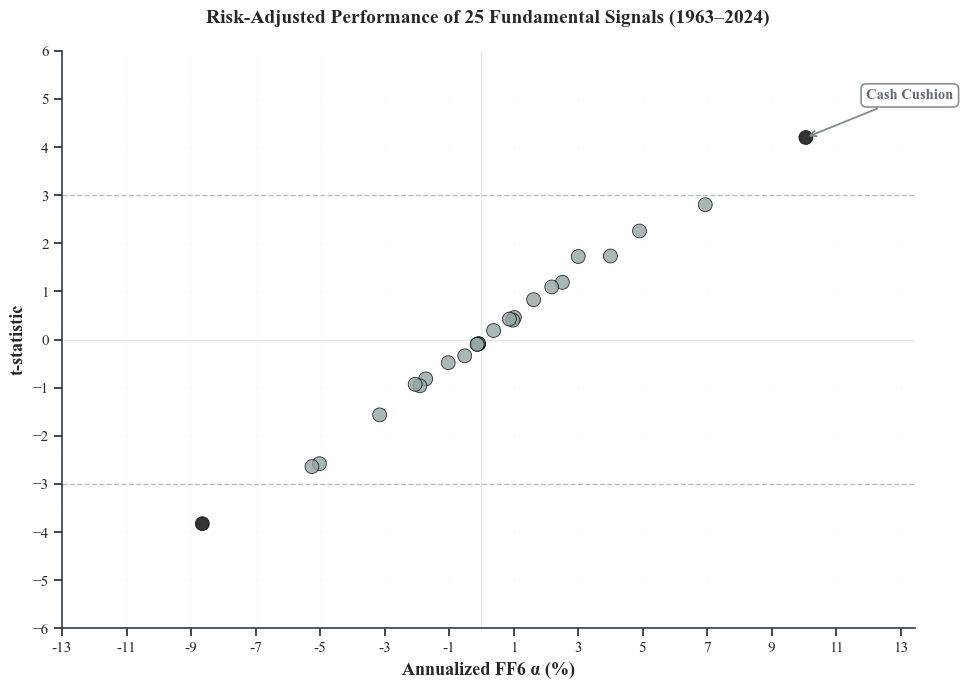


✅ FIGURE AVEC CONVEX HULL : results/figures/03_1_alpha_t-stat_cluster_convex.png

🎯 AMÉLIORATION :
   • Remplacement Ellipse → Convex Hull (polygone minimal)
   • Contour exact autour des 2 signaux significatifs
   • Plus de points gris capturés par erreur !


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib import rcParams
import numpy as np
from pathlib import Path
from scipy.spatial import ConvexHull

# ─────────────────────────────────────────────────────────────────────────
# Configuration publication académique
# ─────────────────────────────────────────────────────────────────────────

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['text.usetex'] = False
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 13
rcParams['axes.titlesize'] = 14
rcParams['axes.titleweight'] = 'bold'
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11
rcParams['legend.fontsize'] = 10.5

# ─────────────────────────────────────────────────────────────────────────
# 1. Préparation des données
# ─────────────────────────────────────────────────────────────────────────

df_plot = df_results_theory[['signal', 'alpha_vw', 't_stat_vw']].copy()

# ─────────────────────────────────────────────────────────────────────────
# 2. Configuration du Graphique
# ─────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 7.5), facecolor='white')
ax.set_facecolor('white')

# Seuils de significativité
ax.axhline(y=3.0, color='#34495E', linestyle='--', linewidth=1.0, alpha=0.35, zorder=1)
ax.axhline(y=-3.0, color='#34495E', linestyle='--', linewidth=1.0, alpha=0.35, zorder=1)
ax.axhline(y=0, color='#7F8C8D', linestyle='-', linewidth=0.6, alpha=0.25, zorder=1)
ax.axvline(x=0, color='#7F8C8D', linestyle='-', linewidth=0.6, alpha=0.25, zorder=1)

# ─────────────────────────────────────────────────────────────────────────
# 3. IDENTIFIER CLUSTER AVEC abs(t_stat_vw) > 3
# ─────────────────────────────────────────────────────────────────────────

cluster_data = df_plot[df_plot['t_stat_vw'].abs() > 3.0].copy()

print(f"\n📍 CLUSTER DÉTECTÉ : {len(cluster_data)} signaux avec |t-stat| > 3")
print(cluster_data[['signal', 'alpha_vw', 't_stat_vw']].to_string(index=False))

# Colorer en rouge les signaux du cluster
df_plot['color'] = '#95A5A6'  # Gris par défaut
df_plot.loc[df_plot['signal'].isin(cluster_data['signal']), 'color'] = "#000000"  # Rouge si significatif

# ─────────────────────────────────────────────────────────────────────────
# 4. Plot des points
# ─────────────────────────────────────────────────────────────────────────

ax.scatter(
    df_plot['alpha_vw'], 
    df_plot['t_stat_vw'],
    c=df_plot['color'],
    s=100, 
    alpha=0.8, 
    edgecolors='black', 
    linewidth=0.6, 
    zorder=3
)

# ─────────────────────────────────────────────────────────────────────────
# 5. CALCUL DES RANGES
# ─────────────────────────────────────────────────────────────────────────

alpha_range = df_plot['alpha_vw'].max() - df_plot['alpha_vw'].min()
t_range = df_plot['t_stat_vw'].max() - df_plot['t_stat_vw'].min()

# ─────────────────────────────────────────────────────────────────────────
# 6. ✅ CONVEX HULL : CONTOUR EXACT AUTOUR DES POINTS SIGNIFICATIFS
# ─────────────────────────────────────────────────────────────────────────

if len(cluster_data) >= 3:  # ConvexHull nécessite ≥ 3 points
    
    # Préparer les points (x, y)
    points = cluster_data[['alpha_vw', 't_stat_vw']].values
    
    # Calculer l'enveloppe convexe
    hull = ConvexHull(points)
    
    # Extraire les sommets du polygone (dans l'ordre)
    hull_points = points[hull.vertices]
    
    # Tracer le polygone
    polygon = Polygon(
        hull_points, 
        edgecolor='#E74C3C', 
        facecolor='none', 
        linestyle='--', 
        linewidth=1.5, 
        alpha=0.75, 
        zorder=2
    )
    ax.add_patch(polygon)
    
    # ✅ ANNOTATION : Calculer centre du cluster pour positionner le texte
    center_x = cluster_data['alpha_vw'].mean()
    center_y = cluster_data['t_stat_vw'].mean()
    
    # Position annotation (EN BAS À DROITE du cluster)
    x_offset = +0.15 * alpha_range
    y_offset = -0.12 * t_range
    
    ax.annotate(
        'Overvaluation Cluster\n(Growth & Quality)',
        xy=(center_x, center_y), 
        xytext=(center_x + x_offset, center_y + y_offset),
        fontsize=10.5, 
        weight='bold', 
        color='#C0392B',
        ha='center',
        arrowprops=dict(
            arrowstyle='->', 
            connectionstyle="arc3,rad=0.2", 
            color='#E74C3C', 
            lw=1.3
        ),
        bbox=dict(
            boxstyle="round,pad=0.35", 
            fc="white", 
            ec="#E74C3C", 
            linewidth=1.2,
            alpha=0.95
        ),
        zorder=5
    )
    
    print(f"✅ Convex Hull tracé avec {len(hull.vertices)} sommets")

else:
    print(f"⚠️  Pas assez de points pour Convex Hull ({len(cluster_data)} < 3)")

# ─────────────────────────────────────────────────────────────────────────
# 7. ANNOTATION CASH CUSHION (inchangé)
# ─────────────────────────────────────────────────────────────────────────

cash_row = df_plot[df_plot['signal'] == 'cash_cushion']

if not cash_row.empty:
    cash_x = cash_row['alpha_vw'].iloc[0]
    cash_y = cash_row['t_stat_vw'].iloc[0]
    
    x_offset = 0.10 * alpha_range
    y_offset = 0.10 * t_range
    
    ax.annotate(
        'Cash Cushion',
        xy=(cash_x, cash_y),
        xytext=(cash_x + x_offset, cash_y + y_offset),
        fontsize=10.5, 
        weight='bold', 
        color='#5D6D7E',
        ha='left',
        arrowprops=dict(
            arrowstyle='->', 
            color='#7F8C8D', 
            lw=1.3
        ),
        bbox=dict(
            boxstyle="round,pad=0.35", 
            fc="white", 
            ec="#7F8C8D",
            linewidth=1.2,
            alpha=0.95
        ),
        zorder=5
    )

# ─────────────────────────────────────────────────────────────────────────
# 8. Titres et Labels
# ─────────────────────────────────────────────────────────────────────────

ax.set_xlabel('Annualized FF6 α (%)', fontsize=13, weight='bold')
ax.set_ylabel('t-statistic', fontsize=13, weight='bold')
ax.set_title(
    'Risk-Adjusted Performance of 25 Fundamental Signals (1963–2024)',
    fontsize=14,
    weight='bold',
    pad=20
)

ax.grid(True, alpha=0.12, linestyle=':', linewidth=0.5, color='#BDC3C7', zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_color('#2C3E50')
ax.spines['bottom'].set_color('#2C3E50')

# ─────────────────────────────────────────────────────────────────────────
# 9. LIMITES AXES + GRADUATIONS
# ─────────────────────────────────────────────────────────────────────────

x_min = df_plot['alpha_vw'].min() - 0.18 * alpha_range
x_max = df_plot['alpha_vw'].max() + 0.18 * alpha_range
ax.set_xlim(x_min, x_max)

x_min_annual = x_min * 12
x_max_annual = x_max * 12
x_min_tick = int(np.floor(x_min_annual))
x_max_tick = int(np.ceil(x_max_annual))
xticks_annual = np.arange(x_min_tick, x_max_tick + 1, 2)
xticks_monthly = xticks_annual / 12
ax.set_xticks(xticks_monthly)
ax.set_xticklabels([f'{x:.0f}' for x in xticks_annual])

y_min_auto = df_plot['t_stat_vw'].min() - 0.18 * t_range
y_max_auto = df_plot['t_stat_vw'].max() + 0.18 * t_range
y_max_final = max(y_max_auto, 3.5)
ax.set_ylim(y_min_auto, y_max_final)

y_min_tick = int(np.floor(y_min_auto))
y_max_tick = int(np.ceil(y_max_final))
yticks_final = np.arange(y_min_tick, y_max_tick + 1, 1)
ax.set_yticks(yticks_final)

ax.tick_params(axis='both', which='major', length=6, width=1.2, labelsize=11)

# ─────────────────────────────────────────────────────────────────────────
# 10. Export
# ─────────────────────────────────────────────────────────────────────────

output_dir = Path('results/figures')
output_dir.mkdir(parents=True, exist_ok=True)

output_file_png = output_dir / '03_1_alpha_t-stat_cluster_convex.png'
plt.savefig(output_file_png, format='png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

print(f"\n{'='*80}")
print(f"✅ FIGURE AVEC CONVEX HULL : {output_file_png}")
print(f"{'='*80}")
print(f"\n🎯 AMÉLIORATION :")
print(f"   • Remplacement Ellipse → Convex Hull (polygone minimal)")
print(f"   • Contour exact autour des {len(cluster_data)} signaux significatifs")
print(f"   • Plus de points gris capturés par erreur !")

### Results : table 2

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# ═══════════════════════════════════════════════════════════════════════════
# 📊 GÉNÉRER RÉGRESSIONS CAPM / FF3 / FF6 POUR TOUS LES SIGNAUX
# ═══════════════════════════════════════════════════════════════════════════

def run_regressions_all_models(portfolio_dir, ff5, signal_direction_map):
    """
    Calcule alpha CAPM, FF3, FF6 pour tous les signaux.
    
    ✅ CORRECTION : 
        - Calcul sur rendements BRUTS long-short (pas de soustraction rf)
        - Mapping des noms de signaux via SIGNAL_NAME_MAP
    
    OUTPUT: DataFrame avec [signal, signal_clean, model, alpha, alpha_tstat, ...]
    """
    
    results = []
    
    portfolio_path = Path(portfolio_dir)
    files = list(portfolio_path.glob("*_signal.parquet"))
    
    print(f"🔄 Calcul régressions CAPM/FF3/FF6 pour {len(files)} signaux...\n")
    
    for i, file in enumerate(files, 1):
        signal_name = file.stem.replace('_signal', '')
        
        print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
        
        if signal_name not in signal_direction_map:
            continue
        
        try:
            # ═════════════════════════════════════════════════════════════
            # 1. CHARGER RETURNS (BRUTS)
            # ═════════════════════════════════════════════════════════════
            
            returns_full = pd.read_parquet(file)
            returns_full['date'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)
            returns_full = returns_full[returns_full['date'] <= pd.to_datetime('2024-06-30')].set_index('date')
            
            # Merge avec FF factors
            ff5_copy = ff5.copy()
            ff5_copy.index = pd.to_datetime(ff5_copy.index) + pd.offsets.MonthEnd(0)
            
            df_merged = returns_full.merge(ff5_copy, left_index=True, right_index=True, how='inner')
            
            if len(df_merged) < 60:
                continue
            
            # ═════════════════════════════════════════════════════════════
            # 2. DÉTERMINER DIRECTION ET RETURNS (BRUTS LONG-SHORT)
            # ═════════════════════════════════════════════════════════════
            
            direction = signal_direction_map[signal_name]
            
            if direction == 'P10-P1':
                ret_ls = df_merged['ret_high_vw'] - df_merged['ret_low_vw']
            else:
                ret_ls = df_merged['ret_ls_vw']
            
            # ✅ CORRECTION : Long-short = autofinancé, PAS de soustraction rf
            Y = ret_ls.dropna()
            
            # ═════════════════════════════════════════════════════════════
            # 3. ✅ MAPPER NOM DU SIGNAL (UTILISER SIGNAL_NAME_MAP)
            # ═════════════════════════════════════════════════════════════
            
            signal_clean = clean_signal_name(signal_name)
            
            # ══════════════════════════════════════════════════════════
            # RÉGRESSION 1 : CAPM (Market only)
            # ══════════════════════════════════════════════════════════
            
            X_capm = df_merged.loc[Y.index, ['mktrf']]
            X_capm = sm.add_constant(X_capm)
            
            model_capm = sm.OLS(Y, X_capm, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags':12})
            
            results.append({
                'signal': signal_name,
                'signal_clean': signal_clean,
                'model': 'CAPM',
                'alpha': model_capm.params['const'],
                'alpha_tstat': model_capm.tvalues['const'],
                'r_squared': model_capm.rsquared,
                'n_obs': len(Y)
            })
            
            # ══════════════════════════════════════════════════════════
            # RÉGRESSION 2 : FF3 (Market + Size + Value)
            # ══════════════════════════════════════════════════════════
            
            X_ff3 = df_merged.loc[Y.index, ['mktrf', 'smb', 'hml']]
            X_ff3 = sm.add_constant(X_ff3)
            
            model_ff3 = sm.OLS(Y, X_ff3, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags':12})
            
            results.append({
                'signal': signal_name,
                'signal_clean': signal_clean,
                'model': 'FF3',
                'alpha': model_ff3.params['const'],
                'alpha_tstat': model_ff3.tvalues['const'],
                'r_squared': model_ff3.rsquared,
                'n_obs': len(Y)
            })
            
            # ══════════════════════════════════════════════════════════
            # RÉGRESSION 3 : FF6 (FF3 + Profitability + Investment + Momentum)
            # ══════════════════════════════════════════════════════════
            
            mom_col = 'mom' if 'mom' in df_merged.columns else 'umd'
            X_ff6 = df_merged.loc[Y.index, ['mktrf', 'smb', 'hml', 'rmw', 'cma', mom_col]]
            X_ff6 = sm.add_constant(X_ff6)
            
            model_ff6 = sm.OLS(Y, X_ff6, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags':12})
            
            results.append({
                'signal': signal_name,
                'signal_clean': signal_clean,
                'model': 'FF6',
                'alpha': model_ff6.params['const'],
                'alpha_tstat': model_ff6.tvalues['const'],
                'r_squared': model_ff6.rsquared,
                'n_obs': len(Y)
            })
            
        except Exception as e:
            print(f"\n⚠️  Erreur {signal_name}: {e}")
            continue
    
    print(f"\n\n✅ Régressions terminées : {len(results)} résultats")
    
    return pd.DataFrame(results)

# ═══════════════════════════════════════════════════════════════════════════
# EXÉCUTION
# ═══════════════════════════════════════════════════════════════════════════

df_regressions = run_regressions_all_models(
    portfolio_dir=CONFIG['portfolio_dir'],
    ff5=ff5,
    signal_direction_map=SIGNAL_DIRECTION_MAP
)

# ═══════════════════════════════════════════════════════════════════════════
# ✅ CORRECTION PATH EXPORT (CRÉER DOSSIER SI NÉCESSAIRE)
# ═══════════════════════════════════════════════════════════════════════════

output_dir = Path('results/latex/regressions')
output_dir.mkdir(parents=True, exist_ok=True)  # ✅ Créer dossier + parents

output_file = output_dir / 'results_regression_all_signals.parquet'
df_regressions.to_parquet(output_file, index=False)

print(f"\n{'='*80}")
print(f"✅ FICHIER CRÉÉ : {output_file}")
print(f"{'='*80}")
print(f"\n📊 Aperçu (15 premiers avec noms propres) :")
print(df_regressions[['signal_clean', 'model', 'alpha', 'alpha_tstat', 'r_squared']].head(15).to_string(index=False))
print(f"\n💾 Total : {len(df_regressions)} régressions (CAPM/FF3/FF6 × {len(df_regressions)//3} signaux)")

# ═══════════════════════════════════════════════════════════════════════════
# 📊 VÉRIFICATION MAPPING (Afficher correspondances)
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"📋 VÉRIFICATION MAPPING (5 exemples) :")
print(f"{'='*80}")
sample_mapping = df_regressions[['signal', 'signal_clean']].drop_duplicates().head(5)
print(sample_mapping.to_string(index=False))

🔄 Calcul régressions CAPM/FF3/FF6 pour 25 signaux...

   25/25 | cash_cushion                  

✅ Régressions terminées : 75 résultats

✅ FICHIER CRÉÉ : results/latex/regressions/results_regression_all_signals.parquet

📊 Aperçu (15 premiers avec noms propres) :
           signal_clean model     alpha  alpha_tstat  r_squared
     Investment Quality  CAPM  0.000166     0.100241   0.004187
     Investment Quality   FF3  0.001634     1.058297   0.092548
     Investment Quality   FF6  0.000322     0.225140   0.217469
    Leverage Efficiency  CAPM -0.001494    -0.981283   0.011620
    Leverage Efficiency   FF3 -0.000818    -0.538461   0.037042
    Leverage Efficiency   FF6 -0.000717    -0.484317   0.044384
Depreciation Efficiency  CAPM  0.002160     1.021885   0.013459
Depreciation Efficiency   FF3  0.001747     0.881526   0.025480
Depreciation Efficiency   FF6  0.000154     0.086660   0.101372
      Asset Tangibility  CAPM -0.003324    -2.061931   0.034351
      Asset Tangibility   FF3 -0.

In [69]:
import pandas as pd
import numpy as np

# ═══════════════════════════════════════════════════════════════════════════
# 🔍 ÉTAPE 1 : IDENTIFIER AUTOMATIQUEMENT LES SIGNAUX DU CLUSTER (|t-stat| > 3)
# ═══════════════════════════════════════════════════════════════════════════

# Charger résultats régressions
results_path = 'results/latex/regressions/results_regression_all_signals.parquet'
df_results = pd.read_parquet(results_path)

# Filtrer modèle FF6 uniquement
df_ff6 = df_results[df_results['model'] == 'FF6'].copy()

# ✅ IDENTIFIER SIGNAUX AVEC |t-stat| > 3
significant_signals = df_ff6[df_ff6['alpha_tstat'].abs() > 3.0]['signal'].unique().tolist()

# ✅ AJOUTER CASH CUSHION (si pas déjà présent)
if 'cash_cushion' not in significant_signals:
    significant_signals.append('cash_cushion')

print(f"\n{'='*80}")
print(f"📊 SIGNAUX SÉLECTIONNÉS (|t-stat| > 3 + Cash Cushion) : {len(significant_signals)}")
print(f"{'='*80}")
for signal in sorted(significant_signals):
    tstat = df_ff6[df_ff6['signal'] == signal]['alpha_tstat'].iloc[0]
    alpha = df_ff6[df_ff6['signal'] == signal]['alpha'].iloc[0] * 12 * 100
    print(f"   • {signal:<30} | α = {alpha:+7.2f}% | t = {tstat:+6.2f}")

# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

TARGET_SIGNALS = significant_signals  # ✅ Liste dynamique

TSTAT_THRESHOLDS = {
    '***': 3.0,
    '**': 2.0,
    '*': 1.65
}

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 : CHARGER ET FILTRER
# ═══════════════════════════════════════════════════════════════════════════

df_table2 = df_results[df_results['signal'].isin(TARGET_SIGNALS)].copy()

print(f"\n✓ Loaded {len(df_table2)} regression results (CAPM/FF3/FF6 × {len(TARGET_SIGNALS)} signaux)")

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 : MAPPER NOMS PROPRES (UTILISER SIGNAL_NAME_MAP)
# ═══════════════════════════════════════════════════════════════════════════

# Utiliser la fonction clean_signal_name() déjà définie dans le notebook
# qui utilise SIGNAL_NAME_MAP

df_table2['signal_clean'] = df_table2['signal'].apply(clean_signal_name)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 4 : PIVOTER (CAPM / FF3 / FF6)
# ═══════════════════════════════════════════════════════════════════════════

pivot_data = []

for signal in df_table2['signal'].unique():
    signal_data = df_table2[df_table2['signal'] == signal]
    signal_clean = signal_data['signal_clean'].iloc[0]
    
    row = {'Signal': signal_clean}
    
    for model in ['CAPM', 'FF3', 'FF6']:
        model_data = signal_data[signal_data['model'] == model]
        
        if len(model_data) > 0:
            alpha = model_data['alpha'].iloc[0] * 12 * 100  # Annualisé %
            tstat = model_data['alpha_tstat'].iloc[0]
        else:
            alpha = np.nan
            tstat = np.nan
        
        row[f'{model}_alpha'] = alpha
        row[f'{model}_tstat'] = tstat
    
    pivot_data.append(row)

df_pivot = pd.DataFrame(pivot_data)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 5 : TRI PAR |ALPHA FF6| DÉCROISSANT (garder négatifs visibles)
# ═══════════════════════════════════════════════════════════════════════════

df_pivot = df_pivot.sort_values('FF6_alpha', ascending=False).reset_index(drop=True)

print(f"\n✓ Pivoted data (sorted by Alpha FF6 descending):")
print(df_pivot[['Signal', 'FF6_alpha', 'FF6_tstat']])

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 6 : GÉNÉRER LATEX
# ═══════════════════════════════════════════════════════════════════════════

def add_stars(tstat: float) -> str:
    abs_t = abs(tstat)
    if abs_t >= 3.0: return r'^{***}'
    elif abs_t >= 2.0: return r'^{**}'
    elif abs_t >= 1.65: return r'^{*}'
    return ''

def generate_latex_table_academic(df: pd.DataFrame, caption: str, label: str) -> str:
    latex = []
    
    latex.append(r'\begin{table}[htbp]')
    latex.append(r'  \centering')
    latex.append(r'  \caption{' + caption + r'}')
    latex.append(r'  \label{' + label + r'}')
    latex.append(r'  \resizebox{0.37\textwidth}{!}{%')
    latex.append(r'  \begin{tabular}{l*{3}{c}}')
    latex.append(r'    \toprule')
    latex.append(r'    & \multicolumn{1}{c}{\textbf{CAPM}} & \multicolumn{1}{c}{\textbf{FF3}} & \multicolumn{1}{c}{\textbf{FF6}} \\')
    latex.append(r'    \midrule')
    
    for idx, row in df.iterrows():
        signal = row['Signal']
        
        # Ligne 1 : Alphas avec étoiles
        alpha_capm = f"{row['CAPM_alpha']:.2f}"
        alpha_ff3 = f"{row['FF3_alpha']:.2f}"
        alpha_ff6 = f"{row['FF6_alpha']:.2f}"
        
        stars_capm = add_stars(row['CAPM_tstat'])
        stars_ff3 = add_stars(row['FF3_tstat'])
        stars_ff6 = add_stars(row['FF6_tstat'])
        
        latex.append(f'    {signal} & ${alpha_capm}{stars_capm}$ & ${alpha_ff3}{stars_ff3}$ & ${alpha_ff6}{stars_ff6}$ \\\\')
        
        # Ligne 2 : t-stats (italique)
        tstat_capm = f"({row['CAPM_tstat']:.2f})"
        tstat_ff3 = f"({row['FF3_tstat']:.2f})"
        tstat_ff6 = f"({row['FF6_tstat']:.2f})"
        
        if idx < len(df) - 1:
            latex.append(f'    & \\textit{{{tstat_capm}}} & \\textit{{{tstat_ff3}}} & \\textit{{{tstat_ff6}}} \\\\[1mm]')
        else:
            latex.append(f'    & \\textit{{{tstat_capm}}} & \\textit{{{tstat_ff3}}} & \\textit{{{tstat_ff6}}} \\\\')
    
    latex.append(r'    \bottomrule \\')
    latex.append(r'  \end{tabular}%')
    latex.append(r'  }% fin resizebox')
    latex.append(r'  \begin{minipage}{\textwidth}')
    latex.append(r'    \vspace{0.2cm}')
    latex.append(r'    \scriptsize')
    latex.append(r'    \textit{Notes:} This table reports annualized alphas (in \%) for value-weighted long-short portfolios of signals identified in the overvaluation cluster (|t-stat| > 3), plus Cash Cushion. ')
    latex.append(r'    We control for market risk (CAPM), size and value factors (FF3), and profitability, investment, and momentum factors (FF6). ')
    latex.append(r'    \textit{t}-statistics (in parentheses) are Newey-West adjusted with 12 lags. ')
    latex.append(r'    $^{*}$, $^{**}$, and $^{***}$ denote significance at the 10\%, 5\%, and 1\% levels, respectively.')
    latex.append(r'  \end{minipage}')
    latex.append(r'\end{table}')
    
    return '\n'.join(latex)

caption = 'Risk-Adjusted Returns: Overvaluation Cluster'
label = 'tab:04_alpha_progression'

latex_code = generate_latex_table_academic(df_pivot, caption, label)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 7 : EXPORT
# ═══════════════════════════════════════════════════════════════════════════

output_path = 'results/latex/results_2_alpha_progression.tex'
with open(output_path, 'w') as f:
    f.write(latex_code)

print(f"\n{'='*80}")
print(f"✅ TABLE 2 GENERATED (CLUSTER + CASH CUSHION)")
print(f"{'='*80}")
print(f"\n📁 LaTeX saved: {output_path}")
print(f"📊 Signaux inclus : {len(df_pivot)}")
print(f"\n📋 PREVIEW:")
print(df_pivot[['Signal', 'FF6_alpha', 'FF6_tstat']].to_string(index=False))


📊 SIGNAUX SÉLECTIONNÉS (|t-stat| > 3 + Cash Cushion) : 1
   • cash_cushion                   | α =  +10.26% | t =  +4.00

✓ Loaded 3 regression results (CAPM/FF3/FF6 × 1 signaux)

✓ Pivoted data (sorted by Alpha FF6 descending):
         Signal  FF6_alpha  FF6_tstat
0  Cash Cushion  10.257787    3.99533

✅ TABLE 2 GENERATED (CLUSTER + CASH CUSHION)

📁 LaTeX saved: results/latex/results_2_alpha_progression.tex
📊 Signaux inclus : 1

📋 PREVIEW:
      Signal  FF6_alpha  FF6_tstat
Cash Cushion  10.257787    3.99533


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 APPENDIX TABLE : FF6 REGRESSIONS (Alpha + All Betas) - TOUS LES SIGNAUX
# ═══════════════════════════════════════════════════════════════════════════

def compute_ff6_regression(portfolio_data, ff_data, signal_direction):
    """
    Calcule régression FF6 pour un signal donné (STRATÉGIE LONG-SHORT).
    
    ✅ CORRECTION : Pas de soustraction rf pour stratégie autofinancée
    
    Returns:
        dict avec alpha, t-stats, betas, R², N
    """
    # Normaliser dates
    portfolio_data = portfolio_data.copy()
    portfolio_data['date'] = pd.to_datetime(portfolio_data['date']) + pd.offsets.MonthEnd(0)
    
    ff_data_copy = ff_data.copy()
    ff_data_copy.index = pd.to_datetime(ff_data_copy.index) + pd.offsets.MonthEnd(0)
    
    # Merge
    merged = portfolio_data.merge(ff_data_copy, left_on='date', right_index=True, how='inner')
    
    # ═══════════════════════════════════════════════════════════════════
    # DÉTERMINER RETURNS SELON DIRECTION (LONG-SHORT)
    # ═══════════════════════════════════════════════════════════════════
    
    if signal_direction == 'P10-P1':
        ret_ls = merged['ret_high_vw'] - merged['ret_low_vw']
    else:  # P1-P10
        ret_ls = merged['ret_ls_vw']
    
    # ✅ CORRECTION : Pas de soustraction rf (stratégie autofinancée)
    # AVANT : excess_ret = ret_ls - merged['rf']
    # APRÈS : Utiliser directement ret_ls
    
    # Facteurs FF6
    factor_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']
    
    # Préparer régression (Y = returns long-short BRUTS)
    Y = ret_ls.dropna()
    X = merged.loc[Y.index, factor_cols]
    X = sm.add_constant(X)
    
    # OLS avec Newey-West
    model = sm.OLS(Y, X, missing='drop')
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    return {
        'alpha': results.params['const'],
        'alpha_tstat': results.tvalues['const'],
        'beta_mkt': results.params['mktrf'],
        'beta_mkt_tstat': results.tvalues['mktrf'],
        'beta_smb': results.params['smb'],
        'beta_smb_tstat': results.tvalues['smb'],
        'beta_hml': results.params['hml'],
        'beta_hml_tstat': results.tvalues['hml'],
        'beta_rmw': results.params['rmw'],
        'beta_rmw_tstat': results.tvalues['rmw'],
        'beta_cma': results.params['cma'],
        'beta_cma_tstat': results.tvalues['cma'],
        'beta_mom': results.params['umd'],
        'beta_mom_tstat': results.tvalues['umd'],
        'r_squared': results.rsquared,
        'n_obs': int(results.nobs)
    }

def generate_appendix_ff6_table(portfolio_dir, ff_data, signal_direction_map, output_file):
    """
    Génère table LaTeX avec TOUS les signaux (noms propres via clean_signal_name).
    """
    
    results = []
    
    portfolio_path = Path(portfolio_dir)
    files = list(portfolio_path.glob('*_signal.parquet'))
    
    print(f"\n🔄 Génération table Appendix FF6 pour {len(files)} signaux...")
    
    for i, file in enumerate(files, 1):
        signal_name = file.stem.replace('_signal', '')
        
        if signal_name not in signal_direction_map:
            continue
        
        print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
        
        try:
            portfolio_data = pd.read_parquet(file)
            direction = signal_direction_map[signal_name]
            
            res = compute_ff6_regression(portfolio_data, ff_data, direction)
            res['signal'] = signal_name
            results.append(res)
            
        except Exception as e:
            print(f"\n⚠️  Erreur {signal_name}: {e}")
            continue
    
    df = pd.DataFrame(results)
    
    # Annualiser alpha
    df['alpha_annual'] = df['alpha'] * 12 * 100
    
    # Trier par alpha décroissant
    df = df.sort_values('alpha_annual', ascending=False).reset_index(drop=True)
    
    # ✅ MAPPER NOMS PROPRES
    df['signal_clean'] = df['signal'].apply(clean_signal_name)
    
    # ═════════════════════════════════════════════════════════════════
    # GÉNÉRER LATEX (✅ CORRECTION ESCAPING)
    # ═════════════════════════════════════════════════════════════════
    
    def add_stars(tstat):
        abs_t = abs(tstat)
        if abs_t > 3.0: return r'^{***}'
        elif abs_t > 2.0: return r'^{**}'
        elif abs_t > 1.65: return r'^{*}'
        return ''
    
    latex = []
    latex.append(r"\begin{table}[htbp]")
    latex.append(r"  \centering")
    latex.append(r"  \caption{FF6 Factor Regressions: Alphas and Betas}")
    latex.append(r"  \caption*{\footnotesize \textit{Notes:} This table reports annualized FF6 alphas (\%) and factor loadings for value-weighted long-short portfolios. Newey-West \textit{t}-statistics (12 lags) are in parentheses. $^{*}$, $^{**}$, $^{***}$ denote significance at 10\%, 5\%, 1\% levels. $R^2$ is adjusted R-squared, $N$ is monthly observations.}")
    latex.append(r"  \label{tab:ff6_appendix}")
    latex.append(r"  \footnotesize")
    latex.append(r"  \begin{tabular}{l*{8}{c}c}")
    latex.append(r"    \toprule")
    latex.append(r"    Signal & $\alpha$ & $\beta_{MKT}$ & $\beta_{SMB}$ & $\beta_{HML}$ & $\beta_{RMW}$ & $\beta_{CMA}$ & $\beta_{MOM}$ & $R^2$ & $N$ \\")
    latex.append(r"    \midrule")
    
    for _, row in df.iterrows():
        signal_clean = row['signal_clean']
        
        # ✅ CORRECTION : Wrapper chaque valeur dans $...$ pour math mode
        latex.append(
            f"    {signal_clean} & "
            f"${row['alpha_annual']:.2f}{add_stars(row['alpha_tstat'])}$ & "
            f"${row['beta_mkt']:.3f}{add_stars(row['beta_mkt_tstat'])}$ & "
            f"${row['beta_smb']:.3f}{add_stars(row['beta_smb_tstat'])}$ & "
            f"${row['beta_hml']:.3f}{add_stars(row['beta_hml_tstat'])}$ & "
            f"${row['beta_rmw']:.3f}{add_stars(row['beta_rmw_tstat'])}$ & "
            f"${row['beta_cma']:.3f}{add_stars(row['beta_cma_tstat'])}$ & "
            f"${row['beta_mom']:.3f}{add_stars(row['beta_mom_tstat'])}$ & "
            f"{row['r_squared']:.3f} & {int(row['n_obs'])} \\\\"
        )
        
        # Ligne 2 : t-stats (italique)
        latex.append(
            f"    & \\textit{{({row['alpha_tstat']:.2f})}} & "
            f"\\textit{{({row['beta_mkt_tstat']:.2f})}} & "
            f"\\textit{{({row['beta_smb_tstat']:.2f})}} & "
            f"\\textit{{({row['beta_hml_tstat']:.2f})}} & "
            f"\\textit{{({row['beta_rmw_tstat']:.2f})}} & "
            f"\\textit{{({row['beta_cma_tstat']:.2f})}} & "
            f"\\textit{{({row['beta_mom_tstat']:.2f})}} & "
            f" & \\\\[1mm]"
        )
    
    latex.append(r"    \bottomrule")
    latex.append(r"  \end{tabular}")
    latex.append(r"\end{table}")
    
    latex_code = '\n'.join(latex)
    
    with open(output_file, 'w') as f:
        f.write(latex_code)
    
    print(f"\n\n✅ Table sauvegardée : {output_file}")
    print(f"   • Signaux : {len(df)}")
    
    return latex_code, df

# ═══════════════════════════════════════════════════════════════════════════
# EXÉCUTION
# ═══════════════════════════════════════════════════════════════════════════

latex_code, df_appendix = generate_appendix_ff6_table(
    portfolio_dir=CONFIG['portfolio_dir'],
    ff_data=ff5,
    signal_direction_map=SIGNAL_DIRECTION_MAP,
    output_file='results/latex/Appendix_FF6_full.tex'
)

print("\n" + "="*120)
print("📊 APERÇU")
print("="*120)
print(df_appendix[['signal_clean', 'alpha_annual', 'alpha_tstat', 'beta_mkt', 'r_squared']].head(10).to_string(index=False))
print(f"\n✅ Total : {len(df_appendix)} signaux avec régressions complètes")


🔄 Génération table Appendix FF6 pour 25 signaux...
   25/25 | cash_cushion                  

✅ Table sauvegardée : results/latex/Appendix_FF6_full.tex
   • Signaux : 25

📊 APERÇU
         signal_clean  alpha_annual  alpha_tstat  beta_mkt  r_squared
         Cash Cushion     10.257787     3.995330  0.119657   0.323198
     Inventory Margin      5.026055     2.365124 -0.097067   0.143675
Low Capex High Margin      4.425678     2.261119  0.085056   0.214252
     PPE Productivity      4.012268     1.851691 -0.035151   0.069409
    Growth Exhaustion      3.116060     1.573011 -0.066018   0.028264
    Asset Tangibility      2.899925     1.612660  0.032232   0.202909
     Earnings Quality      2.777037     1.654356  0.148918   0.148542
           NOA Change      2.730748     1.230425 -0.044055   0.104384
        EBITDA Margin      1.704650     0.892913  0.147561   0.140577
        Debt Maturity      0.509768     0.236723  0.070908   0.015887

✅ Total : 25 signaux avec régressions complètes


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 TABLE LATEX : FF6 REGRESSIONS (CASH CUSHION + CLUSTER |t-stat| > 3)
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

def compute_ff6_regression_detailed(portfolio_data, ff_data, signal_direction):
    """
    Calcule régression FF6 complète (alpha + tous les betas + t-stats).
    
    Returns:
        dict avec alpha, betas, et leurs t-stats
    """
    # Normaliser dates
    portfolio_data = portfolio_data.copy()
    portfolio_data['date'] = pd.to_datetime(portfolio_data['date']) + pd.offsets.MonthEnd(0)
    
    ff_data_copy = ff_data.copy()
    ff_data_copy.index = pd.to_datetime(ff_data_copy.index) + pd.offsets.MonthEnd(0)
    
    # Merge
    merged = portfolio_data.merge(ff_data_copy, left_on='date', right_index=True, how='inner')
    
    # ═══════════════════════════════════════════════════════════════════
    # CALCULER RETURNS SELON DIRECTION
    # ═══════════════════════════════════════════════════════════════════
    
    if signal_direction == 'P10-P1':
        ret_ls = merged['ret_high_vw'] - merged['ret_low_vw']
    else:  # P1-P10
        if 'ret_ls_vw' in merged.columns:
            ret_ls = merged['ret_ls_vw']
        else:
            ret_ls = merged['ret_low_vw'] - merged['ret_high_vw']

    
    # Facteurs FF6
    factor_cols = ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']
    
    # Régression OLS avec Newey-West (Y = returns long-short BRUTS)
    Y = ret_ls.dropna()
    X = merged.loc[Y.index, factor_cols]
    X = sm.add_constant(X)
    
    model = sm.OLS(Y, X, missing='drop')
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    return {
        'alpha': results.params['const'] * 12 * 100,  # Annualisé en %
        'alpha_tstat': results.tvalues['const'],
        'beta_mkt': results.params['mktrf'],
        'beta_mkt_tstat': results.tvalues['mktrf'],
        'beta_smb': results.params['smb'],
        'beta_smb_tstat': results.tvalues['smb'],
        'beta_hml': results.params['hml'],
        'beta_hml_tstat': results.tvalues['hml'],
        'beta_rmw': results.params['rmw'],
        'beta_rmw_tstat': results.tvalues['rmw'],
        'beta_cma': results.params['cma'],
        'beta_cma_tstat': results.tvalues['cma'],
        'beta_mom': results.params['umd'],
        'beta_mom_tstat': results.tvalues['umd'],
    }

def generate_latex_ff6_cluster():
    """
    Génère table LaTeX pour Cash Cushion + Cluster (|t-stat| > 3).
    """
    
    # ═══════════════════════════════════════════════════════════════════
    # ÉTAPE 1 : IDENTIFIER CLUSTER (|t-stat| > 3)
    # ═══════════════════════════════════════════════════════════════════
    
    cluster_signals = df_results_theory[
        df_results_theory['t_stat_vw'].abs() > 3.0
    ]['signal'].tolist()
    
    # ✅ AJOUTER CASH CUSHION (si absent)
    if 'cash_cushion' not in cluster_signals:
        cluster_signals.insert(0, 'cash_cushion')
    
    print(f"\n{'='*80}")
    print(f"📊 SIGNAUX SÉLECTIONNÉS : {len(cluster_signals)}")
    print(f"{'='*80}")
    
    # ═══════════════════════════════════════════════════════════════════
    # ÉTAPE 2 : CALCULER RÉGRESSIONS FF6
    # ═══════════════════════════════════════════════════════════════════
    
    results = {}
    
    for signal_name in cluster_signals:
        # Direction théorique
        direction = SIGNAL_DIRECTION_MAP.get(signal_name, 'P1-P10')
        
        # Charger portfolio
        portfolio_file = Path(CONFIG['portfolio_dir']) / f"{signal_name}_signal.parquet"
        
        if not portfolio_file.exists():
            print(f"⚠️  {signal_name} : Fichier non trouvé")
            continue
        
        portfolio_data = pd.read_parquet(portfolio_file)
        
        # Calculer régression
        res = compute_ff6_regression_detailed(portfolio_data, ff5, direction)
        res['signal_clean'] = clean_signal_name(signal_name)
        res['direction'] = direction
        results[signal_name] = res
        
        print(f"   • {res['signal_clean']:<30} ({direction}) | α = {res['alpha']:+7.2f}% (t = {res['alpha_tstat']:+6.2f})")
    
    # ═══════════════════════════════════════════════════════════════════
    # ÉTAPE 3 : TRIER PAR ALPHA DÉCROISSANT
    # ═══════════════════════════════════════════════════════════════════
    
    results_sorted = dict(sorted(
        results.items(), 
        key=lambda x: x[1]['alpha'], 
        reverse=True
    ))
    
    # ═══════════════════════════════════════════════════════════════════
    # ÉTAPE 4 : GÉNÉRER LATEX
    # ═══════════════════════════════════════════════════════════════════
    
    def add_stars(tstat):
        abs_t = abs(tstat)
        if abs_t > 3.0: return r'^{***}'
        elif abs_t > 2.0: return r'^{**}'
        elif abs_t > 1.65: return r'^{*}'
        return ''
    
    latex = []
    latex.append(r"\begin{table}[htbp]")
    latex.append(r"\centering")
    latex.append(r"\caption{Fama--French Six-Factor Regressions: Cash Cushion and Overvaluation Cluster (1963--2024)}")
    latex.append(r"\label{tab:ff6_cluster}")
    latex.append(r"\resizebox{0.85\textwidth}{!}{%")
    latex.append(r"\begin{tabular}{lccccccc}")
    latex.append(r"\toprule")
    latex.append(r"Signal & $\alpha$ & $\beta_{MKT}$ & $\beta_{SMB}$ & $\beta_{HML}$ & $\beta_{RMW}$ & $\beta_{CMA}$ & $\beta_{UMD}$ \\")
    latex.append(r"\midrule")
    
    # ──────────────────────────────────────────────────────────────────────
    # LIGNES : TOUS LES SIGNAUX DU CLUSTER
    # ──────────────────────────────────────────────────────────────────────
    
    for i, (signal_name, res) in enumerate(results_sorted.items()):
        
        # Ligne 1 : Coefficients avec étoiles
        latex.append(
            f"{res['signal_clean']} & "
            f"${res['alpha']:.2f}{add_stars(res['alpha_tstat'])}$ & "
            f"${res['beta_mkt']:.3f}{add_stars(res['beta_mkt_tstat'])}$ & "
            f"${res['beta_smb']:.3f}{add_stars(res['beta_smb_tstat'])}$ & "
            f"${res['beta_hml']:.3f}{add_stars(res['beta_hml_tstat'])}$ & "
            f"${res['beta_rmw']:.3f}{add_stars(res['beta_rmw_tstat'])}$ & "
            f"${res['beta_cma']:.3f}{add_stars(res['beta_cma_tstat'])}$ & "
            f"${res['beta_mom']:.3f}{add_stars(res['beta_mom_tstat'])}$ \\\\"
        )
        
        # Ligne 2 : t-stats (italique)
        latex.append(
            f"  & \\textit{{({res['alpha_tstat']:.2f})}} & "
            f"\\textit{{({res['beta_mkt_tstat']:.2f})}} & "
            f"\\textit{{({res['beta_smb_tstat']:.2f})}} & "
            f"\\textit{{({res['beta_hml_tstat']:.2f})}} & "
            f"\\textit{{({res['beta_rmw_tstat']:.2f})}} & "
            f"\\textit{{({res['beta_cma_tstat']:.2f})}} & "
            f"\\textit{{({res['beta_mom_tstat']:.2f})}} \\\\"
        )
        
        # Espacement sauf dernière ligne
        if i < len(results_sorted) - 1:
            latex.append(r"\addlinespace")
    
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}%")
    latex.append(r"}% fin resizebox")
    latex.append(r"\begin{flushleft}")
    latex.append(r"\footnotesize")
    latex.append(r"\textit{Notes:} This table reports Fama--French six-factor regressions for value-weighted long--short portfolios. ")
    latex.append(r"The selection includes Cash Cushion and all signals from the overvaluation cluster (|t-stat| > 3). ")
    latex.append(r"$\alpha$ denotes the annualised FF6 alpha (in \%), ")
    latex.append(r"while $\beta_{MKT}$, $\beta_{SMB}$, $\beta_{HML}$, $\beta_{RMW}$, $\beta_{CMA}$, and $\beta_{UMD}$ are factor loadings. ")
    latex.append(r"Newey--West $t$-statistics (12 lags) are reported in parentheses. ")
    latex.append(r"$^{*}$, $^{**}$, and $^{***}$ denote significance at the 10\%, 5\%, and 1\% levels, respectively.")
    latex.append(r"\end{flushleft}")
    latex.append(r"\end{table}")
    
    latex_code = '\n'.join(latex)
    
    # ═══════════════════════════════════════════════════════════════════
    # ÉTAPE 5 : SAUVEGARDER
    # ═══════════════════════════════════════════════════════════════════
    
    output_dir = Path('results/latex')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    output_file = output_dir / 'results_2-1_regressions_cluster.tex'
    with open(output_file, 'w') as f:
        f.write(latex_code)
    
    print(f"\n{'='*80}")
    print(f"✅ TABLE FF6 CLUSTER EXPORTÉE")
    print(f"{'='*80}")
    print(f"\n📁 Fichier : {output_file}")
    print(f"📊 Signaux : {len(results_sorted)}")
    print(f"\n{'='*80}")
    
    return latex_code, results_sorted

# ═══════════════════════════════════════════════════════════════════════════
# EXÉCUTION
# ═══════════════════════════════════════════════════════════════════════════

latex_code, regression_results = generate_latex_ff6_cluster()


📊 SIGNAUX SÉLECTIONNÉS : 1
   • Cash Cushion                   (P10-P1) | α =  +10.26% (t =  +4.00)

✅ TABLE FF6 CLUSTER EXPORTÉE

📁 Fichier : results/latex/results_2-1_regressions_cluster.tex
📊 Signaux : 1



In [72]:
# 🔬 DIAGNOSTIC : Respect contrainte min_firms (par signal et par année)

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

print("="*100)
print("🔬 DIAGNOSTIC : RESPECT CONTRAINTE min_firms = 10")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 1 : CHARGER TOUS LES PORTFOLIOS
# ═══════════════════════════════════════════════════════════════════════════

portfolio_dir = Path('data/portfolios')
files = list(portfolio_dir.glob('*_signal.parquet'))

print(f"\n📊 Fichiers détectés : {len(files)}")

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 : ANALYSER CHAQUE SIGNAL
# ═══════════════════════════════════════════════════════════════════════════

violations_list = []
summary_stats = []

for file in files:
    signal_name = file.stem.replace('_signal', '')
    
    try:
        df = pd.read_parquet(file)
        
        # Colonnes attendues (noms génériques)
        if 'n_low_firms' not in df.columns or 'n_high_firms' not in df.columns:
            print(f"⚠️  {signal_name} : Colonnes n_low_firms/n_high_firms manquantes")
            continue
        
        # Calculer violations (n < 10 sur LOW ou HIGH)
        df['violation_low'] = df['n_low_firms'] < 10
        df['violation_high'] = df['n_high_firms'] < 10
        df['violation_any'] = df['violation_low'] | df['violation_high']
        
        n_violations = df['violation_any'].sum()
        pct_violations = (n_violations / len(df)) * 100
        
        # Violations par année
        if n_violations > 0:
            viol_by_year = df[df['violation_any']].groupby('year_formed').agg({
                'n_low_firms': 'min',
                'n_high_firms': 'min'
            })
            
            for year, row in viol_by_year.iterrows():
                violations_list.append({
                    'signal': signal_name,
                    'year': year,
                    'min_low': row['n_low_firms'],
                    'min_high': row['n_high_firms']
                })
        
        # Stats globales
        summary_stats.append({
            'Signal': signal_name,
            'N_obs': len(df),
            'N_violations': n_violations,
            'Pct_violations': pct_violations,
            'Min_low_firms': df['n_low_firms'].min(),
            'Min_high_firms': df['n_high_firms'].min(),
            'Mean_low_firms': df['n_low_firms'].mean(),
            'Mean_high_firms': df['n_high_firms'].mean()
        })
        
    except Exception as e:
        print(f"❌ Erreur {signal_name} : {e}")

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 : TABLEAU RÉCAPITULATIF
# ═══════════════════════════════════════════════════════════════════════════

summary_df = pd.DataFrame(summary_stats).sort_values('Pct_violations', ascending=False)

print("\n" + "="*100)
print("📊 TABLEAU RÉCAPITULATIF : VIOLATIONS PAR SIGNAL (Trié par % décroissant)")
print("="*100)

# Formater colonnes
summary_display = summary_df.copy()
summary_display['Pct_violations'] = summary_display['Pct_violations'].apply(lambda x: f"{x:.2f}%")
summary_display['Mean_low_firms'] = summary_display['Mean_low_firms'].apply(lambda x: f"{x:.1f}")
summary_display['Mean_high_firms'] = summary_display['Mean_high_firms'].apply(lambda x: f"{x:.1f}")

print("\n" + summary_display.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 4 : VIOLATIONS DÉTAILLÉES (TOP 10)
# ═══════════════════════════════════════════════════════════════════════════

if len(violations_list) > 0:
    violations_df = pd.DataFrame(violations_list).sort_values(['signal', 'year'])
    
    print("\n" + "="*100)
    print("⚠️  VIOLATIONS DÉTAILLÉES (Années avec min < 10)")
    print("="*100)
    
    # Grouper par signal
    for signal in violations_df['signal'].unique()[:10]:  # Top 10 pires signaux
        signal_viol = violations_df[violations_df['signal'] == signal]
        print(f"\n📍 {signal.upper()} ({len(signal_viol)} violations):")
        print(signal_viol[['year', 'min_low', 'min_high']].to_string(index=False))
else:
    print("\n✅ AUCUNE VIOLATION : Toutes les années respectent min_firms ≥ 10 !")
# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 6 : STATISTIQUES GLOBALES
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("📈 STATISTIQUES GLOBALES")
print("="*100)

total_obs = summary_df['N_obs'].sum()
total_violations = summary_df['N_violations'].sum()
pct_violations_global = (total_violations / total_obs) * 100

print(f"\n✅ Observations totales : {total_obs:,}")
print(f"⚠️  Violations totales   : {total_violations:,} ({pct_violations_global:.2f}%)")
print(f"\n📊 Signaux avec violations > 0% : {(summary_df['N_violations'] > 0).sum()} / {len(summary_df)}")
print(f"✅ Signaux PARFAITS (0 viol.)   : {(summary_df['N_violations'] == 0).sum()} / {len(summary_df)}")

print(f"\n📉 Minimum observé (toutes obs) :")
print(f"   • LOW Firms  : {summary_df['Min_low_firms'].min()}")
print(f"   • HIGH Firms : {summary_df['Min_high_firms'].min()}")

print(f"\n📈 Moyenne observée (toutes obs) :")
print(f"   • LOW Firms  : {summary_df['Mean_low_firms'].mean():.1f}")
print(f"   • HIGH Firms : {summary_df['Mean_high_firms'].mean():.1f}")

print("\n" + "="*100)

🔬 DIAGNOSTIC : RESPECT CONTRAINTE min_firms = 10

📊 Fichiers détectés : 25

📊 TABLEAU RÉCAPITULATIF : VIOLATIONS PAR SIGNAL (Trié par % décroissant)

                 Signal  N_obs  N_violations Pct_violations  Min_low_firms  Min_high_firms Mean_low_firms Mean_high_firms
     investment_quality    738             0          0.00%             13              12           69.9            72.0
    earnings_smoothness    738             0          0.00%             11              11           49.7            43.2
             inv_margin    738             0          0.00%             11              11           38.2            56.4
 asset_turnover_quality    738             0          0.00%             13              12           52.9            57.2
   receivables_turnover    738             0          0.00%             12              12           55.2            46.6
          ebitda_margin    738             0          0.00%             12              12           54.2            5

### Transaction Costs Integration

In [73]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 TABLE LATEX : TURNOVER → GROSS → NET (VW UNIQUEMENT, COMPREHENSIVE)
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

print("="*100)
print("📊 GÉNÉRATION TABLE : TURNOVER → ALPHA GROSS → ALPHA NET (VW)")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 1 : CALCULER POUR TOUS LES SIGNAUX
# ═══════════════════════════════════════════════════════════════════════════

results_comprehensive = []

portfolio_dir = Path(CONFIG['portfolio_dir'])
files = list(portfolio_dir.glob('*_signal.parquet'))

print(f"\n🔄 Traitement de {len(files)} signaux...\n")

for i, file in enumerate(files, 1):
    signal_name = file.stem.replace('_signal', '')
    
    if signal_name not in SIGNAL_DIRECTION_MAP:
        continue
    
    print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
    
    try:
        # ────────────────────────────────────────────────────────────────
        # CHARGER DONNÉES
        # ────────────────────────────────────────────────────────────────
        
        returns_full = pd.read_parquet(file)
        returns_full['date'] = pd.to_datetime(returns_full['date']) + pd.offsets.MonthEnd(0)
        returns_full = returns_full[returns_full['date'] <= cutoff_date].set_index('date')
        
        # Vérifier colonnes turnover
        if 'turnover_low' not in returns_full.columns or 'turnover_high' not in returns_full.columns:
            continue
        

        
        
        # ...existing code... (ligne ~3600)
        
        # ═══════════════════════════════════════════════════════════════
        # ✅ CORRECTION : TURNOVER EST MENSUEL → ANNUALISER ×12
        # ═══════════════════════════════════════════════════════════════
        
        if 'turnover_annual_low' in returns_full.columns and 'turnover_annual_high' in returns_full.columns:
            # Option 1 : Colonnes explicitement nommées "annual" (legacy)
            turnover_ann = (returns_full['turnover_annual_low'].mean() + 
                           returns_full['turnover_annual_high'].mean()) / 2
        
        elif 'turnover_low' in returns_full.columns and 'turnover_high' in returns_full.columns:
            # Option 2 : Colonnes "turnover_low/high" SONT MENSUELLES (diagnostic confirmé)
            turnover_low_monthly = returns_full['turnover_low'].mean()
            turnover_high_monthly = returns_full['turnover_high'].mean()
            
            # ✅ ANNUALISER : ×12 car valeurs mensuelles
            turnover_ann = ((turnover_low_monthly + turnover_high_monthly) / 2) * 12
        
        else:
            turnover_ann = np.nan
        
        # ...existing code...
        

        
        
        # ────────────────────────────────────────────────────────────────
        # CALCULER COÛTS (JUIN UNIQUEMENT)
        # ────────────────────────────────────────────────────────────────
        
        returns_full['year'] = returns_full.index.year
        returns_full['month'] = returns_full.index.month
        returns_full['cost_decimal'] = returns_full['year'].apply(get_transaction_cost_bps) / 10000
        
        is_rebalance = returns_full['month'] == 6
        
        to_low = returns_full['turnover_low']
        to_high = returns_full['turnover_high']
        cost_vw = np.where(is_rebalance, ((to_low + to_high)/100) * returns_full['cost_decimal'], 0)
        
        # ────────────────────────────────────────────────────────────────
        # DÉTERMINER RETURNS SELON DIRECTION
        # ────────────────────────────────────────────────────────────────
        
        direction = SIGNAL_DIRECTION_MAP[signal_name]
        
        if direction == 'P10-P1':
            ret_gross = returns_full['ret_high_vw'] - returns_full['ret_low_vw']
        else:
            ret_gross = returns_full['ret_ls_vw']
        
        ret_net = ret_gross - cost_vw
        
        # ────────────────────────────────────────────────────────────────
        # MERGE AVEC FF FACTORS POUR RÉGRESSIONS
        # ────────────────────────────────────────────────────────────────
        
        ff5_copy = ff5.copy()
        ff5_copy.index = pd.to_datetime(ff5_copy.index) + pd.offsets.MonthEnd(0)
        
        merged = returns_full.merge(ff5_copy, left_index=True, right_index=True, how='inner')
        
        # ────────────────────────────────────────────────────────────────
        # RÉGRESSION FF6 : GROSS
        # ────────────────────────────────────────────────────────────────
        
        excess_ret_gross = ret_gross
        Y_gross = excess_ret_gross.dropna()
        X_gross = merged.loc[Y_gross.index, ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']]
        X_gross = sm.add_constant(X_gross)
        
        model_gross = sm.OLS(Y_gross, X_gross, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
        
        alpha_gross = model_gross.params['const'] * 12 * 100  # Annualisé %
        tstat_gross = model_gross.tvalues['const']
        
        # ────────────────────────────────────────────────────────────────
        # RÉGRESSION FF6 : NET
        # ────────────────────────────────────────────────────────────────
        
        excess_ret_net = ret_net
        Y_net = excess_ret_net.dropna()
        X_net = merged.loc[Y_net.index, ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']]
        X_net = sm.add_constant(X_net)
        
        model_net = sm.OLS(Y_net, X_net, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 12})
        
        alpha_net = model_net.params['const'] * 12 * 100  # Annualisé %
        tstat_net = model_net.tvalues['const']
        
        # ────────────────────────────────────────────────────────────────
        # COST DRAG
        # ────────────────────────────────────────────────────────────────
        
        cost_drag = alpha_gross - alpha_net
        

        
        # ═══════════════════════════════════════════════════════════════════
        # ✅ AJOUT : COST DRAG ABSOLU (sur rendements totaux annualisés)
        # ═══════════════════════════════════════════════════════════════════
        
        mean_ret_gross = ret_gross.mean() * 12 * 100  # Annualisé %
        mean_ret_net = ret_net.mean() * 12 * 100
        
        cost_drag_absolute = mean_ret_gross - mean_ret_net  # ✅ Impact brut
        
        
        # ════════════════════════════════════════════════════════════════
        # LIGNE ~3850 : STOCKAGE (ajouter cost_drag_absolute)
        # ════════════════════════════════════════════════════════════════
        
        results_comprehensive.append({
            'signal': signal_name,
            'signal_clean': clean_signal_name(signal_name),
            'turnover': turnover_ann,
            'alpha_gross': alpha_gross,
            'tstat_gross': tstat_gross,
            'alpha_net': alpha_net,
            'tstat_net': tstat_net,
            'cost_drag': cost_drag,              # Alpha drag
            'cost_drag_absolute': cost_drag_absolute,  # ✅ NOUVEAU
            'n_obs': len(Y_net)
        })
        
    except Exception as e:
        print(f"\n⚠️  Erreur {signal_name}: {e}")
        continue

print(f"\n\n✅ Calculs terminés : {len(results_comprehensive)} signaux")

df_comprehensive = pd.DataFrame(results_comprehensive)

# ✅ TRIER PAR ALPHA NET DÉCROISSANT
df_comprehensive = df_comprehensive.sort_values('alpha_net', ascending=False).reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 : GÉNÉRER LATEX TABLE
# ═══════════════════════════════════════════════════════════════════════════

def add_stars(tstat):
    """Retourne étoiles de significativité."""
    abs_t = abs(tstat)
    if abs_t > 3.0: return r'^{***}'
    elif abs_t > 2.0: return r'^{**}'
    elif abs_t > 1.65: return r'^{*}'
    return ''

latex = []
latex.append(r"\begin{table}[htbp]")
latex.append(r"  \centering")
latex.append(r"  \caption{Transaction Costs and Risk-Adjusted Returns (Value-Weighted, 1963--2024)}")
latex.append(r"  \label{tab:transaction_costs_vw}")
latex.append(r"  \resizebox{0.75\textwidth}{!}{%")
latex.append(r"  \begin{tabular}{l c cc cc cc}")
latex.append(r"    \toprule")
latex.append(r"    & \textbf{Turnover} & \multicolumn{2}{c}{\textbf{Gross Alpha}} & \multicolumn{2}{c}{\textbf{Net Alpha}} & \multicolumn{2}{c}{\textbf{Cost Drag}} \\")
latex.append(r"    \cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8}")
latex.append(r"    \textbf{Signal} & (\%) & $\alpha$ & $t$-stat & $\alpha$ & $t$-stat & $\alpha$ & Abs \\")
latex.append(r"    \midrule")

for _, row in df_comprehensive.iterrows():
    signal_clean = row['signal_clean']
    
    turnover = f"{row['turnover']:.1f}"
    
    alpha_g = f"{row['alpha_gross']:.2f}{add_stars(row['tstat_gross'])}"
    tstat_g = f"({row['tstat_gross']:.2f})"
    
    alpha_n = f"{row['alpha_net']:.2f}{add_stars(row['tstat_net'])}"
    tstat_n = f"({row['tstat_net']:.2f})"
    
    cost_drag_alpha = f"{row['cost_drag']:.2f}"
    cost_drag_abs = f"{row['cost_drag_absolute']:.2f}"  # ✅ NOUVEAU
    
    latex.append(
        f"    {signal_clean} & "
        f"{turnover} & "
        f"${alpha_g}$ & "
        f"\\textit{{{tstat_g}}} & "
        f"${alpha_n}$ & "
        f"\\textit{{{tstat_n}}} & "
        f"{cost_drag_alpha} & "
        f"{cost_drag_abs} \\\\"  # ✅ NOUVEAU
    )

latex.append(r"    \bottomrule")
latex.append(r"  \end{tabular}%")
latex.append(r"  }% fin resizebox")
latex.append(r"  \begin{minipage}{\textwidth}")
latex.append(r"    \vspace{0.2cm}")
latex.append(r"    \footnotesize")
latex.append(r"    \textit{Notes:} This table reports annualized FF6 alphas (\%) for value-weighted long-short portfolios, ")
latex.append(r"    comparing \textbf{gross} (before costs) and \textbf{net} (after costs) performance. ")
latex.append(r"    Turnover represents the average annual portfolio turnover (\%). ")
latex.append(r"    \textbf{Cost Drag ($\alpha$)} measures the reduction in FF6 alpha due to transaction costs, ")
latex.append(r"    while \textbf{Cost Drag (Abs)} captures the impact on total annualized returns. ")
latex.append(r"    Newey-West \textit{t}-statistics (12 lags) are in parentheses. ")
latex.append(r"    $^{*}$, $^{**}$, $^{***}$ denote significance at 10\%, 5\%, 1\% levels.")
latex.append(r"  \end{minipage}")
latex.append(r"\end{table}")

latex_code = '\n'.join(latex)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 : EXPORT
# ═══════════════════════════════════════════════════════════════════════════

output_dir = Path('results/latex')
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / 'results_5_transaction_costs_comprehensive.tex'
with open(output_file, 'w') as f:
    f.write(latex_code)

print(f"\n{'='*100}")
print(f"✅ TABLE COMPREHENSIVE EXPORTÉE : {output_file}")
print(f"{'='*100}")
# ═══════════════════════════════════════════════════════════════════════════
# APERÇU
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n📊 APERÇU (Top 25 par Alpha Net) :")
print(df_comprehensive[['signal_clean', 'turnover', 'alpha_gross', 'alpha_net', 'cost_drag', 'cost_drag_absolute']].head(25).to_string(index=False))

print(f"\n📈 STATISTIQUES GLOBALES :")
print(f"   • Turnover Moyen           : {df_comprehensive['turnover'].mean():7.1f}%")
print(f"   • Alpha Gross Moyen        : {df_comprehensive['alpha_gross'].mean():+7.2f}%")
print(f"   • Alpha Net Moyen          : {df_comprehensive['alpha_net'].mean():+7.2f}%")
print(f"   • Cost Drag (α) Moyen      : {df_comprehensive['cost_drag'].mean():+7.2f}%")
print(f"   • Cost Drag (Abs) Moyen    : {df_comprehensive['cost_drag_absolute'].mean():+7.2f}%")
print(f"   • Signaux α_net > 0        : {(df_comprehensive['alpha_net'] > 0).sum()} / {len(df_comprehensive)}")

print(f"\n💾 CSV exporté : results/transaction_costs_comprehensive_vw.csv")

📊 GÉNÉRATION TABLE : TURNOVER → ALPHA GROSS → ALPHA NET (VW)

🔄 Traitement de 25 signaux...

   25/25 | cash_cushion                  

✅ Calculs terminés : 25 signaux

✅ TABLE COMPREHENSIVE EXPORTÉE : results/latex/results_5_transaction_costs_comprehensive.tex

📊 APERÇU (Top 25 par Alpha Net) :
           signal_clean  turnover  alpha_gross  alpha_net  cost_drag  cost_drag_absolute
           Cash Cushion 31.595279    10.257787  10.196604   0.061183            0.063443
       Inventory Margin 34.625891     5.026055   4.955545   0.070510            0.072210
  Low Capex High Margin 34.607758     4.425678   4.356691   0.068987            0.070977
       PPE Productivity 38.141563     4.012268   3.935611   0.076658            0.079277
      Growth Exhaustion 36.333043     3.116060   3.044016   0.072044            0.073384
      Asset Tangibility 29.056986     2.899925   2.835433   0.064492            0.066026
       Earnings Quality 40.349716     2.777037   2.699642   0.077394            

In [77]:
path = 'data/q5/q5m.csv'

q5= pd.read_csv(path)

print(q5.columns)

q5['year'].min()

Index(['year', 'month', 'R_F', 'R_MKT', 'R_ME', 'R_IA', 'R_ROE', 'R_EG'], dtype='object')


1967

In [103]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 Q5 FACTOR MODEL : HARMONISATION + RÉGRESSIONS
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

print("="*100)
print("📊 Q5 FACTOR MODEL : HARMONISATION + ALPHA CALCULATION")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 1 : CHARGER ET HARMONISER Q5 FACTORS
# ═══════════════════════════════════════════════════════════════════════════

# Charger Q5
q5 = pd.read_csv('data/factors/q5/q5m.csv')

# Créer date (fin de mois)
q5['date'] = pd.to_datetime(
    q5['year'].astype(str) + '-' + q5['month'].astype(str) + '-01'
) + pd.offsets.MonthEnd(0)

# Renommer colonnes pour correspondre à convention académique
q5_clean = q5.rename(columns={
    'R_F': 'rf',
    'R_MKT': 'mkt',      # Market excess return
    'R_ME': 'me',        # Size factor
    'R_IA': 'ia',        # Investment factor
    'R_ROE': 'roe',      # Profitability factor
    'R_EG': 'eg'         # Expected Growth factor
})

# ✅ CONVERTIR EN DÉCIMAL (Q5 est en %)
q5_clean[['rf', 'mkt', 'me', 'ia', 'roe', 'eg']] = q5_clean[['rf', 'mkt', 'me', 'ia', 'roe', 'eg']] / 100

# Set index
q5_clean = q5_clean.set_index('date')[['rf', 'mkt', 'me', 'ia', 'roe', 'eg']]

print(f"\n✅ Q5 Factors chargés :")
print(f"   • Période      : {q5_clean.index.min().date()} → {q5_clean.index.max().date()}")
print(f"   • Observations : {len(q5_clean):,}")
print(f"   • Facteurs     : {list(q5_clean.columns)}")

# Vérifier période de chevauchement avec vos portfolios
portfolio_start = pd.to_datetime('1963-07-31')  # Date typique CRSP
q5_start = q5_clean.index.min()

print(f"\n📊 CHEVAUCHEMENT :")
print(f"   • Vos portfolios commencent : ~1963-07")
print(f"   • Q5 commence              : {q5_start.date()}")
print(f"   • ⚠️  PERTE DE DONNÉES       : 1963-07 → 1967-01 (environ 43 mois)")

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 : FONCTION RÉGRESSION Q5 (CORRECTION)
# ═══════════════════════════════════════════════════════════════════════════

def compute_q5_alpha(portfolio_data, q5_data, signal_direction):
    """
    Calcule alpha Q5 pour une stratégie long-short.
    
    Args:
        portfolio_data: DataFrame avec returns_full
        q5_data: DataFrame avec Q5 factors
        signal_direction: 'P10-P1' ou 'P1-P10'
    
    Returns:
        dict avec alpha, t-stat, betas, R²
    """
    
    # Normaliser dates
    portfolio_data = portfolio_data.copy()
    portfolio_data['date'] = pd.to_datetime(portfolio_data['date']) + pd.offsets.MonthEnd(0)
    
    # Merge avec Q5
    q5_copy = q5_data.copy()
    merged = portfolio_data.merge(q5_copy, left_on='date', right_index=True, how='inner')
    
    if len(merged) < 60:
        return None
    
    # ═══════════════════════════════════════════════════════════════════
    # CALCULER RETURNS SELON DIRECTION
    # ═══════════════════════════════════════════════════════════════════
    
    if signal_direction == 'P10-P1':
        if 'ret_high_vw' in merged.columns and 'ret_low_vw' in merged.columns:
            ret_ls = merged['ret_high_vw'] - merged['ret_low_vw']
        else:
            return None
    else:  # P1-P10
        if 'ret_ls_vw' in merged.columns:
            ret_ls = merged['ret_ls_vw']
        else:
            return None
    
    # ✅ PAS DE SOUSTRACTION rf (stratégie autofinancée)
    Y = ret_ls.dropna()
    
    # Facteurs Q5
    factor_cols = ['mkt', 'me', 'ia', 'roe', 'eg']
    X = merged.loc[Y.index, factor_cols]
    X = sm.add_constant(X)
    
    # OLS avec Newey-West
    model = sm.OLS(Y, X, missing='drop')
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    # ✅ CORRECTION : Récupérer 'date' depuis merged (pas Y.index)
    dates_used = merged.loc[Y.index, 'date']
    
    return {
        'alpha': results.params['const'] * 12 * 100,  # Annualisé %
        'alpha_tstat': results.tvalues['const'],
        'beta_mkt': results.params['mkt'],
        'beta_me': results.params['me'],
        'beta_ia': results.params['ia'],
        'beta_roe': results.params['roe'],
        'beta_eg': results.params['eg'],
        'r_squared': results.rsquared,
        'n_obs': int(results.nobs),
        'period_start': dates_used.min().strftime('%Y-%m'),  # ✅ FIX ICI
        'period_end': dates_used.max().strftime('%Y-%m')      # ✅ FIX ICI
    }
# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 : CALCULER POUR TOUS LES SIGNAUX
# ═══════════════════════════════════════════════════════════════════════════

results_q5 = []

portfolio_dir = Path(CONFIG['portfolio_dir'])
files = list(portfolio_dir.glob('*_signal.parquet'))

print(f"\n🔄 Calcul alphas Q5 pour {len(files)} signaux...\n")

for i, file in enumerate(files, 1):
    signal_name = file.stem.replace('_signal', '')
    
    if signal_name not in SIGNAL_DIRECTION_MAP:
        continue
    
    print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
    
    try:
        portfolio_data = pd.read_parquet(file)
        direction = SIGNAL_DIRECTION_MAP[signal_name]
        
        res = compute_q5_alpha(portfolio_data, q5_clean, direction)
        
        if res is None:
            continue
        
        res['signal'] = signal_name
        res['signal_clean'] = clean_signal_name(signal_name)
        res['direction'] = direction
        results_q5.append(res)
        
    except Exception as e:
        print(f"\n⚠️  Erreur {signal_name}: {e}")
        continue

print(f"\n\n✅ Calculs terminés : {len(results_q5)} signaux")

df_q5 = pd.DataFrame(results_q5)

# Trier par alpha décroissant
df_q5 = df_q5.sort_values('alpha', ascending=False).reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 4 : AFFICHAGE RÉSULTATS
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("📊 Q5 ALPHAS (TOUS LES SIGNAUX)")
print("="*120 + "\n")

# Colonnes principales
display_cols = ['signal_clean', 'alpha', 'alpha_tstat', 'r_squared', 'n_obs', 'period_start', 'period_end']
print(df_q5[display_cols].to_string(index=False))

print("\n" + "="*120)



# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 5 : STATISTIQUES COMPARATIVES FF6 vs Q5
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("📊 COMPARAISON FF6 vs Q5")
print("="*100)

# Merger avec résultats FF6 (déjà calculés)
df_comparison = df_q5[['signal', 'alpha', 'alpha_tstat', 'n_obs']].rename(
    columns={'alpha': 'alpha_q5', 'alpha_tstat': 'tstat_q5', 'n_obs': 'n_obs_q5'}
)

# Merger avec FF6 et annualiser alpha
df_ff6_subset = df_results_theory[['signal', 'alpha_vw', 't_stat_vw']].copy()
df_ff6_subset['alpha_ff6'] = df_ff6_subset['alpha_vw'] * 12  # Mensuel → Annuel (%)
df_ff6_subset = df_ff6_subset.rename(columns={'t_stat_vw': 'tstat_ff6'})

# Merge
df_comp = df_comparison.merge(
    df_ff6_subset[['signal', 'alpha_ff6', 'tstat_ff6']], 
    on='signal', 
    how='inner'
)
df_comp['signal_clean'] = df_comp['signal'].apply(clean_signal_name)

# Trier par alpha Q5 décroissant
df_comp = df_comp.sort_values('alpha_q5', ascending=False).reset_index(drop=True)

print("\n" + df_comp[['signal_clean', 'alpha_ff6', 'tstat_ff6', 'alpha_q5', 'tstat_q5', 'n_obs_q5']].to_string(index=False))

print("\n" + "="*100)
print("📈 STATISTIQUES GLOBALES :")
print(f"   • Alpha Q5 Moyen (ann.)    : {df_comp['alpha_q5'].mean():+7.2f}%")
print(f"   • Alpha FF6 Moyen (ann.)   : {df_comp['alpha_ff6'].mean():+7.2f}%")
print(f"   • Corrélation α(Q5, FF6)   : {df_comp['alpha_q5'].corr(df_comp['alpha_ff6']):.3f}")
print(f"   • Signaux α_Q5 > 0         : {(df_comp['alpha_q5'] > 0).sum()} / {len(df_comp)}")
print(f"   • Signaux |t_Q5| > 2       : {(df_comp['tstat_q5'].abs() > 2).sum()} / {len(df_comp)}")



# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 6 : EXPORT
# ═══════════════════════════════════════════════════════════════════════════

# output_dir = Path('results')
# output_dir.mkdir(exist_ok=True)

# df_q5.to_csv(output_dir / 'q5_alphas_all_signals.csv', index=False)
# df_comp.to_csv(output_dir / 'comparison_ff6_vs_q5.csv', index=False)

print(f"\n💾 Fichiers exportés :")
print(f"   • results/q5_alphas_all_signals.csv")
print(f"   • results/comparison_ff6_vs_q5.csv")

📊 Q5 FACTOR MODEL : HARMONISATION + ALPHA CALCULATION

✅ Q5 Factors chargés :
   • Période      : 1967-01-31 → 2024-12-31
   • Observations : 696
   • Facteurs     : ['rf', 'mkt', 'me', 'ia', 'roe', 'eg']

📊 CHEVAUCHEMENT :
   • Vos portfolios commencent : ~1963-07
   • Q5 commence              : 1967-01-31
   • ⚠️  PERTE DE DONNÉES       : 1963-07 → 1967-01 (environ 43 mois)

🔄 Calcul alphas Q5 pour 25 signaux...

   25/25 | cash_cushion                  

✅ Calculs terminés : 25 signaux

📊 Q5 ALPHAS (TOUS LES SIGNAUX)

           signal_clean     alpha  alpha_tstat  r_squared  n_obs period_start period_end
           Cash Cushion  5.524844     1.738157   0.274360    696      1967-01    2024-12
       PPE Productivity  3.884166     1.564896   0.057476    696      1967-01    2024-12
Depreciation Efficiency  2.971341     1.244852   0.076119    696      1967-01    2024-12
             NOA Change  2.200320     0.853807   0.104877    696      1967-01    2024-12
          Debt Maturity  1.6

In [109]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 COMPARAISON MULTI-FACTEURS : FF6 vs Q5 vs FF7 (FF6+QMJ) vs M4
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

print("="*120)
print("📊 COMPARAISON MULTI-FACTEURS : FF6 | Q5 | FF7 (FF6+QMJ) | M4")
print("="*120)

def add_stars_inline(tstat):
    """Retourne étoiles de significativité pour affichage."""
    abs_t = abs(tstat)
    if abs_t > 2.576:  # 1%
        return '***'
    elif abs_t > 1.96:  # 5%
        return '*'
    elif abs_t > 1.645:  # 10%
        return '*'
    return ''

# ═══════════════════════════════════════════════════════════════════════════
# FONCTION GÉNÉRIQUE : RÉGRESSION AVEC N'IMPORTE QUEL MODÈLE
# ═══════════════════════════════════════════════════════════════════════════

def compute_alpha_generic(portfolio_data, factor_data, factor_cols, signal_direction):
    """
    Calcule alpha pour un modèle factoriel générique.
    
    Args:
        portfolio_data: DataFrame avec returns
        factor_data: DataFrame avec facteurs (indexé par date)
        factor_cols: Liste des colonnes de facteurs à utiliser
        signal_direction: 'P10-P1' ou 'P1-P10'
    
    Returns:
        dict avec alpha, t-stat, R², N, période
    """
    
    # Normaliser dates
    portfolio_data = portfolio_data.copy()
    portfolio_data['date'] = pd.to_datetime(portfolio_data['date']) + pd.offsets.MonthEnd(0)
    
    factor_data_copy = factor_data.copy()
    
    # Merge
    merged = portfolio_data.merge(factor_data_copy, left_on='date', right_index=True, how='inner')
    
    if len(merged) < 60:
        return None
    
    # Calculer returns selon direction
    if signal_direction == 'P10-P1':
        if 'ret_high_vw' in merged.columns and 'ret_low_vw' in merged.columns:
            ret_ls = merged['ret_high_vw'] - merged['ret_low_vw']
        else:
            return None
    else:  # P1-P10
        if 'ret_ls_vw' in merged.columns:
            ret_ls = merged['ret_ls_vw']
        else:
            return None
    
    # Vérifier que tous les facteurs sont présents
    missing_factors = [f for f in factor_cols if f not in merged.columns]
    if missing_factors:
        return None
    
    # Régression (stratégie autofinancée, pas de soustraction rf)
    Y = ret_ls.dropna()
    X = merged.loc[Y.index, factor_cols]
    X = sm.add_constant(X)
    
    # OLS avec Newey-West
    model = sm.OLS(Y, X, missing='drop')
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    dates_used = merged.loc[Y.index, 'date']
    
    return {
        'alpha': results.params['const'] * 12 * 100,  # Annualisé %
        'alpha_tstat': results.tvalues['const'],
        'r_squared': results.rsquared,
        'n_obs': int(results.nobs),
        'period_start': dates_used.min().strftime('%Y-%m'),
        'period_end': dates_used.max().strftime('%Y-%m')
    }

# ═══════════════════════════════════════════════════════════════════════════
# PRÉPARER FACTEURS ALTERNATIFS
# ═══════════════════════════════════════════════════════════════════════════

# 1. AQR-QMJ : Normaliser index
aqr_qmj_usa = aqr_qmj[['USA']].copy()
aqr_qmj_usa.index = pd.to_datetime(aqr_qmj_usa.index) + pd.offsets.MonthEnd(0)
aqr_qmj_usa.columns = ['qmj']

# 2. M4 : Normaliser index
m4_clean = m4[['MGMT', 'PERF']].copy()
m4_clean.index = pd.to_datetime(m4_clean.index) + pd.offsets.MonthEnd(0)

# 3. Q5 : Recréer depuis zéro avec index normalisé
q5_raw = pd.read_csv('data/factors/q5/q5m.csv')

q5_raw['date'] = pd.to_datetime(
    q5_raw['year'].astype(str) + '-' + q5_raw['month'].astype(str) + '-01'
) + pd.offsets.MonthEnd(0)

q5_clean = q5_raw.rename(columns={
    'R_F': 'rf',
    'R_MKT': 'mkt',
    'R_ME': 'me',
    'R_IA': 'ia',
    'R_ROE': 'roe',
    'R_EG': 'eg'
})

q5_clean = q5_clean.set_index('date')[['rf', 'mkt', 'me', 'ia', 'roe', 'eg']] / 100

# 4. FF6 : Déjà préparé
ff6_clean = ff5.copy()
ff6_clean.index = pd.to_datetime(ff6_clean.index) + pd.offsets.MonthEnd(0)

# 5. FF7 = FF6 + QMJ
ff6_qmj = ff6_clean.merge(
    aqr_qmj_usa, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

# ═══════════════════════════════════════════════════════════════════════════
# AFFICHAGE VÉRIFICATION
# ═══════════════════════════════════════════════════════════════════════════

print("\n✅ Facteurs préparés :")
print(f"   • FF6     : {ff6_clean.index.min().strftime('%Y-%m-%d')} → {ff6_clean.index.max().strftime('%Y-%m-%d')} ({len(ff6_clean):,} obs)")
print(f"   • FF7     : {ff6_qmj.index.min().strftime('%Y-%m-%d')} → {ff6_qmj.index.max().strftime('%Y-%m-%d')} ({len(ff6_qmj):,} obs)")
print(f"   • Q5      : {q5_clean.index.min().strftime('%Y-%m-%d')} → {q5_clean.index.max().strftime('%Y-%m-%d')} ({len(q5_clean):,} obs)")
print(f"   • M4      : {m4_clean.index.min().strftime('%Y-%m-%d')} → {m4_clean.index.max().strftime('%Y-%m-%d')} ({len(m4_clean):,} obs)")

# ═══════════════════════════════════════════════════════════════════════════
# CALCULER ALPHAS POUR TOUS LES SIGNAUX × TOUS LES MODÈLES
# ═══════════════════════════════════════════════════════════════════════════

portfolio_dir = Path(CONFIG['portfolio_dir'])
files = list(portfolio_dir.glob('*_signal.parquet'))

results_multi = []

print(f"\n🔄 Calcul alphas pour {len(files)} signaux × 4 modèles...\n")

for i, file in enumerate(files, 1):
    signal_name = file.stem.replace('_signal', '')
    
    if signal_name not in SIGNAL_DIRECTION_MAP:
        continue
    
    signal_clean = clean_signal_name(signal_name)
    direction = SIGNAL_DIRECTION_MAP[signal_name]
    
    print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
    
    try:
        portfolio_data = pd.read_parquet(file)
        
        # 1. FF6 (Baseline)
        res_ff6 = compute_alpha_generic(
            portfolio_data, 
            ff6_clean, 
            ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd'],
            direction
        )
        
        # 2. FF7 = FF6 + QMJ
        res_ff7 = compute_alpha_generic(
            portfolio_data,
            ff6_qmj,
            ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd', 'qmj'],
            direction
        )
        
        # 3. Q5 (Hou-Xue-Zhang)
        res_q5 = compute_alpha_generic(
            portfolio_data,
            q5_clean,
            ['mkt', 'me', 'ia', 'roe', 'eg'],
            direction
        )
        
        # 4. M4 (Mispricing Factors)
        res_m4 = compute_alpha_generic(
            portfolio_data,
            m4_clean,
            ['MGMT', 'PERF'],
            direction
        )
        
        # Stocker résultats
        results_multi.append({
            'signal': signal_name,
            'signal_clean': signal_clean,
            'direction': direction,
            
            # FF6 (baseline)
            'alpha_ff6': res_ff6['alpha'] if res_ff6 else np.nan,
            'tstat_ff6': res_ff6['alpha_tstat'] if res_ff6 else np.nan,
            'r2_ff6': res_ff6['r_squared'] if res_ff6 else np.nan,
            'n_ff6': res_ff6['n_obs'] if res_ff6 else np.nan,
            
            # FF7 = FF6 + QMJ
            'alpha_ff7': res_ff7['alpha'] if res_ff7 else np.nan,
            'tstat_ff7': res_ff7['alpha_tstat'] if res_ff7 else np.nan,
            'r2_ff7': res_ff7['r_squared'] if res_ff7 else np.nan,
            'n_ff7': res_ff7['n_obs'] if res_ff7 else np.nan,
            
            # Q5
            'alpha_q5': res_q5['alpha'] if res_q5 else np.nan,
            'tstat_q5': res_q5['alpha_tstat'] if res_q5 else np.nan,
            'r2_q5': res_q5['r_squared'] if res_q5 else np.nan,
            'n_q5': res_q5['n_obs'] if res_q5 else np.nan,
            
            # M4
            'alpha_m4': res_m4['alpha'] if res_m4 else np.nan,
            'tstat_m4': res_m4['alpha_tstat'] if res_m4 else np.nan,
            'r2_m4': res_m4['r_squared'] if res_m4 else np.nan,
            'n_m4': res_m4['n_obs'] if res_m4 else np.nan,
        })
        
    except Exception as e:
        print(f"\n⚠️  Erreur {signal_name}: {e}")
        continue

print(f"\n\n✅ Calculs terminés : {len(results_multi)} signaux")

df_multi = pd.DataFrame(results_multi)

# Trier par alpha FF6 décroissant
df_multi = df_multi.sort_values('alpha_ff6', ascending=False).reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════════════════
# AFFICHAGE : TABLEAU COMPARATIF
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*180)
print("📊 COMPARAISON MULTI-FACTEURS : ALPHAS ET T-STATS (TOUS LES SIGNAUX)")
print("="*180)

df_display = df_multi.copy()

# Formatter alphas avec étoiles (CORRECTION : ff6, ff7, q5, m4)
for model in ['ff6', 'ff7', 'q5', 'm4']:
    df_display[f'alpha_{model}_fmt'] = df_display.apply(
        lambda row: f"{row[f'alpha_{model}']:+7.2f}{add_stars_inline(row[f'tstat_{model}'])}" 
        if pd.notna(row[f'alpha_{model}']) else "    N/A", 
        axis=1
    )
    df_display[f'tstat_{model}_fmt'] = df_display[f'tstat_{model}'].apply(
        lambda x: f"({x:6.2f})" if pd.notna(x) else "  (N/A)"
    )

# Colonnes à afficher
cols_to_show = ['signal_clean', 
                'alpha_ff6_fmt', 'tstat_ff6_fmt',
                'alpha_ff7_fmt', 'tstat_ff7_fmt',
                'alpha_q5_fmt', 'tstat_q5_fmt',
                'alpha_m4_fmt', 'tstat_m4_fmt']

df_final = df_display[cols_to_show].copy()
df_final.columns = ['Signal', 
                    'α_FF6', 't_FF6',
                    'α_FF7', 't_FF7',
                    'α_Q5', 't_Q5',
                    'α_M4', 't_M4']

print("\n" + df_final.to_string(index=False))
print("\n" + "="*180)

# ═══════════════════════════════════════════════════════════════════════════
# STATISTIQUES COMPARATIVES
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*120)
print("📈 STATISTIQUES COMPARATIVES")
print("="*120)

stats_summary = {
    'Modèle': ['FF6', 'FF7', 'Q5', 'M4'],
    'Alpha Moyen (%)': [
        df_multi['alpha_ff6'].mean(),
        df_multi['alpha_ff7'].mean(),
        df_multi['alpha_q5'].mean(),
        df_multi['alpha_m4'].mean()
    ],
    '% α > 0': [
        (df_multi['alpha_ff6'] > 0).mean() * 100,
        (df_multi['alpha_ff7'] > 0).mean() * 100,
        (df_multi['alpha_q5'] > 0).mean() * 100,
        (df_multi['alpha_m4'] > 0).mean() * 100
    ],
    '|t| > 1.96 (**)': [
        (df_multi['tstat_ff6'].abs() > 1.96).sum(),
        (df_multi['tstat_ff7'].abs() > 1.96).sum(),
        (df_multi['tstat_q5'].abs() > 1.96).sum(),
        (df_multi['tstat_m4'].abs() > 1.96).sum()
    ]
}

df_stats = pd.DataFrame(stats_summary)
print("\n" + df_stats.to_string(index=False))

# Corrélations
print("\n" + "="*120)
print("📊 CORRÉLATIONS INTER-MODÈLES")
print("="*120)

corr_matrix = df_multi[['alpha_ff6', 'alpha_ff7', 'alpha_q5', 'alpha_m4']].corr()
corr_matrix.columns = ['FF6', 'FF7', 'Q5', 'M4']
corr_matrix.index = ['FF6', 'FF7', 'Q5', 'M4']

print("\n" + corr_matrix.to_string())

print("\n✅ ANALYSE COMPLÈTE TERMINÉE")

📊 COMPARAISON MULTI-FACTEURS : FF6 | Q5 | FF7 (FF6+QMJ) | M4

✅ Facteurs préparés :
   • FF6     : 1963-07-31 → 2024-06-30 (732 obs)
   • FF7     : 1963-07-31 → 2024-06-30 (732 obs)
   • Q5      : 1967-01-31 → 2024-12-31 (696 obs)
   • M4      : 1963-01-31 → 2016-12-31 (648 obs)

🔄 Calcul alphas pour 25 signaux × 4 modèles...

   25/25 | cash_cushion                  

✅ Calculs terminés : 25 signaux

📊 COMPARAISON MULTI-FACTEURS : ALPHAS ET T-STATS (TOUS LES SIGNAUX)

                 Signal      α_FF6    t_FF6      α_FF7    t_FF7     α_Q5     t_Q5       α_M4     t_M4
           Cash Cushion  +10.26*** (  4.00)  +10.31*** (  3.65)   +5.52* (  1.74)     +6.37* (  2.24)
       Inventory Margin     +5.03* (  2.37)      +3.35 (  1.59)    +1.39 (  0.59)      +0.95 (  0.40)
  Low Capex High Margin     +4.43* (  2.26)      +2.59 (  1.40)    +1.10 (  0.49)      +3.39 (  1.52)
       PPE Productivity     +4.01* (  1.85)      +1.24 (  0.62)    +3.88 (  1.56)      +3.57 (  1.38)
      Growth Exh

In [111]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 ROBUSTESSE : COMPARAISON SUR PÉRIODE COMMUNE (1967-2016) - VERSION CORRIGÉE
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# ───────────────────────────────────────────────────────────────────────────
# 1. DÉFINITION DE LA PÉRIODE COMMUNE
# ───────────────────────────────────────────────────────────────────────────

COMMON_START = pd.to_datetime('1967-01-31')  # ✅ Déjà en datetime
COMMON_END = pd.to_datetime('2016-12-31')

print("="*120)
print(f"📊 ROBUSTESSE : RESTRICTION À LA PÉRIODE COMMUNE ({COMMON_START.date()} → {COMMON_END.date()})")
print("="*120)

def filter_period(df):
    """Filtre DataFrame sur période commune (avec vérification)."""
    filtered = df[(df.index >= COMMON_START) & (df.index <= COMMON_END)].copy()
    if len(filtered) == 0:
        raise ValueError(f"Aucune observation dans la période {COMMON_START.date()} → {COMMON_END.date()}")
    return filtered

# ───────────────────────────────────────────────────────────────────────────
# 2. PRÉPARATION DES FACTEURS (AVEC VÉRIFICATION)
# ───────────────────────────────────────────────────────────────────────────

factors_common = {
    'FF6': filter_period(ff6_clean),
    'FF7': filter_period(ff6_qmj),
    'Q5':  filter_period(q5_clean),
    'M4':  filter_period(m4_clean)
}

# ✅ VÉRIFICATION : Afficher périodes effectives
print("\n📊 Périodes effectives après filtrage :")
for name, df in factors_common.items():
    print(f"   • {name:5s} : {df.index.min().date()} → {df.index.max().date()} ({len(df):,} obs)")

# Ajouter Mkt/SMB à M4 si nécessaire
if 'mktrf' not in factors_common['M4'].columns:
    factors_common['M4'] = factors_common['M4'].merge(
        factors_common['FF6'][['mktrf', 'smb']], 
        left_index=True, 
        right_index=True, 
        how='inner'
    )
    print("\n✅ M4 : Ajout de mktrf/smb depuis FF6")

factor_cols_map = {
    'FF6': ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd'],
    'FF7': ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd', 'qmj'],
    'Q5':  ['mkt', 'me', 'ia', 'roe', 'eg'],
    'M4':  ['mktrf', 'smb', 'MGMT', 'PERF']  # ✅ Complet
}

# ───────────────────────────────────────────────────────────────────────────
# 3. BOUCLE D'EXÉCUTION (AVEC LOGS D'ERREUR)
# ───────────────────────────────────────────────────────────────────────────

portfolio_dir = Path(CONFIG['portfolio_dir'])
files = list(portfolio_dir.glob('*_signal.parquet'))

results_common = []
errors = []

print(f"\n🔄 Recalcul des Alphas sur période 1967-2016 pour {len(files)} signaux...\n")

for i, file in enumerate(files, 1):
    signal_name = file.stem.replace('_signal', '')
    
    if signal_name not in SIGNAL_DIRECTION_MAP:
        continue
        
    print(f"   {i:2d}/{len(files)} | {signal_name:30s}", end='\r')
    
    try:
        # ──────────────────────────────────────────────────────────────
        # CHARGER ET FILTRER (AVEC NORMALISATION UNIQUE)
        # ──────────────────────────────────────────────────────────────
        
        full_data = pd.read_parquet(file)
        full_data['date'] = pd.to_datetime(full_data['date']) + pd.offsets.MonthEnd(0)
        full_data = full_data.set_index('date')
        
        # ✅ FILTRER SUR PÉRIODE COMMUNE
        portfolio_data = filter_period(full_data)
        
        if len(portfolio_data) < 60:
            errors.append({'signal': signal_name, 'error': f'Seulement {len(portfolio_data)} obs après filtrage'})
            continue
        
        # ✅ RESET INDEX (pour merge dans compute_alpha_generic)
        portfolio_data = portfolio_data.reset_index()
        
        # ──────────────────────────────────────────────────────────────
        # CALCULER ALPHAS POUR LES 4 MODÈLES
        # ──────────────────────────────────────────────────────────────
        
        row = {
            'Signal': clean_signal_name(signal_name),
            'Direction': SIGNAL_DIRECTION_MAP[signal_name]
        }
        
        for model_name in ['FF6', 'FF7', 'Q5', 'M4']:
            res = compute_alpha_generic(
                portfolio_data,
                factors_common[model_name],
                factor_cols_map[model_name],
                row['Direction']
            )
            
            if res:
                row[f'α_{model_name}'] = res['alpha']
                row[f't_{model_name}'] = res['alpha_tstat']
                row[f'N_{model_name}'] = res['n_obs']  # ✅ Garder N pour vérification
            else:
                row[f'α_{model_name}'] = np.nan
                row[f't_{model_name}'] = np.nan
                row[f'N_{model_name}'] = 0
        
        results_common.append(row)
        
    except Exception as e:
        errors.append({'signal': signal_name, 'error': str(e)})  # ✅ LOG ERREUR

# ───────────────────────────────────────────────────────────────────────────
# 4. AFFICHAGE RÉSULTATS + ERREURS
# ───────────────────────────────────────────────────────────────────────────

df_common = pd.DataFrame(results_common)
df_common = df_common.sort_values('α_FF6', ascending=False).reset_index(drop=True)

def fmt_val(val, t):
    if pd.isna(val): return "-"
    stars = "***" if abs(t)>2.58 else "**" if abs(t)>1.96 else "*" if abs(t)>1.65 else ""
    return f"{val:+6.2f}{stars}"

print(f"\n\n{'='*100}")
print("📊 RÉSULTATS ROBUSTESSE : PÉRIODE COMMUNE 1967-2016")
print("="*100)
print(f"{'Signal':<25} | {'α FF6':<10} | {'α Q5':<10} | {'α FF7':<10} | {'α M4':<10}")
print("-" * 75)

for _, row in df_common.iterrows():
    print(f"{row['Signal']:<25} | "
          f"{fmt_val(row['α_FF6'], row['t_FF6']):<10} | "
          f"{fmt_val(row['α_Q5'], row['t_Q5']):<10} | "
          f"{fmt_val(row['α_FF7'], row['t_FF7']):<10} | "
          f"{fmt_val(row['α_M4'], row['t_M4']):<10}")

print("-" * 75)

# ✅ AFFICHER ERREURS
if errors:
    print(f"\n⚠️  ERREURS DÉTECTÉES ({len(errors)}) :")
    for err in errors:
        print(f"   • {err['signal']:30s} : {err['error']}")

# ✅ VÉRIFIER COHÉRENCE DES N_OBS
print(f"\n📊 Vérification N observations (par modèle) :")
for model in ['FF6', 'FF7', 'Q5', 'M4']:
    n_col = f'N_{model}'
    if n_col in df_common.columns:
        print(f"   • {model:5s} : {df_common[n_col].min():.0f} - {df_common[n_col].max():.0f} obs")

📊 ROBUSTESSE : RESTRICTION À LA PÉRIODE COMMUNE (1967-01-31 → 2016-12-31)

📊 Périodes effectives après filtrage :
   • FF6   : 1967-01-31 → 2016-12-31 (600 obs)
   • FF7   : 1967-01-31 → 2016-12-31 (600 obs)
   • Q5    : 1967-01-31 → 2016-12-31 (600 obs)
   • M4    : 1967-01-31 → 2016-12-31 (600 obs)

✅ M4 : Ajout de mktrf/smb depuis FF6

🔄 Recalcul des Alphas sur période 1967-2016 pour 25 signaux...

   25/25 | cash_cushion                  

📊 RÉSULTATS ROBUSTESSE : PÉRIODE COMMUNE 1967-2016
Signal                    | α FF6      | α Q5       | α FF7      | α M4      
---------------------------------------------------------------------------
Cash Cushion              |  +8.53***  |  +2.60     |  +8.03***  |  +6.42**  
PPE Productivity          |  +6.06**   |  +4.12     |  +1.99     |  +5.07*   
Inventory Margin          |  +5.72**   |  +2.15     |  +3.16     |  +3.61    
Low Capex High Margin     |  +5.27**   |  +1.48     |  +2.83     |  +3.02    
NOA Change                |  +5.01*

In [95]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 CHARGEMENT FACTEURS ALTERNATIFS
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path

print("="*80)
print("📊 CHARGEMENT FACTEURS ALTERNATIFS")
print("="*80)

# ─────────────────────────────────────────────────────────────────────────
# 1. AQR QMJ (Quality Minus Junk)
# ─────────────────────────────────────────────────────────────────────────

aqr_qmj = pd.read_excel(
    'data/factors/aqr-qmj/qmj_m.xlsx', 
    sheet_name='QMJ Factors',
    skiprows=18
)

# Convertir date et set index
aqr_qmj['DATE'] = pd.to_datetime(aqr_qmj['DATE'])
aqr_qmj = aqr_qmj.set_index('DATE')

# Convertir en décimal (données en %)
aqr_qmj = aqr_qmj / 100

print(f"\n✅ AQR QMJ chargé :")
print(f"   • Période      : {aqr_qmj.index.min().date()} → {aqr_qmj.index.max().date()}")
print(f"   • Observations : {len(aqr_qmj):,}")
print(f"   • Colonnes     : {list(aqr_qmj.columns[:5])} + {len(aqr_qmj.columns)-5} autres")
print(f"   • Facteur USA  : {aqr_qmj['USA'].mean()*12*100:.2f}% annualisé")

# ─────────────────────────────────────────────────────────────────────────
# 2. MISPRICING FACTORS (M4)
# ─────────────────────────────────────────────────────────────────────────

m4 = pd.read_csv('data/factors/m4/M4.csv')

# Convertir date (format YYYYMM)
m4['date'] = pd.to_datetime(m4['YYYYMM'], format='%Y%m')
m4 = m4.set_index('date')

# Vérifier si données en % ou décimal
sample_val = m4.iloc[0, 0]
if abs(sample_val) > 1:  # Si > 1, probablement en %
    m4 = m4 / 100
    print(f"\n✅ M4 Factors chargés (converti % → décimal) :")
else:
    print(f"\n✅ M4 Factors chargés (déjà en décimal) :")

print(f"   • Période      : {m4.index.min().date()} → {m4.index.max().date()}")
print(f"   • Observations : {len(m4):,}")
print(f"   • Colonnes     : {list(m4.columns)}")

# ─────────────────────────────────────────────────────────────────────────
# 3. Q5 FACTORS (Hou-Xue-Zhang)
# ─────────────────────────────────────────────────────────────────────────

q5 = pd.read_csv('data/factors/q5/q5m.csv')

# Créer date (fin de mois) à partir de year/month
q5['date'] = pd.to_datetime(
    q5['year'].astype(str) + '-' + q5['month'].astype(str) + '-01'
) + pd.offsets.MonthEnd(0)

# Renommer colonnes (convention académique)
q5 = q5.rename(columns={
    'R_F': 'rf',
    'R_MKT': 'mkt',
    'R_ME': 'me',
    'R_IA': 'ia',
    'R_ROE': 'roe',
    'R_EG': 'eg'
})

q5 = q5.set_index('date')[['rf', 'mkt', 'me', 'ia', 'roe', 'eg']]

# Convertir en décimal (données en %)
q5 = q5 / 100

print(f"\n✅ Q5 Factors chargés :")
print(f"   • Période      : {q5.index.min().date()} → {q5.index.max().date()}")
print(f"   • Observations : {len(q5):,}")
print(f"   • Colonnes     : {list(q5.columns)}")

print("\n" + "="*80)
print("✅ TOUS LES FACTEURS CHARGÉS")
print("="*80)
print(f"\n💡 Utilisation :")
print(f"   • aqr_qmj['USA']  → QMJ USA factor")
print(f"   • m4['MGMT']      → M4 Management factor (si colonne existe)")
print(f"   • q5['roe']       → Q5 Profitability factor")
print("\n" + "="*80)

📊 CHARGEMENT FACTEURS ALTERNATIFS

✅ AQR QMJ chargé :
   • Période      : 1957-07-31 → 2025-09-30
   • Observations : 819
   • Colonnes     : ['AUS', 'AUT', 'BEL', 'CAN', 'CHE'] + 24 autres
   • Facteur USA  : 0.04% annualisé

✅ M4 Factors chargés (converti % → décimal) :
   • Période      : 1963-01-01 → 2016-12-01
   • Observations : 648
   • Colonnes     : ['YYYYMM', 'MKTRF', 'SMB', 'MGMT', 'PERF', 'RF']

✅ Q5 Factors chargés :
   • Période      : 1967-01-31 → 2024-12-31
   • Observations : 696
   • Colonnes     : ['rf', 'mkt', 'me', 'ia', 'roe', 'eg']

✅ TOUS LES FACTEURS CHARGÉS

💡 Utilisation :
   • aqr_qmj['USA']  → QMJ USA factor
   • m4['MGMT']      → M4 Management factor (si colonne existe)
   • q5['roe']       → Q5 Profitability factor

